In [1]:
# --- Core imports ---
import os, math, itertools, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import joblib

from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_nb  # optional if you want notebook bars

# --- Vision / models ---
import torchvision
from torchvision import transforms

# --- sklearn ---
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# --- Your project modules ---
from cmnist_train_new import ImageColorizerUNet, HLCellMeansShrunkVec
from operations import Intervention

# --- Plotting ---
from matplotlib import pyplot as plt


In [2]:
# Load the generated ColorMNIST data (Xia-encoder + z)
data_dir = 'data/cmnist_new'  # ← change if you used a different output_dir

import torch
import joblib

# -----------------------------
# Load intervention mapping
# -----------------------------
# omega: dict[label_str -> label_str], e.g. "obs", "D=6", "C=7", ...
omega        = torch.load(f'{data_dir}/intervention_mapping.pkl')
Ill_relevant = list(omega.keys())
Ihl_relevant = list(omega.values())

print("Interventions loaded:")
print("  Ill_relevant:", Ill_relevant)
print("  Ihl_relevant:", Ihl_relevant)

# -----------------------------
# Load LL / HL samples
# -----------------------------
# Dll_samples[label] = (imgs_01, shapes_norm, digits, colors)
#   imgs_01      : (N, 3, 32, 32) in [0,1]
#   shapes_norm  : (N, 1, 32, 32) in [-1,1]
#   digits,colors: (N,)
Dll_samples  = torch.load(f'{data_dir}/dll_samples.pkl')

# Dhl_samples[label] = (N, 20 + d_z)
#   cols 0..9   : one-hot Digit_
#   cols 10..19 : one-hot Color_
#   cols 20..   : z in R^{d_z}
Dhl_samples  = torch.load(f'{data_dir}/dhl_samples.pkl')

# Observational key is now the string "obs"
obs_key = "obs"
assert obs_key in Dll_samples, f"'obs' not found in Dll_samples keys: {Dll_samples.keys()}"
assert obs_key in Dhl_samples, f"'obs' not found in Dhl_samples keys: {Dhl_samples.keys()}"

# Infer latent dimension d_z from HL observational tensor
d_z = Dhl_samples[obs_key].shape[1] - 20

# -----------------------------
# Load low-level U-Net model
# -----------------------------
ll_model_state = torch.load(f'{data_dir}/ll_model_unet.pth', map_location="cpu")
ll_model       = ImageColorizerUNet()
ll_model.load_state_dict(ll_model_state)
ll_model.eval()

# Abduced low-level noise U_ll_hat (in tanh / [-1,1] space, shape (N, 3, 32, 32))
U_ll_hat = torch.load(f'{data_dir}/U_ll_hat.pkl')

# -----------------------------
# Load high-level cell-means model on z
# -----------------------------
# hl_model is HLCellMeansShrunkVec mapping (Xd, Xc) -> mean z in R^{d_z}
hl_model = joblib.load(f'{data_dir}/hl_model_cellmeans_z.joblib')

# Abduced high-level noise U_hl_hat in latent space z, shape (N, d_z)
U_hl_hat = torch.load(f'{data_dir}/U_hl_hat_z.pkl')

print("\nData & models loaded successfully!")
print(f"  - Observational LL images shape : {Dll_samples[obs_key][0].shape}   # imgs_01")
print(f"  - Observational LL shapes shape : {Dll_samples[obs_key][1].shape}   # shapes_norm")
print(f"  - Observational HL tensor shape : {Dhl_samples[obs_key].shape}      # 20 + d_z (d_z={d_z})")
print(f"  - Low-level noise U_ll_hat      : {U_ll_hat.shape}")
print(f"  - High-level noise U_hl_hat     : {U_hl_hat.shape}")

# Variable names (LL / HL)
D_LL, C_LL, P_LL = 'Digit', 'Color', 'Pixels'
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'  # I_HL stands for the latent z block


# =============================================================================
# Build Intervention OBJECTS from string labels (so det_* can apply do())
# =============================================================================
def parse_intervention_str(label_str, D_name, C_name):
    """
    Convert label strings like:
      "obs", "D=6", "C=7", "D=6,C=7"
    into Intervention objects (or None for obs).
    """
    if label_str is None or label_str == "obs":
        return None
    iv = {}
    for part in label_str.split(","):
        part = part.strip()
        if part.startswith("D="):
            iv[D_name] = int(part.split("=")[1])
        elif part.startswith("C="):
            iv[C_name] = int(part.split("=")[1])
    return Intervention(iv)

# Dictionaries keyed by the SAME strings as Ill_relevant/Ihl_relevant,
# but values are Intervention objects (or None for obs)
ll_interventions = {lab: parse_intervention_str(lab, D_LL, C_LL) for lab in Ill_relevant}
hl_interventions = {lab: parse_intervention_str(lab, D_HL, C_HL) for lab in Ihl_relevant}

print("\nIntervention objects constructed.")
print("  Example LL:", {k: (v.vv() if v is not None else {}) for k, v in list(ll_interventions.items())[:3]})
print("  Example HL:", {k: (v.vv() if v is not None else {}) for k, v in list(hl_interventions.items())[:3]})


Interventions loaded:
  Ill_relevant: ['obs', 'D=6', 'D=8', 'D=4', 'C=7', 'C=0', 'C=4', 'D=6,C=7', 'D=8,C=0', 'D=4,C=4']
  Ihl_relevant: ['obs', 'D=6', 'D=8', 'D=4', 'C=7', 'C=0', 'C=4', 'D=6,C=7', 'D=8,C=0', 'D=4,C=4']

Data & models loaded successfully!
  - Observational LL images shape : torch.Size([10000, 3, 32, 32])   # imgs_01
  - Observational LL shapes shape : torch.Size([10000, 1, 32, 32])   # shapes_norm
  - Observational HL tensor shape : torch.Size([10000, 84])      # 20 + d_z (d_z=64)
  - Low-level noise U_ll_hat      : torch.Size([10000, 3, 32, 32])
  - High-level noise U_hl_hat     : torch.Size([10000, 64])

Intervention objects constructed.
  Example LL: {'obs': {}, 'D=6': {'Digit': 6}, 'D=8': {'Digit': 8}}
  Example HL: {'obs': {}, 'D=6': {'Digit_': 6}, 'D=8': {'Digit_': 8}}


=== U_ll_hat Analysis ===
Shape: torch.Size([10000, 3, 32, 32])
Data type: torch.float32
Min value: -0.637488
Max value: 0.699508
Mean value: 0.001224
Std value: 0.033575
Non-zero elements: 30719984/30720000 (100.00%)

=== U_hl_hat (z-noise) Analysis ===
Shape: torch.Size([10000, 64])
Data type: torch.float32
Latent dim d_z: 64
Min value (overall): -4.656994
Max value (overall): 5.912094
Mean value (overall): -0.000083
Std value (overall): 0.727605
Non-zero elements: 640000/640000 (100.00%)


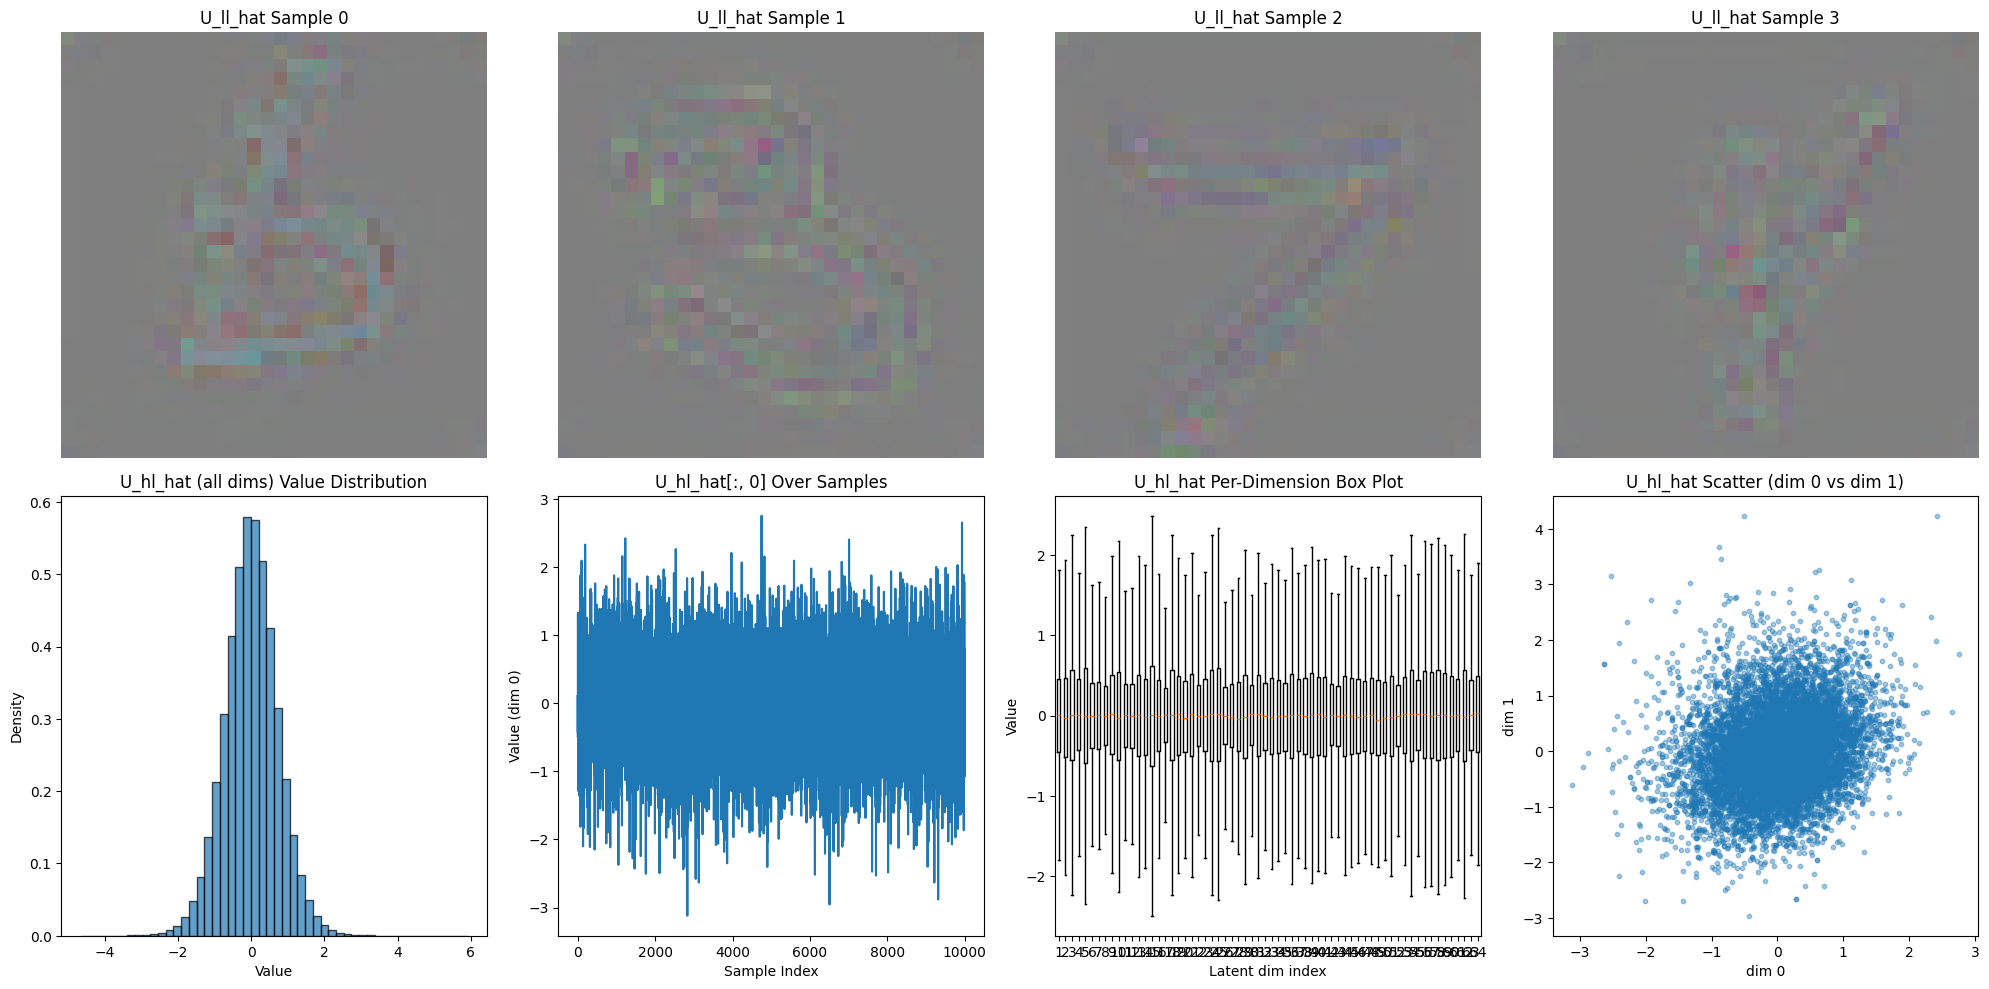


=== U_ll_hat Detailed Analysis ===
Per-channel statistics:
  Channel 0: mean=0.001709, std=0.033788
  Channel 1: mean=-0.000128, std=0.034306
  Channel 2: mean=0.002091, std=0.032564

U_ll_hat spatial statistics:
  Mean per pixel: 0.001224
  Std  per pixel: 0.004073
  Zero percentage: 0.00%

=== U_hl_hat (z-noise) Detailed Analysis ===
Value range (overall): [-4.656994, 5.912094]
Magnitude range (overall): 5.912094

Per-dimension stats (first few dims):
  dim 0: mean=0.001492, std=0.687359
  dim 1: mean=0.000142, std=0.771046
  dim 2: mean=-0.000025, std=0.860833
  dim 3: mean=-0.000820, std=0.706633
  dim 4: mean=-0.003226, std=0.898710

Outliers (1.5*IQR, overall): 9919/640000 (1.55%)
Near zero (<0.001, overall): 792/640000 (0.12%)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Analyze U_ll_hat and U_hl_hat (now z-noise with dim d_z)
print("=== U_ll_hat Analysis ===")
print(f"Shape: {U_ll_hat.shape}")
print(f"Data type: {U_ll_hat.dtype}")
print(f"Min value: {U_ll_hat.min().item():.6f}")
print(f"Max value: {U_ll_hat.max().item():.6f}")
print(f"Mean value: {U_ll_hat.mean().item():.6f}")
print(f"Std value: {U_ll_hat.std().item():.6f}")
nonzero_ll = (U_ll_hat != 0).sum().item()
print(f"Non-zero elements: {nonzero_ll}/{U_ll_hat.numel()} ({nonzero_ll/U_ll_hat.numel()*100:.2f}%)")

print("\n=== U_hl_hat (z-noise) Analysis ===")
print(f"Shape: {U_hl_hat.shape}")
print(f"Data type: {U_hl_hat.dtype}")
print(f"Latent dim d_z: {U_hl_hat.shape[1]}")
print(f"Min value (overall): {U_hl_hat.min().item():.6f}")
print(f"Max value (overall): {U_hl_hat.max().item():.6f}")
print(f"Mean value (overall): {U_hl_hat.mean().item():.6f}")
print(f"Std value (overall): {U_hl_hat.std().item():.6f}")
nonzero_hl = (U_hl_hat != 0).sum().item()
print(f"Non-zero elements: {nonzero_hl}/{U_hl_hat.numel()} ({nonzero_hl/U_hl_hat.numel()*100:.2f}%)")

# Create visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# ------------------------
# U_ll_hat visualizations
# ------------------------
for i in range(min(4, U_ll_hat.shape[0])):
    ax = axes[0, i]
    img = U_ll_hat[i].detach().cpu().permute(1, 2, 0).numpy()
    ax.imshow(np.clip((img + 1) / 2, 0, 1))
    ax.set_title(f'U_ll_hat Sample {i}')
    ax.axis('off')

# ------------------------
# U_hl_hat visualizations
# ------------------------
U_hl_np = U_hl_hat.detach().cpu().numpy()
flat = U_hl_np.flatten()

axes[1, 0].hist(flat, bins=50, alpha=0.7, edgecolor='black', density=True)
axes[1, 0].set_title('U_hl_hat (all dims) Value Distribution')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Density')

if U_hl_np.shape[1] >= 1:
    axes[1, 1].plot(U_hl_np[:, 0])
    axes[1, 1].set_title('U_hl_hat[:, 0] Over Samples')
    axes[1, 1].set_xlabel('Sample Index')
    axes[1, 1].set_ylabel('Value (dim 0)')

axes[1, 2].boxplot(U_hl_np, showfliers=False)
axes[1, 2].set_title('U_hl_hat Per-Dimension Box Plot')
axes[1, 2].set_xlabel('Latent dim index')
axes[1, 2].set_ylabel('Value')

if U_hl_np.shape[1] >= 2:
    axes[1, 3].scatter(U_hl_np[:, 0], U_hl_np[:, 1], alpha=0.4, s=10)
    axes[1, 3].set_xlabel('dim 0')
    axes[1, 3].set_ylabel('dim 1')
    axes[1, 3].set_title('U_hl_hat Scatter (dim 0 vs dim 1)')

plt.tight_layout()
plt.show()

# ------------------------
# Additional analysis for U_ll_hat
# ------------------------
print("\n=== U_ll_hat Detailed Analysis ===")
print("Per-channel statistics:")
for c in range(U_ll_hat.shape[1]):
    channel_data = U_ll_hat[:, c, :, :]
    print(f"  Channel {c}: mean={channel_data.mean().item():.6f}, std={channel_data.std().item():.6f}")

print("\nU_ll_hat spatial statistics:")
print(f"  Mean per pixel: {U_ll_hat.mean(dim=0).mean().item():.6f}")
print(f"  Std  per pixel: {U_ll_hat.mean(dim=0).std().item():.6f}")

zero_percentage = (U_ll_hat == 0).sum().item() / U_ll_hat.numel() * 100
print(f"  Zero percentage: {zero_percentage:.2f}%")

# ------------------------
# Additional analysis for U_hl_hat (z)
# ------------------------
print("\n=== U_hl_hat (z-noise) Detailed Analysis ===")
print(f"Value range (overall): [{U_hl_hat.min().item():.6f}, {U_hl_hat.max().item():.6f}]")
print(f"Magnitude range (overall): {abs(U_hl_hat).max().item():.6f}")

print("\nPer-dimension stats (first few dims):")
max_dims_to_print = min(5, U_hl_hat.shape[1])
for d in range(max_dims_to_print):
    dim_vals = U_hl_hat[:, d]
    print(f"  dim {d}: mean={dim_vals.mean().item():.6f}, std={dim_vals.std().item():.6f}")

q25, q75 = torch.quantile(U_hl_hat.flatten(), 0.25), torch.quantile(U_hl_hat.flatten(), 0.75)
iqr = q75 - q25
outlier_threshold = 1.5 * iqr
outliers = ((U_hl_hat < q25 - outlier_threshold) | (U_hl_hat > q75 + outlier_threshold)).sum().item()
print(f"\nOutliers (1.5*IQR, overall): {outliers}/{U_hl_hat.numel()} ({outliers/U_hl_hat.numel()*100:.2f}%)")

near_zero = (abs(U_hl_hat) < 1e-3).sum().item()
print(f"Near zero (<0.001, overall): {near_zero}/{U_hl_hat.numel()} ({near_zero/U_hl_hat.numel()*100:.2f}%)")


In [4]:
import torch
import numpy as np

# ============================================================
# Rebuild parent_info_ll_tuple and parent_info_hl
# from CURRENT Dll_samples / Dhl_samples
# (string-key safe, consistent with obs_key="obs")
# ============================================================

def get_obs_key(sample_dict, name=""):
    # prefer explicit "obs" if present
    if "obs" in sample_dict:
        return "obs"
    if None in sample_dict:
        return None
    # fallback
    k0 = next(iter(sample_dict.keys()))
    print(f"[Warning] No explicit obs key for {name}. Using first key: {k0}")
    return k0

# observational keys
iota_obs = get_obs_key(Dll_samples, "Dll_samples")
eta_obs  = get_obs_key(Dhl_samples, "Dhl_samples")

# ----- LL parent info tuple -----
final_images_obs, img_shapes_obs, digits_obs, colors_obs = Dll_samples[iota_obs]

parent_info_ll_tuple = (
    final_images_obs,  # unused except for shape consistency
    img_shapes_obs,    # (N,1,32,32)
    digits_obs,        # (N,)
    colors_obs,        # (N,)
)

# ----- HL parent info (first 20 dims are [Xd|Xc]) -----
parent_info_hl = Dhl_samples[eta_obs][:, :20].cpu().numpy()

print("Rebuilt parent infos:")
print(f"  iota_obs={iota_obs}, eta_obs={eta_obs}")
print(f"  parent_info_ll_tuple: images={final_images_obs.shape}, shapes={img_shapes_obs.shape}, "
      f"digits={digits_obs.shape}, colors={colors_obs.shape}")
print(f"  parent_info_hl shape: {parent_info_hl.shape}")


Rebuilt parent infos:
  iota_obs=obs, eta_obs=obs
  parent_info_ll_tuple: images=torch.Size([10000, 3, 32, 32]), shapes=torch.Size([10000, 1, 32, 32]), digits=torch.Size([10000]), colors=torch.Size([10000])
  parent_info_hl shape: (10000, 20)


In [5]:
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

print("\n" + "="*80)
print("REBUILD + VERIFY DETERMINISTIC DICTIONARIES (LL + HL) — FULL SCRIPT")
print("="*80)

# ============================================================
# 0) Sanity: intervention objects must already exist from CELL 2
# ============================================================

assert "ll_interventions" in globals(), "ll_interventions not found. Run CELL 2 first."
assert "hl_interventions" in globals(), "hl_interventions not found. Run CELL 2 first."

assert set(ll_interventions.keys()) == set(Ill_relevant), \
    f"LL intervention labels mismatch vs omega keys."
assert set(hl_interventions.keys()) == set(Ihl_relevant), \
    f"HL intervention labels mismatch vs omega values."

print("✅ Using ll_interventions / hl_interventions from CELL 2.")
print("   (No hard-coded dicts here — safer against label drift.)")


# ============================================================
# 1) Deterministic functions (FIXED versions)
# ============================================================

def det_hl_func_FIXED(hl_model, parent_info_hl, intervention):
    """
    High-level deterministic function (FIXED).

    parent_info_hl: numpy array (N,20) = [Xd(10) | Xc(10)]
    intervention: Intervention object (or None)

    Returns torch.Tensor (N, 20 + d_z):
        [Xd | Xc | z_pred]
    """
    features = parent_info_hl.copy()

    if intervention is not None and hasattr(intervention, "vv"):
        iv_dict = intervention.vv()

        # Digit_ do()
        if D_HL in iv_dict:
            new_digits = np.zeros_like(features[:, :10])
            new_digits[:, iv_dict[D_HL]] = 1
            features[:, :10] = new_digits

        # Color_ do()
        if C_HL in iv_dict:
            new_colors = np.zeros_like(features[:, 10:20])
            new_colors[:, iv_dict[C_HL]] = 1
            features[:, 10:20] = new_colors

    Xd = features[:, :10]
    Xc = features[:, 10:20]
    z_pred = hl_model.predict(Xd, Xc)  # correct signature

    if z_pred.ndim == 1:
        z_pred = z_pred.reshape(-1, 1)

    full_vector = np.concatenate([Xd, Xc, z_pred], axis=1)
    return torch.tensor(full_vector, dtype=torch.float32)


def det_ll_func_FIXED(ll_model, parent_info_ll_tuple, intervention):
    """
    Low-level deterministic function (FIXED).

    parent_info_ll_tuple:
        (final_images_obs, img_shapes_obs, digits_obs, colors_obs)

    Returns torch.Tensor (N, 3072 + 10 + 10 = 3092):
        [pixels_flat | digit_onehot | color_onehot]
    """
    _, img_shapes, digits, colors = parent_info_ll_tuple
    n_samples = digits.shape[0]

    if intervention is not None and hasattr(intervention, "vv"):
        iv_dict = intervention.vv()
        if D_LL in iv_dict:
            digits = torch.full_like(digits, iv_dict[D_LL])
        if C_LL in iv_dict:
            colors = torch.full_like(colors, iv_dict[C_LL])

    ll_model.eval()
    device = next(ll_model.parameters()).device
    img_shapes = img_shapes.to(device)
    digits_dev = digits.to(device).long()
    colors_dev = colors.to(device).long()

    with torch.no_grad():
        predicted_images = ll_model(img_shapes, digits_dev, colors_dev)  # [-1,1]

    flattened_images = predicted_images.cpu().view(n_samples, -1)  # (N,3072)
    digits_onehot = F.one_hot(digits, num_classes=10).float()
    colors_onehot = F.one_hot(colors, num_classes=10).float()

    full_vector = torch.cat([flattened_images, digits_onehot, colors_onehot], dim=1)
    return full_vector


# ============================================================
# 2) Recompute deterministic dictionaries using objects
# ============================================================

det_hl_dict = {}
for lab in tqdm(Ihl_relevant, desc="HL deterministic (FIXED)"):
    det_hl_dict[lab] = det_hl_func_FIXED(
        hl_model,
        parent_info_hl,
        hl_interventions[lab],
    )

det_ll_dict = {}
for lab in tqdm(Ill_relevant, desc="LL deterministic (FIXED)"):
    det_ll_dict[lab] = det_ll_func_FIXED(
        ll_model,
        parent_info_ll_tuple,
        ll_interventions[lab],
    )

print(f"det_ll_dict['obs'] shape: {det_ll_dict['obs'].shape}")
print(f"det_hl_dict['obs'] shape: {det_hl_dict['obs'].shape}")


# ============================================================
# 3) FULL verification block (5 checks)
# ============================================================

print("\n" + "="*80)
print("VERIFYING DETERMINISTIC DICTIONARIES")
print("="*80)

# ---- [1] key / intervention type checks ----
print("\n[1] Checking if interventions are objects or strings...")
ll_key_types = {type(k) for k in Ill_relevant}
hl_key_types = {type(k) for k in Ihl_relevant}
print("  LL key types:", ll_key_types)
print("  HL key types:", hl_key_types)

ll_any_vv = any(hasattr(ll_interventions[k], "vv") for k in Ill_relevant if ll_interventions[k] is not None)
hl_any_vv = any(hasattr(hl_interventions[k], "vv") for k in Ihl_relevant if hl_interventions[k] is not None)
print("  Any LL intervention has .vv()? ", ll_any_vv)
print("  Any HL intervention has .vv()? ", hl_any_vv)

if ll_any_vv and hl_any_vv:
    print("  ✅ Interventions are objects (or None) as expected.")
else:
    print("  ⚠️ Some interventions are not objects — deterministic do() may fail.")

# ---- helper for diffs ----
def frob_diff(A, B):
    return torch.norm(A - B, p="fro").item()

# ---- [2] LL dict differences ----
print("\n[2] Checking whether LL deterministic outputs differ across envs...")
base_key = "obs"
base_ll = det_ll_dict[base_key]

ll_diffs = []
print(f"\n[det_ll_dict] Pairwise diffs vs base key = '{base_key}'")
for k in Ill_relevant:
    diff_val = frob_diff(base_ll, det_ll_dict[k])
    ll_diffs.append(diff_val)
    if k != base_key:
        print(f"  diff('{base_key}', '{k}') = {diff_val:.6e}")

print(f"\n  det_ll_dict max diff across all envs: "
      f"min={np.min(ll_diffs):.3e}, median={np.median(ll_diffs):.3e}, max={np.max(ll_diffs):.3e}")

if np.max(ll_diffs) < 1e-6:
    print("  ❌ det_ll_dict is numerically identical across envs.")
else:
    print("  ✅ det_ll_dict differs across envs.")

# ---- [3] HL dict differences ----
print("\n[3] Checking whether HL deterministic outputs differ across envs...")
base_hl = det_hl_dict[base_key]

hl_diffs = []
print(f"\n[det_hl_dict] Pairwise diffs vs base key = '{base_key}'")
for k in Ihl_relevant:
    diff_val = frob_diff(base_hl, det_hl_dict[k])
    hl_diffs.append(diff_val)
    if k != base_key:
        print(f"  diff('{base_key}', '{k}') = {diff_val:.6e}")

print(f"\n  det_hl_dict max diff across all envs: "
      f"min={np.min(hl_diffs):.3e}, median={np.median(hl_diffs):.3e}, max={np.max(hl_diffs):.3e}")

if np.max(hl_diffs) < 1e-6:
    print("  ❌ det_hl_dict is numerically identical across envs.")
else:
    print("  ✅ det_hl_dict differs across envs.")

# ---- [4] HL predict() contract check ----
print("\n[4] Checking HL predict() contract (Xd,Xc) vs old features usage...")
features = parent_info_hl.copy()
Xd = features[:, :10]
Xc = features[:, 10:20]
z_correct = hl_model.predict(Xd, Xc)
z_wrong   = hl_model.predict(features, features)  # old buggy call

mean_err = np.mean(np.abs(z_correct - z_wrong))
max_err  = np.max(np.abs(z_correct - z_wrong))

print(f"  mean |z_correct - z_wrong| = {mean_err:.6e}")
print(f"  max  |z_correct - z_wrong| = {max_err:.6e}")

if mean_err < 1e-6 and max_err < 1e-5:
    print("  ✅ det_hl_func now matches hl_model.predict contract.")
else:
    print("  ⚠️ Old buggy signature still differs (expected). FIXED det_hl_func uses (Xd,Xc).")

# ---- [5] which envs objective uses ----
print("\n[5] Checking which env pairs would be used by empirical_objective...")
used_pairs = []
for iota, eta in omega.items():
    ok = (iota in det_ll_dict) and (eta in det_hl_dict)
    if ok:
        used_pairs.append((iota, eta))

print(f"  Used env pairs: {len(used_pairs)} / {len(omega)}")
if len(used_pairs) < len(omega):
    missing = [(i, e) for (i, e) in omega.items() if (i, e) not in used_pairs]
    print("  ⚠️ Missing pairs:", missing[:5], "..." if len(missing) > 5 else "")
else:
    print("  ✅ No env pairs missing.")

print("\n" + "="*80)
print("DONE.")
print("="*80)



REBUILD + VERIFY DETERMINISTIC DICTIONARIES (LL + HL) — FULL SCRIPT
✅ Using ll_interventions / hl_interventions from CELL 2.
   (No hard-coded dicts here — safer against label drift.)


LL deterministic (FIXED): 100%|██████████| 10/10 [04:42<00:00, 28.29s/it]


det_ll_dict['obs'] shape: torch.Size([10000, 3092])
det_hl_dict['obs'] shape: torch.Size([10000, 84])

VERIFYING DETERMINISTIC DICTIONARIES

[1] Checking if interventions are objects or strings...
  LL key types: {<class 'str'>}
  HL key types: {<class 'str'>}
  Any LL intervention has .vv()?  True
  Any HL intervention has .vv()?  True
  ✅ Interventions are objects (or None) as expected.

[2] Checking whether LL deterministic outputs differ across envs...

[det_ll_dict] Pairwise diffs vs base key = 'obs'
  diff('obs', 'D=6') = 1.378526e+02
  diff('obs', 'D=8') = 1.391294e+02
  diff('obs', 'D=4') = 1.385034e+02
  diff('obs', 'C=7') = 1.084820e+03
  diff('obs', 'C=0') = 1.143866e+03
  diff('obs', 'C=4') = 1.066558e+03
  diff('obs', 'D=6,C=7') = 1.088960e+03
  diff('obs', 'D=8,C=0') = 1.146764e+03
  diff('obs', 'D=4,C=4') = 1.077071e+03

  det_ll_dict max diff across all envs: min=0.000e+00, median=1.072e+03, max=1.147e+03
  ✅ det_ll_dict differs across envs.

[3] Checking whether HL det

In [6]:
# ================== SUBSAMPLE DATA FOR FASTER TRAINING ==================
import torch
import numpy as np

# How many samples you want to keep 
N_SUB = 2000  # e.g. 500 or 1000

print("\n" + "="*20 + f" Subsampling to N_SUB = {N_SUB} " + "="*20)

# ---- 0. Find observational key for LL & HL (string-safe) ----
iota_obs = get_obs_key(Dll_samples, name="Dll_samples")
eta_obs  = get_obs_key(Dhl_samples, name="Dhl_samples")
print(f"Using observational keys: iota_obs = {iota_obs}, eta_obs = {eta_obs}")

# ---- 1. Determine total N from observational environment ----
N_total = Dll_samples[iota_obs][0].shape[0]  # final_images shape[0]
print(f"Total available samples per intervention: N_total = {N_total}")

if N_SUB >= N_total:
    print("N_SUB >= N_total: no subsampling will be applied.")
    sub_idx = torch.arange(N_total, dtype=torch.long)
else:
    rng = np.random.default_rng(23)  # fixed for reproducibility
    perm = rng.permutation(N_total)
    sub_idx = torch.tensor(perm[:N_SUB], dtype=torch.long)
    print(f"Using a random subset of size {N_SUB} from {N_total} samples.")

# ---- 2. Subsample Dll_samples for ALL interventions ----
Dll_samples_full = Dll_samples  # backup
Dll_samples_sub = {}

for iota, tpl in Dll_samples.items():
    final_images, img_shapes, digits, colors = tpl
    Dll_samples_sub[iota] = (
        final_images[sub_idx],
        img_shapes[sub_idx],
        digits[sub_idx],
        colors[sub_idx],
    )

print(f"Dll_samples: reduced to N_SUB={Dll_samples_sub[iota_obs][0].shape[0]} for all interventions.")

# ---- 3. Subsample Dhl_samples for ALL interventions ----
Dhl_samples_full = Dhl_samples  # backup
Dhl_samples_sub = {}

for eta, tensor in Dhl_samples.items():
    Dhl_samples_sub[eta] = tensor[sub_idx]

print(f"Dhl_samples: reduced to N_SUB={Dhl_samples_sub[eta_obs].shape[0]} for all interventions.")

# ---- 4. Subsample noise estimates U_ll_hat and U_hl_hat ----
U_ll_hat_full = U_ll_hat  # backup
U_hl_hat_full = U_hl_hat  # backup

U_ll_hat_sub = U_ll_hat[sub_idx]
U_hl_hat_sub = U_hl_hat[sub_idx]

print(f"U_ll_hat: {U_ll_hat.shape} → {U_ll_hat_sub.shape}")
print(f"U_hl_hat: {U_hl_hat.shape} → {U_hl_hat_sub.shape}")

# ---- 5. Subsample deterministic ANM outputs det_ll_dict & det_hl_dict ----
det_ll_dict_full = det_ll_dict  # backup
det_hl_dict_full = det_hl_dict  # backup

det_ll_dict_sub = {k: v[sub_idx] for k, v in det_ll_dict.items()}
det_hl_dict_sub = {k: v[sub_idx] for k, v in det_hl_dict.items()}

some_iota = next(iter(det_ll_dict_sub.keys()))
some_eta = next(iter(det_hl_dict_sub.keys()))
print(f"det_ll_dict[{some_iota!r}]: {det_ll_dict[some_iota].shape} → {det_ll_dict_sub[some_iota].shape}")
print(f"det_hl_dict[{some_eta!r}]: {det_hl_dict[some_eta].shape} → {det_hl_dict_sub[some_eta].shape}")

# ---- 6. Overwrite globals so the rest of the notebook uses the subset ----
Dll_samples = Dll_samples_sub
Dhl_samples = Dhl_samples_sub
U_ll_hat = U_ll_hat_sub
U_hl_hat = U_hl_hat_sub
det_ll_dict = det_ll_dict_sub
det_hl_dict = det_hl_dict_sub

print("\n✅ Subsampling complete. All subsequent training will use the reduced dataset.")

# ---- 7. Create OPTIMIZATION-only deterministic dicts (pixels -> z) ----
# LL opt: pixels only (first 3072 dims)
det_ll_dict_opt = {k: v[:, :3072].contiguous() for k, v in det_ll_dict.items()}

# HL opt: z only (drop 20-d labels)
det_hl_dict_opt = {k: v[:, 20:].contiguous() for k, v in det_hl_dict.items()}

print("\nCreated optimization-only deterministic dictionaries:")
print(f"  det_ll_dict_opt['obs'] shape: {det_ll_dict_opt['obs'].shape}   # pixels only")
print(f"  det_hl_dict_opt['obs'] shape: {det_hl_dict_opt['obs'].shape}   # z only")



==================== Subsampling to N_SUB = 2000 ====================
Using observational keys: iota_obs = obs, eta_obs = obs
Total available samples per intervention: N_total = 10000
Using a random subset of size 2000 from 10000 samples.
Dll_samples: reduced to N_SUB=2000 for all interventions.
Dhl_samples: reduced to N_SUB=2000 for all interventions.
U_ll_hat: torch.Size([10000, 3, 32, 32]) → torch.Size([2000, 3, 32, 32])
U_hl_hat: torch.Size([10000, 64]) → torch.Size([2000, 64])
det_ll_dict['obs']: torch.Size([10000, 3092]) → torch.Size([2000, 3092])
det_hl_dict['obs']: torch.Size([10000, 84]) → torch.Size([2000, 84])

✅ Subsampling complete. All subsequent training will use the reduced dataset.

Created optimization-only deterministic dictionaries:
  det_ll_dict_opt['obs'] shape: torch.Size([2000, 3072])   # pixels only
  det_hl_dict_opt['obs'] shape: torch.Size([2000, 64])   # z only


In [7]:
from sklearn.model_selection import KFold
import numpy as np

print("\n" + "="*20 + " Setting up cross-validation " + "="*20)

print(f"Observational LL key: {iota_obs}")

K_FOLDS = 5
SEED = 23

def setup_cv_folds(data_tuple, n_splits=K_FOLDS, seed=SEED):
    """Create k-fold splits using the first tensor's length."""
    print(f"Setting up {n_splits}-fold cross-validation...")
    num_samples = data_tuple[0].shape[0]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for train_idx, test_idx in kf.split(np.arange(num_samples)):
        folds.append({'train': train_idx, 'test': test_idx})
    print(f"✓ CV folds created. Each fold will have ~{len(folds[0]['train'])} training samples.")
    return folds

# Create CV folds using the observational slice of *subsampled* Dll_samples
cv_folds = setup_cv_folds(Dll_samples[iota_obs])
print(f"Created {len(cv_folds)} CV folds (using observational key = {iota_obs})")



==================== Setting up cross-validation ====================
Observational LL key: obs
Setting up 5-fold cross-validation...
✓ CV folds created. Each fold will have ~1600 training samples.
Created 5 CV folds (using observational key = obs)


In [8]:
def fix_noise_data(U_ll_hat, U_hl_hat):
    """
    Prepare noise data for optimization:
      - LL noise: flatten from (N, 3, 32, 32) → (N, 3072)
      - HL noise: leave as is (already (N, d_z))

    Also returns LL-OPT noise (pixels only), which is what optimization uses
    when we drop labels and set delta=0.
    """
    N = U_ll_hat.shape[0]

    # --- Low-level noise ---
    if U_ll_hat.ndim == 4 and U_ll_hat.shape[1:] == (3, 32, 32):
        U_ll_hat_fixed = U_ll_hat.reshape(N, -1)  # (N, 3072)
        print(f"Flattened U_ll_hat from {tuple(U_ll_hat.shape)} → {tuple(U_ll_hat_fixed.shape)}")
    else:
        raise ValueError(f"Unexpected U_ll_hat shape: {U_ll_hat.shape}, expected (N,3,32,32)")

    # --- High-level noise ---
    if U_hl_hat.ndim == 2:
        U_hl_hat_fixed = U_hl_hat  # (N, d_z)
        print(f"U_hl_hat retained as {tuple(U_hl_hat_fixed.shape)} (latent z noise)")
    else:
        raise ValueError(f"Unexpected U_hl_hat shape: {U_hl_hat.shape}, expected (N, d_z) 2D tensor")

    # --- Optimization-only view (pixels ambiguity only) ---
    U_ll_hat_opt = U_ll_hat_fixed  # already pixels-only
    U_hl_hat_opt = U_hl_hat_fixed  # will be ignored if delta=0

    return U_ll_hat_fixed, U_hl_hat_fixed, U_ll_hat_opt, U_hl_hat_opt


# Run normalization
U_ll_hat_fixed, U_hl_hat_fixed, U_ll_hat_opt, U_hl_hat_opt = fix_noise_data(U_ll_hat, U_hl_hat)

print(f"\nFinal corrected shapes:")
print(f"  U_ll_hat_fixed: {tuple(U_ll_hat_fixed.shape)}")
print(f"  U_hl_hat_fixed: {tuple(U_hl_hat_fixed.shape)}")
print(f"  U_ll_hat_opt  : {tuple(U_ll_hat_opt.shape)}   # used in optimization")
print(f"  U_hl_hat_opt  : {tuple(U_hl_hat_opt.shape)}   # ignored if delta=0")


Flattened U_ll_hat from (2000, 3, 32, 32) → (2000, 3072)
U_hl_hat retained as (2000, 64) (latent z noise)

Final corrected shapes:
  U_ll_hat_fixed: (2000, 3072)
  U_hl_hat_fixed: (2000, 64)
  U_ll_hat_opt  : (2000, 3072)   # used in optimization
  U_hl_hat_opt  : (2000, 64)   # ignored if delta=0


In [9]:
# --- Projection and Radius (unchanged) ---

def project_onto_frobenius_ball(tensor, radius_limit):
    """
    Project tensor onto a Frobenius norm ball:

        ||X||_F <= radius_limit
    """
    with torch.no_grad():
        current_norm = torch.norm(tensor, p='fro')
        if current_norm > radius_limit:
            tensor.mul_(radius_limit / (current_norm + 1e-12))
    return tensor


def compute_empirical_radius(N, eta=0.05, c1=1000.0, c2=1.0, alpha=2.0, m=1):
    """
    Compute an empirical Wasserstein-type radius (heuristic formula).
    """
    if N <= 1:
        return 0.0
    term1 = c1 * (np.log(N) / N) ** (1.0 / alpha)
    term2 = c2 * np.sqrt(m * np.log(1.0 / eta) / N)
    return term1 + term2


# ============================================================
# Abs-LiNGAM-style Core Functions (OPT VIEW)
# Now fit ONLY pixels -> z, ignoring labels.
#
# px_samples : (N, 3072)
# py_samples : (N, d_z)
# T_raw      : (3072, d_z)
# ============================================================

def perfect_abstraction_opt(px_samples, py_samples, tau_threshold=1e-2):
    """
    Fit dense linear abstraction in OPT view:

        px_samples @ T_raw ≈ py_samples

    where:
        px_samples : (N, 3072) pixels only
        py_samples : (N, d_z)  z only

    Returns:
        T_raw : (3072, d_z)
    """
    T_raw = np.linalg.pinv(px_samples) @ py_samples  # (3072, d_z)

    # Hard threshold small coefficients
    T_raw_mask = np.abs(T_raw) > tau_threshold
    T_raw = T_raw * T_raw_mask
    return T_raw


def noisy_abstraction_opt(px_samples, py_samples, tau_threshold=1e-1, refit_coeff=False):
    """
    Sparse/noisy abstraction in OPT view (pixels->z).

    Steps:
      1. Dense pseudo-inverse fit T_raw_hat
      2. For each LL pixel dim, keep strongest z dim
      3. Zero weak entries
      4. Optional refit per z-dim
    """
    try:
        T_raw_hat = np.linalg.pinv(px_samples) @ py_samples  # (3072, d_z)

        # strongest z dim per pixel
        tau_mask_indices = np.argmax(np.abs(T_raw_hat), axis=1)  # (3072,)

        d_z = py_samples.shape[1]
        tau_mask_hat = np.eye(d_z)[tau_mask_indices]            # (3072, d_z)

        tau_mask_hat *= (np.abs(T_raw_hat) > tau_threshold).astype(np.int32)
        T_masked = tau_mask_hat * T_raw_hat

        if not refit_coeff:
            return T_masked

        print("Warning: refit_coeff=True in noisy_abstraction_opt not fully verified.")
        T_refit = T_masked.copy()

        for j in range(d_z):
            block = np.where(tau_mask_hat[:, j] == 1)[0]
            if len(block) == 0:
                continue
            T_block = np.linalg.pinv(px_samples[:, block]) @ py_samples[:, j]
            T_refit[block, j] = T_block

        return T_refit

    except Exception as e:
        print(f"Error in noisy_abstraction_opt: {e}")
        return np.zeros((px_samples.shape[1], py_samples.shape[1]), dtype=px_samples.dtype)


In [10]:
def empirical_objective_cmnist_opt(
    T_opt,
    U_ll, Theta_ll,
    det_ll_dict, det_hl_dict,
    omega,
):
    """
    OPT-view objective for DiRoCA/GradCA.

    We optimize ONLY the meaningful abstraction:

        pixels (3072)  --->  z (d_z)

    Inputs:
        det_ll_dict[iota] : (N, 3092)  [pixels | LL labels]
        det_hl_dict[eta]  : (N, 84)    [HL labels | z]

    Noise / ambiguity:
        U_ll, Theta_ll affect ONLY pixels.
        delta = 0 => NO HL ambiguity, so U_hl/Phi dropped.

    T_opt:
        shape (d_z, 3072)
    """
    total_loss = 0.0
    device = T_opt.device

    # move once
    U_ll = U_ll.to(device)           # (N, 3072)
    Theta_ll = Theta_ll.to(device)   # (N, 3072)

    num_interventions = 0

    for iota, eta in omega.items():
        if iota not in det_ll_dict or eta not in det_hl_dict:
            continue

        det_ll_full = det_ll_dict[iota].to(device)   # (N, 3092)
        det_hl_full = det_hl_dict[eta].to(device)    # (N, 84)

        N = U_ll.shape[0]
        if det_ll_full.shape[0] != N or det_hl_full.shape[0] != N:
            continue

        # ----- LL OPT view: pixels only -----
        ll_pixels = det_ll_full[:, :3072]            # (N, 3072)
        ll_pixels_noisy = ll_pixels + U_ll + Theta_ll

        # ----- HL OPT view: z only -----
        hl_z = det_hl_full[:, 20:]                  # (N, d_z)

        # ----- Map + loss in OPT view -----
        mapped_z = (T_opt @ ll_pixels_noisy.T).T    # (N, d_z)

        diff = mapped_z - hl_z
        loss = torch.norm(diff, p='fro')**2 / N
        total_loss += loss
        num_interventions += 1

    return total_loss / max(1, num_interventions)


def barycentric_objective_cmnist_opt(T_opt, U_ll, det_ll_dict, det_hl_dict, omega):
    """
    BaryCA objective in OPT view.

    Average deterministic parts across interventions, then map:

        avg pixels (3072) ---> avg z (d_z)

    Noise: only LL pixels noise is used (delta=0).
    """
    device = T_opt.device
    U_ll = U_ll.to(device)  # (N, 3072)

    ll_tensors = []
    hl_tensors = []
    num_interventions = 0

    for iota, eta in omega.items():
        if iota in det_ll_dict and eta in det_hl_dict:
            ll_tensors.append(det_ll_dict[iota].to(device))  # (N, 3092)
            hl_tensors.append(det_hl_dict[eta].to(device))   # (N, 84)
            num_interventions += 1

    if num_interventions == 0:
        return torch.tensor(0.0, device=device)

    avg_det_ll = torch.mean(torch.stack(ll_tensors), dim=0)  # (N, 3092)
    avg_det_hl = torch.mean(torch.stack(hl_tensors), dim=0)  # (N, 84)
    N = avg_det_ll.shape[0]

    # OPT slices
    avg_ll_pixels = avg_det_ll[:, :3072]                     # (N, 3072)
    avg_hl_z      = avg_det_hl[:, 20:]                       # (N, d_z)

    avg_ll_pixels_noisy = avg_ll_pixels + U_ll

    mapped_avg_z = (T_opt @ avg_ll_pixels_noisy.T).T         # (N, d_z)

    diff = mapped_avg_z - avg_hl_z
    loss = torch.norm(diff, p='fro')**2 / max(1, N)

    return loss


In [11]:
# --- Empirical Training Monitor (OPT view) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

class EmpiricalMonitor:
    """
    Tracks metrics during empirical optimization (DiRoCA / GradCA / BaryCA)
    in the OPT view:

      - T_objective: reconstruction loss between mapped pixels and HL z
      - adv_objective: same objective at adversary step (only if DiRoCA)
      - theta_norm: ||Theta_ll||_F  (LL pixel perturbations, N × 3072)
      - phi_norm:   optional, only if you later turn delta>0 back on
    """
    def __init__(self):
        self.iteration_history = []

    def track_iteration(
        self,
        iteration,
        T_objective,
        T_matrix,
        T_matrix_prev,
        adv_objective=None,
        Theta=None,
        Phi=None,          # optional for future use
        epsilon=None,
        delta=None,        # optional for future use
    ):
        metrics = {
            "iteration": iteration,
            "T_objective": (
                T_objective.item()
                if isinstance(T_objective, torch.Tensor)
                else float(T_objective)
            ),
            "delta_T_norm": (
                torch.norm(T_matrix - T_matrix_prev, p="fro").item()
                if T_matrix_prev is not None
                else 0.0
            ),
        }

        # Adversary objective (only present for DiRoCA / ERICA)
        if adv_objective is not None and not (
            isinstance(adv_objective, float) and np.isnan(adv_objective)
        ):
            metrics["adv_objective"] = (
                adv_objective.item()
                if isinstance(adv_objective, torch.Tensor)
                else float(adv_objective)
            )

        # LL perturbation
        if Theta is not None:
            metrics["theta_norm"] = torch.norm(Theta, p="fro").item()
            if epsilon is not None and Theta.shape[0] > 0:
                metrics["epsilon_boundary"] = epsilon * np.sqrt(Theta.shape[0])
            else:
                metrics["epsilon_boundary"] = np.nan

        # HL perturbation (OPTIONAL; delta=0 => usually None)
        if Phi is not None:
            metrics["phi_norm"] = torch.norm(Phi, p="fro").item()
            if delta is not None and Phi.shape[0] > 0:
                metrics["delta_boundary"] = delta * np.sqrt(Phi.shape[0])
            else:
                metrics["delta_boundary"] = np.nan

        self.iteration_history.append(metrics)

    def plot_summary(self, title_prefix: str = ""):
        """Plot convergence diagnostics from the stored iteration history."""
        if not self.iteration_history:
            print("No history to plot.")
            return

        df = pd.DataFrame(self.iteration_history).set_index("iteration")

        has_adv   = "adv_objective" in df.columns and not df["adv_objective"].isnull().all()
        has_theta = "theta_norm" in df.columns and not df["theta_norm"].isnull().all()
        has_phi   = "phi_norm" in df.columns and not df["phi_norm"].isnull().all()

        # Panels: objective, (optional adv), delta_T, (optional perturb norms)
        num_plots = 2 + int(has_adv) + int(has_theta or has_phi)

        fig, axes = plt.subplots(num_plots, 1, figsize=(12, 4 * num_plots), sharex=True)
        if num_plots == 1:
            axes = [axes]

        fig.suptitle(
            f"{title_prefix} Optimization Convergence Summary (OPT view)",
            fontsize=16, y=1.02
        )

        plot_idx = 0

        # 1) T objective (min)
        axes[plot_idx].plot(df.index, df["T_objective"], marker=".", linestyle="-",
                            label="T Objective (minimize)")
        axes[plot_idx].set_ylabel("Objective")
        axes[plot_idx].set_title("Objective vs. Iteration")
        axes[plot_idx].grid(True, alpha=0.5)

        if has_adv:
            axes[plot_idx].plot(df.index, df["adv_objective"], marker=".", linestyle="-",
                                label="Adv Objective (maximize)")
            axes[plot_idx].legend()
            plot_idx += 1

            # 2) Separate adv panel
            axes[plot_idx].plot(df.index, df["adv_objective"], marker=".", linestyle="-")
            axes[plot_idx].set_ylabel("Objective")
            axes[plot_idx].set_title("Adversary Objective vs. Iteration")
            axes[plot_idx].grid(True, alpha=0.5)
        else:
            axes[plot_idx].legend()

        # next panel: change in T
        plot_idx += 1
        axes[plot_idx].plot(df.index, df["delta_T_norm"], marker=".", linestyle="-")
        axes[plot_idx].set_ylabel("||ΔT||_F")
        axes[plot_idx].set_title("Change in T (||T_t - T_{t-1}||_F)")
        axes[plot_idx].set_yscale("log")
        axes[plot_idx].grid(True, alpha=0.5)

        # final panel: perturb norms (only if present)
        if has_theta or has_phi:
            plot_idx += 1
            if has_theta:
                axes[plot_idx].plot(df.index, df["theta_norm"], marker=".", linestyle="-",
                                    label="||Theta||_F (LL)")
                if "epsilon_boundary" in df.columns and not df["epsilon_boundary"].isnull().all():
                    eps_val = df["epsilon_boundary"].dropna().iloc[0]
                    axes[plot_idx].axhline(eps_val, linestyle="--", alpha=0.7,
                                           label=f"Epsilon boundary ({eps_val:.3f})")

            if has_phi:
                axes[plot_idx].plot(df.index, df["phi_norm"], marker=".", linestyle="-",
                                    label="||Phi||_F (HL)")
                if "delta_boundary" in df.columns and not df["delta_boundary"].isnull().all():
                    del_val = df["delta_boundary"].dropna().iloc[0]
                    axes[plot_idx].axhline(del_val, linestyle="--", alpha=0.7,
                                           label=f"Delta boundary ({del_val:.3f})")

            axes[plot_idx].set_ylabel("Frobenius norm")
            axes[plot_idx].set_title("Perturbation Norms vs. Iteration")
            axes[plot_idx].legend()
            axes[plot_idx].grid(True, alpha=0.5)

        axes[-1].set_xlabel("Iteration")
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()


In [12]:
import torch
import numpy as np
from tqdm import tqdm
import torch.optim as optim
import torch.nn.init as init  # Xavier init

# ============================================================
# OPT-VIEW empirical objective (pixels -> z only)
# ============================================================
def empirical_objective_cmnist_opt(
    T_opt,
    U_ll, U_hl,
    Theta_ll,
    det_ll_dict, det_hl_dict,
    omega,
):
    """
    OPT-view objective:
      - LL side used in optimization: pixels only
      - HL side used in optimization: latent z only
      - labels are ignored here (we'll attach them 1-1 AFTER optimization)

    Shapes:
      det_ll_dict[iota]: (N, 3092) = [pixels(3072), labels(20)]
      det_hl_dict[eta] : (N, 84)   = [labels(20), z(d_z)]
      U_ll, Theta_ll   : (N, 3072)
      U_hl             : (N, d_z)

      T_opt: (d_z, 3072)
    """
    total_loss = 0.0
    device = T_opt.device

    U_ll = U_ll.to(device)
    U_hl = U_hl.to(device)
    Theta_ll = Theta_ll.to(device)

    num_envs = 0
    N = U_ll.shape[0]

    for iota, eta in omega.items():
        if iota not in det_ll_dict or eta not in det_hl_dict:
            continue

        det_ll_full = det_ll_dict[iota].to(device)  # (N, 3092)
        det_hl_full = det_hl_dict[eta].to(device)   # (N, 84)

        if det_ll_full.shape[0] != N or det_hl_full.shape[0] != N:
            continue

        # LL pixels only
        ll_pixels = det_ll_full[:, :U_ll.shape[1]]  # (N,3072)
        ll_pixels_noisy = ll_pixels + U_ll + Theta_ll

        # HL z only
        z_part = det_hl_full[:, 20:]                # (N,d_z)
        z_noisy = z_part + U_hl                     # Phi is ignored (delta=0)

        mapped_z = (T_opt @ ll_pixels_noisy.T).T    # (N,d_z)
        diff = mapped_z - z_noisy
        loss = torch.norm(diff, p="fro")**2 / N

        total_loss += loss
        num_envs += 1

    return total_loss / max(1, num_envs)


# def barycentric_objective_cmnist_opt(T_opt, U_ll, U_hl, det_ll_dict, det_hl_dict, omega):
#     """
#     OPT-view BaryCA objective:
#       Average deterministic parts across envs,
#       then compare pixels->z only.
#     """
#     device = T_opt.device
#     U_ll = U_ll.to(device)
#     U_hl = U_hl.to(device)
#     N = U_ll.shape[0]

#     ll_pixels_list = []
#     hl_z_list = []

#     for iota, eta in omega.items():
#         if iota in det_ll_dict and eta in det_hl_dict:
#             ll_pixels_list.append(det_ll_dict[iota].to(device)[:, :U_ll.shape[1]])
#             hl_z_list.append(det_hl_dict[eta].to(device)[:, 20:])

#     if len(ll_pixels_list) == 0:
#         return torch.tensor(0.0, device=device)

#     avg_ll_pixels = torch.mean(torch.stack(ll_pixels_list), dim=0)  # (N,3072)
#     avg_hl_z      = torch.mean(torch.stack(hl_z_list), dim=0)       # (N,d_z)

#     mapped_avg_z = (T_opt @ (avg_ll_pixels + U_ll).T).T             # (N,d_z)
#     diff = mapped_avg_z - (avg_hl_z + U_hl)
#     loss = torch.norm(diff, p="fro")**2 / N
#     return loss

# ================== DIM-SAFE BaryCA objective (OPT view) ==================
def barycentric_objective_cmnist_opt(
    T,
    U_ll, U_hl,
    det_ll_dict_opt, det_hl_dict_opt,
    omega,
):
    """
    OPT-view BaryCA:
      det_ll_dict_opt[iota]: (N, l_opt) e.g. pixels only
      det_hl_dict_opt[eta] : (N, h_opt) e.g. z only
      T: (h_opt, l_opt)
    """
    device = T.device

    # Infer dimensions from data (not globals)
    some_iota = next(iter(det_ll_dict_opt.keys()))
    some_eta  = next(iter(det_hl_dict_opt.keys()))
    l_opt = det_ll_dict_opt[some_iota].shape[1]
    h_opt = det_hl_dict_opt[some_eta].shape[1]

    # Move noise to device and align dims
    U_ll = U_ll.to(device)
    U_hl = U_hl.to(device)

    if U_ll.shape[1] != l_opt:
        raise ValueError(f"U_ll dim {U_ll.shape[1]} != l_opt {l_opt}")
    if U_hl.shape[1] != h_opt:
        # If delta=0, safest is to just ignore U_hl and zero it
        U_hl = torch.zeros(U_ll.shape[0], h_opt, device=device)

    # Collect deterministic tensors
    ll_list, hl_list = [], []
    for iota, eta in omega.items():
        if iota in det_ll_dict_opt and eta in det_hl_dict_opt:
            ll_list.append(det_ll_dict_opt[iota].to(device))  # (N, l_opt)
            hl_list.append(det_hl_dict_opt[eta].to(device))   # (N, h_opt)

    if len(ll_list) == 0:
        return torch.tensor(0.0, device=device)

    avg_det_ll = torch.mean(torch.stack(ll_list), dim=0)  # (N, l_opt)
    avg_det_hl = torch.mean(torch.stack(hl_list), dim=0)  # (N, h_opt)
    N = avg_det_ll.shape[0]

    avg_noisy_ll = avg_det_ll + U_ll
    avg_noisy_hl = avg_det_hl + U_hl

    mapped_avg_ll = (T @ avg_noisy_ll.T).T  # (N, h_opt)
    diff = mapped_avg_ll - avg_noisy_hl
    loss = torch.norm(diff, p="fro")**2 / max(1, N)

    return loss


# ============================================================
# Core DiRoCA / GradCA Optimizer (OPT view, delta=0)
# ============================================================
def run_empirical_erica_optimization_fixed(
    U_L, U_H,
    det_ll_dict, det_hl_dict, omega,
    epsilon, delta,                  # delta is ignored (kept for API)
    eta_min, eta_max,
    num_steps_min, num_steps_max,    # max steps ignored if robust_L=False
    max_iter, tol, seed,
    robust_L, robust_H,              # robust_H ignored if delta=0
    initialization, experiment, gain, optimizers,
    monitor=None,
    clip_T=10.0,
    clip_Theta=10.0,
):
    """
    OPT-view min-max loop.

    - If robust_L=True: ERICA style min over T_opt, max over Theta_ll.
    - If robust_L=False: GradCA/ENRICO style min over T_opt only.
    - robust_H / Phi are ignored because delta=0.

    Shapes:
      U_L: (N,3072) pixels noise
      U_H: (N,d_z)  latent z noise
      T_opt: (d_z,3072)
      Theta_ll: (N,3072)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    method = "erica" if robust_L else "enrico"

    # --- Data Prep ---
    U_L = torch.as_tensor(U_L, dtype=torch.float32).to(device)
    U_H = torch.as_tensor(U_H, dtype=torch.float32).to(device)
    if U_L.ndim > 2: U_L = U_L.view(U_L.shape[0], -1)
    if U_H.ndim > 2: U_H = U_H.view(U_H.shape[0], -1)

    N, l = U_L.shape                  # l=3072
    d_z  = U_H.shape[1]               # inferred latent dim

    # Move deterministic dicts to device once
    det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict.items()}
    det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict.items()}

    # --- Initialize T_opt: (d_z, 3072) ---
    T_opt = torch.randn(d_z, l, requires_grad=True, device=device)
    if gain > 0:
        init.xavier_normal_(T_opt, gain=gain)

    # --- Initialize Theta_ll only ---
    requires_grad_adv = (method == "erica")
    if initialization == "zeros":
        Theta = torch.zeros(N, l, requires_grad=requires_grad_adv, device=device)
    elif initialization == "random":
        Theta = torch.randn(N, l, requires_grad=requires_grad_adv, device=device)
    else:
        raise ValueError(f"Unknown initialization: {initialization}")

    # Keep Phi as a zero placeholder for backward compatibility
    Phi = torch.zeros(N, d_z, requires_grad=False, device=device)

    # --- Optimizers ---
    if optimizers == "adam":
        optimizer_T = optim.Adam([T_opt], lr=eta_min)
        optimizer_max = optim.Adam([Theta], lr=eta_max) if robust_L else None
    elif optimizers == "adam_betas":
        optimizer_T = optim.Adam([T_opt], lr=eta_min, betas=(0.9, 0.999), eps=1e-8, amsgrad=True)
        optimizer_max = (
            optim.Adam([Theta], lr=eta_max, betas=(0.9, 0.999), eps=1e-8, amsgrad=True)
            if robust_L else None
        )
    else:
        raise ValueError(f"Unknown optimizer: {optimizers}")

    prev_T_objective = float("inf")
    if monitor is None:
        monitor = EmpiricalMonitor()

    # --- Optimization Loop ---
    for iteration in tqdm(range(max_iter), desc=f"{method.upper()} Optimization (OPT view)"):
        T_prev = T_opt.detach().clone()

        final_T_objective_in_iter = torch.tensor(np.nan, device=device)
        final_adv_objective_in_iter = torch.tensor(np.nan, device=device)

        # -------------------------
        # Step 1: Minimize over T_opt
        # -------------------------
        for _ in range(num_steps_min):
            optimizer_T.zero_grad()

            T_objective = empirical_objective_cmnist_opt(
                T_opt, U_L, U_H,
                Theta.detach(),              # detach adversary during T-update
                det_ll_dict_dev, det_hl_dict_dev,
                omega=omega,
            )

            if torch.isnan(T_objective):
                print(f"\nNaN in T objective at iter {iteration + 1}. Stopping.")
                break

            T_objective.backward()

            # ---- gradient clipping on T_opt ----
            torch.nn.utils.clip_grad_norm_([T_opt], max_norm=clip_T)

            optimizer_T.step()
            final_T_objective_in_iter = T_objective

        # -------------------------
        # Step 2: Maximize over Theta (ERICA only)
        # -------------------------
        if robust_L:
            for _ in range(num_steps_max):
                optimizer_max.zero_grad()

                max_objective = -empirical_objective_cmnist_opt(
                    T_opt.detach(), U_L, U_H,
                    Theta,
                    det_ll_dict_dev, det_hl_dict_dev,
                    omega=omega,
                )

                if torch.isnan(max_objective):
                    print(f"\nNaN in Max objective at iter {iteration + 1}. Keeping previous Theta.")
                    optimizer_max.zero_grad()
                    break

                max_objective.backward()

                # ---- gradient clipping on Theta ----
                torch.nn.utils.clip_grad_norm_([Theta], max_norm=clip_Theta)

                optimizer_max.step()

                # Project Theta onto Frobenius ball
                with torch.no_grad():
                    max_norm_theta = epsilon * np.sqrt(N) if epsilon > 0 else 0.0
                    if max_norm_theta > 0:
                        Theta.data = project_onto_frobenius_ball(Theta, max_norm_theta)

            with torch.no_grad():
                final_adv_objective_in_iter = empirical_objective_cmnist_opt(
                    T_opt, U_L, U_H,
                    Theta,
                    det_ll_dict_dev, det_hl_dict_dev,
                    omega=omega,
                )
        else:
            final_adv_objective_in_iter = final_T_objective_in_iter
            Theta.zero_()

        # --- Track metrics ---
        t_obj_item = final_T_objective_in_iter.item() if torch.isfinite(final_T_objective_in_iter) else np.nan
        adv_obj_item = final_adv_objective_in_iter.item() if torch.isfinite(final_adv_objective_in_iter) else np.nan

        monitor.track_iteration(
            iteration=iteration + 1,
            T_objective=t_obj_item,
            T_matrix=T_opt,
            T_matrix_prev=T_prev,
            adv_objective=adv_obj_item if robust_L else None,
            Theta=Theta if robust_L else None,
            Phi=None,
            epsilon=epsilon if robust_L else None,
            delta=None,
        )

        # --- Convergence check (unchanged) ---
        if not np.isnan(t_obj_item):
            if abs(prev_T_objective - t_obj_item) < tol:
                print(f"\nConverged at iteration {iteration + 1} (delta_obj < {tol})")
                break
            prev_T_objective = t_obj_item
        elif iteration > 0:
            print(f"\nStopping early due to NaN objective at iteration {iteration + 1}")
            break

    # --- Final Steps ---
    T_final = T_opt.detach().cpu().numpy()
    monitor.plot_summary(title_prefix=f"{method.upper()} Fold (Seed {seed})")

    Theta_final_np = Theta.detach().cpu().numpy()
    Phi_final_np   = Phi.detach().cpu().numpy()  # all zeros

    paramsL = {
        "pert_U": Theta_final_np,
        "radius_worst": epsilon if robust_L else 0,
        "pert_hat": U_L.cpu().numpy(),
        "radius": epsilon if robust_L else 0,
    }
    paramsH = {
        "pert_U": Phi_final_np,
        "radius_worst": 0,
        "pert_hat": U_H.cpu().numpy(),
        "radius": 0,
    }
    opt_params = {"L": paramsL, "H": paramsH}

    return opt_params, T_final, Theta_final_np, Phi_final_np, monitor


# ============================================================
# Core BaryCA Optimizer (OPT view)
# ============================================================
def run_empirical_bary_optim_cmnist_opt(
    U_ll_hat, U_hl_hat,
    det_ll_dict_opt, det_hl_dict_opt, omega,
    lr=1e-3, max_iter=5000, tol=1e-5, seed=42,
    monitor=None
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Infer OPT dims from dicts
    obs_key = "obs"
    l_opt = det_ll_dict_opt[obs_key].shape[1]
    h_opt = det_hl_dict_opt[obs_key].shape[1]
    print(f"[OPT] l_opt={l_opt}, h_opt={h_opt}")

    U_ll_hat = torch.as_tensor(U_ll_hat, dtype=torch.float32).to(device)
    U_hl_hat = torch.as_tensor(U_hl_hat, dtype=torch.float32).to(device)

    if U_ll_hat.ndim > 2:
        U_ll_hat = U_ll_hat.view(U_ll_hat.shape[0], -1)

    if U_hl_hat.ndim > 2:
        U_hl_hat = U_hl_hat.view(U_hl_hat.shape[0], -1)

    # Align U_hl_hat to h_opt (or zero if mismatch and you don't care about HL noise)
    if U_hl_hat.shape[1] != h_opt:
        print(f"[OPT] U_hl_hat dim {U_hl_hat.shape[1]} != h_opt {h_opt}. Zeroing HL noise.")
        U_hl_hat = torch.zeros(U_ll_hat.shape[0], h_opt, device=device)

    det_ll_dev = {k: v.to(device) for k, v in det_ll_dict_opt.items()}
    det_hl_dev = {k: v.to(device) for k, v in det_hl_dict_opt.items()}

    # Initialize T using inferred dims (NOT any global z_dim)
    T = torch.randn(h_opt, l_opt, requires_grad=True, device=device)
    optimizer = optim.Adam([T], lr=lr)

    prev_loss = float("inf")
    if monitor is None:
        monitor = EmpiricalMonitor()

    for iteration in tqdm(range(max_iter), desc="BaryCA Optimization (OPT view)"):
        T_prev = T.detach().clone()

        optimizer.zero_grad()
        loss = barycentric_objective_cmnist_opt(
            T, U_ll_hat, U_hl_hat,
            det_ll_dev, det_hl_dev,
            omega,
        )

        if torch.isnan(loss):
            print(f"NaN loss at iter {iteration}. Stopping.")
            break

        loss.backward()
        optimizer.step()

        loss_item = loss.item()
        monitor.track_iteration(
            iteration=iteration + 1,
            T_objective=loss_item,
            T_matrix=T,
            T_matrix_prev=T_prev,
        )

        if abs(prev_loss - loss_item) < tol:
            print(f"Converged at iter {iteration}")
            break
        prev_loss = loss_item

    print(f"Final OPT-view BaryCA loss: {loss_item:.6f}")
    monitor.plot_summary(title_prefix=f"BaryCA OPT-view (Seed {seed})")

    return T.detach().cpu().numpy(), monitor

# def run_empirical_bary_optim_cmnist(
#     U_ll_hat, U_hl_hat,
#     det_ll_dict, det_hl_dict, omega,
#     lr=1e-3, max_iter=5000, tol=1e-5, seed=42,
#     monitor=None,
#     clip_T=10.0,
# ):
#     """
#     OPT-view BaryCA optimization:
#       - minimize barycentric_objective_cmnist_opt
#       - T_opt: (d_z,3072)
#     """
#     torch.manual_seed(seed)
#     np.random.seed(seed)

#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Using device: {device}")

#     U_ll_hat = torch.as_tensor(U_ll_hat, dtype=torch.float32).to(device)
#     U_hl_hat = torch.as_tensor(U_hl_hat, dtype=torch.float32).to(device)
#     if U_ll_hat.ndim > 2: U_ll_hat = U_ll_hat.view(U_ll_hat.shape[0], -1)
#     if U_hl_hat.ndim > 2: U_hl_hat = U_hl_hat.view(U_hl_hat.shape[0], -1)

#     N, l = U_ll_hat.shape
#     d_z  = U_hl_hat.shape[1]

#     det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict.items()}
#     det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict.items()}

#     # --- Initialization ---
#     T_opt = torch.randn(d_z, l, requires_grad=True, device=device)
#     optimizer = optim.Adam([T_opt], lr=lr)
#     prev_loss = float("inf")

#     if monitor is None:
#         monitor = EmpiricalMonitor()

#     for iteration in tqdm(range(max_iter), desc="BaryCA Optimization (OPT view)"):
#         T_prev = T_opt.detach().clone()

#         optimizer.zero_grad()
#         loss = barycentric_objective_cmnist_opt(
#             T_opt, U_ll_hat, U_hl_hat,
#             det_ll_dict_dev, det_hl_dict_dev,
#             omega,
#         )

#         if torch.isnan(loss):
#             print(f"NaN loss at iteration {iteration}. Stopping.")
#             break

#         loss.backward()

#         # ---- gradient clipping on T_opt ----
#         torch.nn.utils.clip_grad_norm_([T_opt], max_norm=clip_T)

#         optimizer.step()
#         current_loss_item = loss.item()

#         monitor.track_iteration(
#             iteration=iteration + 1,
#             T_objective=current_loss_item,
#             T_matrix=T_opt,
#             T_matrix_prev=T_prev,
#         )

#         if iteration % 200 == 0:
#             tqdm.write(f"Iter {iteration}, Loss: {current_loss_item:.6f}")

#         if abs(prev_loss - current_loss_item) < tol:
#             print(f"Converged at iteration {iteration}")
#             break
#         prev_loss = current_loss_item

#     print(f"Final BaryCA loss: {current_loss_item:.6f}")
#     monitor.plot_summary(title_prefix=f"BaryCA Fold (Seed {seed})")

#     return T_opt.detach().cpu().numpy(), monitor


# ============================================================
# Core Abs-LiNGAM Calculation (pixel-scale aligned)
# ============================================================
# def run_abs_lingam_cmnist(
#     Dll_obs_full, Dhl_obs_full,
#     tau_perfect=1e-2, tau_noisy=1e-1
# ):
#     """
#     Abs-LiNGAM on full LL/HL vectors.

#     Pixel-scale fix:
#       If LL pixel block looks like [0,1], auto-convert to tanh space [-1,1]
#       to match det_ll_dict / optimization scale.
#     """
#     if isinstance(Dll_obs_full, torch.Tensor):
#         Dll_obs_full = Dll_obs_full.cpu().numpy()
#     if isinstance(Dhl_obs_full, torch.Tensor):
#         Dhl_obs_full = Dhl_obs_full.cpu().numpy()

#     try:
#         if Dll_obs_full.shape[1] != 3092:
#             raise ValueError(f"Expected Dll_obs_full to have 3092 cols, got {Dll_obs_full.shape[1]}")
#         if Dhl_obs_full.shape[1] != 84:
#             raise ValueError(f"Expected Dhl_obs_full to have 84 cols, got {Dhl_obs_full.shape[1]}")

#         # ---- pixel scale auto-fix ----
#         px = Dll_obs_full[:, :3072]
#         if px.min() >= -1e-4 and px.max() <= 1.0 + 1e-4:
#             # likely [0,1] -> map to [-1,1]
#             Dll_obs_full = Dll_obs_full.copy()
#             Dll_obs_full[:, :3072] = 2.0 * px - 1.0
#             print("[Abs-LiNGAM] Detected [0,1] pixels; converted to [-1,1] tanh scale.")

#         T_perfect_raw = perfect_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_perfect)
#         T_noisy_raw   = noisy_abstraction(Dll_obs_full, Dhl_obs_full, tau_threshold=tau_noisy, refit_coeff=False)

#         # (D_ll, D_hl) -> transpose to (D_hl, D_ll)
#         T_perfect = T_perfect_raw.T.astype(np.float32)
#         T_noisy   = T_noisy_raw.T.astype(np.float32)

#         return {
#             "Perfect": {"T": T_perfect},
#             "Noisy":   {"T": T_noisy},
#         }

#     except Exception as e:
#         print(f"ERROR during Abs-LiNGAM: {e}")
#         return {
#             "Perfect": {"T": None},
#             "Noisy":   {"T": None},
#         }
def run_abs_lingam_cmnist(
    Dll_obs_full,
    Dhl_obs_full,
    tau_perfect: float = 1e-2,
    tau_noisy: float = 1e-1,
):
    """
    Abs-LiNGAM in the *OPT view*:

        pixels (LL)  →  latent z (HL)

    We IGNORE digit/color one-hot vectors on both sides.
    This makes Abs-LiNGAM comparable to DiRoCA / GradCA / BaryCA,
    which all learn T : R^{3072} → R^{64}.

    Inputs
    ------
    Dll_obs_full : (N, D_ll_full) tensor/ndarray
        Expected to contain at least the 3072 pixel dims in the first block:
            [ pixels_flat (3072), ... ]
    Dhl_obs_full : (N, D_hl_full) tensor/ndarray
        Expected structure:
            - either [digit_onehot(10), color_onehot(10), z(64)]  → D_hl_full = 84
            - or just z(64)                                      → D_hl_full = 64

    Returns
    -------
    dict with two variants:
        {
          "Perfect": {"T": T_perfect},   # (64, 3072)
          "Noisy":   {"T": T_noisy},     # (64, 3072)
        }
    """
    # --- Convert to numpy ---
    if isinstance(Dll_obs_full, torch.Tensor):
        Dll_obs_full = Dll_obs_full.detach().cpu().numpy()
    if isinstance(Dhl_obs_full, torch.Tensor):
        Dhl_obs_full = Dhl_obs_full.detach().cpu().numpy()

    try:
        N_ll, D_ll_full = Dll_obs_full.shape
        N_hl, D_hl_full = Dhl_obs_full.shape
        if N_ll != N_hl:
            raise ValueError(f"N mismatch between LL ({N_ll}) and HL ({N_hl})")

        # ---- LL: use ONLY pixels (first 3072 dims) ----
        if D_ll_full < 3072:
            raise ValueError(
                f"Expected at least 3072 LL dims (pixels), got {D_ll_full}"
            )
        X_pixels = Dll_obs_full[:, :3072]  # (N, 3072)

        # ---- HL: use ONLY z ----
        # Case 1: full [Xd(10) | Xc(10) | z(64)] → D_hl_full = 84
        # Case 2: already z only → D_hl_full = 64
        if D_hl_full == 84:
            Y_z = Dhl_obs_full[:, 20:]     # (N, 64)
        elif D_hl_full == 64:
            Y_z = Dhl_obs_full             # (N, 64)
        else:
            raise ValueError(
                f"Unexpected HL dim {D_hl_full}. Expected 84 ([Xd|Xc|z]) or 64 (z only)."
            )

        # ---- Run Abs-LiNGAM on (pixels → z) ----
        T_perfect_raw = perfect_abstraction(
            X_pixels, Y_z, tau_threshold=tau_perfect
        )  # (3072, 64)
        T_noisy_raw = noisy_abstraction(
            X_pixels, Y_z, tau_threshold=tau_noisy, refit_coeff=False
        )  # (3072, 64)

        # --- Transpose to match other methods: (64, 3072) ---
        T_perfect = T_perfect_raw.T.astype(np.float32)
        T_noisy = T_noisy_raw.T.astype(np.float32)

        return {
            "Perfect": {"T": T_perfect},
            "Noisy":   {"T": T_noisy},
        }

    except Exception as e:
        print(f"ERROR during Abs-LiNGAM (pixels→z): {e}")
        return {
            "Perfect": {"T": None},
            "Noisy":   {"T": None},
        }


print("Core optimization functions defined (OPT view: pixels -> z, delta=0).")


Core optimization functions defined (OPT view: pixels -> z, delta=0).


In [13]:
import torch
import numpy as np
import os
import gc
import torch.nn.functional as F  # (kept in case you need it elsewhere)

# --- Wrapper for DiRoCA (ERICA) ---
def train_diroca_single_run(
    cv_folds,
    U_ll_hat, U_hl_hat,
    det_ll_dict, det_hl_dict,
    omega,
    run_hyperparams, fixed_params,
    epsilon, delta
):
    """
    Wrapper to train DiRoCA/ERICA across CV folds (OPT view).

    OPT-view setting:
      U_ll_hat: (N, 3072) low-level pixel noise
      U_hl_hat: (N, d_z)  high-level latent z noise
      det_ll_dict[k]: (N, 3092) = [pixels(3072), LL labels(20)]
      det_hl_dict[k]: (N, 84)   = [HL labels(20), z(d_z)]

    Output:
      trained_T is T_opt with shape (d_z, 3072).
      (Labels are ignored during optimization and attached later as identity.)
    """
    print(f"Starting DiRoCA Training Run (OPT view): eps={epsilon}, del={delta} (delta ignored)")
    print(f"Hyperparameters: {run_hyperparams}")

    diroca_training_results = {}
    monitors = {}

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        # Noise slices (train split)
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2:
            U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2:
            U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Deterministic components (train split)
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        current_run_params = {**fixed_params, **run_hyperparams}
        fold_monitor = EmpiricalMonitor()

        run_args = {
            "U_L": U_ll_train,
            "U_H": U_hl_train,
            "det_ll_dict": det_ll_train,
            "det_hl_dict": det_hl_train,
            "omega": omega,
            "epsilon": epsilon,
            "delta": delta,  # ignored inside optimizer (delta=0 view)
            **current_run_params,
            "monitor": fold_monitor,
        }

        try:
            opt_params, trained_T, final_Theta, final_Phi, trained_monitor = (
                run_empirical_erica_optimization_fixed(**run_args)
            )

            method_key = f"eps_{epsilon}_delta_{delta}"
            diroca_training_results[fold_key] = {
                method_key: {
                    # NOTE: this is T_opt (d_z, 3072)
                    "T_matrix": torch.tensor(trained_T, dtype=torch.float32),
                    "optimization_params": opt_params,
                    "test_indices": test_indices,
                    "epsilon": epsilon,
                    "delta": delta,
                    "final_Theta_ll": final_Theta,
                    "final_Phi_hl": final_Phi,  # zeros (kept for compatibility)
                }
            }
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            diroca_training_results[fold_key] = {"error": str(e)}
            monitors[fold_key] = None

        break  # kept as in your old code

    print("\nDiRoCA Training complete.")
    return {"diroca": diroca_training_results}, monitors


# --- Wrapper for GradCA (non-robust) ---
def train_gradca_single_run(
    cv_folds,
    U_ll_hat, U_hl_hat,
    det_ll_dict, det_hl_dict,
    omega,
    run_hyperparams, fixed_params
):
    """
    Wrapper to train GradCA across CV folds (OPT view).
    Non-robust: epsilon=delta=0, robust_L=robust_H=False.

    Output T is T_opt with shape (d_z, 3072).
    """
    print("Starting GradCA Training (OPT view)...")
    print(f"Hyperparameters: {run_hyperparams}")

    gradca_training_results = {}
    monitors = {}
    gradca_hyperparams = run_hyperparams.copy()

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        # Noise slices
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2:
            U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2:
            U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Deterministic components
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        current_run_params = {
            **fixed_params,
            **gradca_hyperparams,
            "eta_max": 0.0,
            "num_steps_max": 0,
        }
        fold_monitor = EmpiricalMonitor()

        run_args = {
            "U_L": U_ll_train,
            "U_H": U_hl_train,
            "det_ll_dict": det_ll_train,
            "det_hl_dict": det_hl_train,
            "omega": omega,
            "epsilon": 0.0,
            "delta": 0.0,
            "robust_L": False,
            "robust_H": False,
            **current_run_params,
            "monitor": fold_monitor,
        }

        try:
            opt_params, trained_T, final_Theta, final_Phi, trained_monitor = (
                run_empirical_erica_optimization_fixed(**run_args)
            )

            method_key = "gradca_run"
            gradca_training_results[fold_key] = {
                method_key: {
                    # NOTE: this is T_opt (d_z, 3072)
                    "T_matrix": torch.tensor(trained_T, dtype=torch.float32),
                    "optimization_params": opt_params,
                    "test_indices": test_indices,
                    "final_Theta_ll": final_Theta,  # zeros
                    "final_Phi_hl": final_Phi,      # zeros
                }
            }
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            gradca_training_results[fold_key] = {"error": str(e)}
            monitors[fold_key] = None

        break  # kept

    print("\nGradCA Training complete.")
    return {"gradca": gradca_training_results}, monitors


# --- Wrapper for BaryCA ---
def train_baryca_single_run(
    cv_folds,
    U_ll_hat, U_hl_hat,
    det_ll_dict, det_hl_dict,
    omega,
    run_hyperparams, fixed_params,
):
    """
    Wrapper to train BaryCA across CV folds (OPT view).
    Output T is T_opt with shape (d_z, 3072).
    """
    print("Starting BaryCA Training (OPT view)...")
    print(f"Hyperparameters: {run_hyperparams}")

    baryca_training_results = {}
    monitors = {}
    baryca_hyperparams = run_hyperparams

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        # Noise slices
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2:
            U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2:
            U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Deterministic components
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict.items()}

        fold_monitor = EmpiricalMonitor()
        run_args = {
            "U_ll_hat": U_ll_train,
            "U_hl_hat": U_hl_train,
            "det_ll_dict": det_ll_train,
            "det_hl_dict": det_hl_train,
            "omega": omega,
            "seed": fixed_params["seed"],
            **baryca_hyperparams,
            "monitor": fold_monitor,
        }

        try:
            trained_T, trained_monitor = run_empirical_bary_optim_cmnist(**run_args)
            method_key = "baryca_run"
            baryca_training_results[fold_key] = {
                method_key: {
                    # NOTE: this is T_opt (d_z, 3072)
                    "T_matrix": torch.tensor(trained_T, dtype=torch.float32),
                    "test_indices": test_indices,
                }
            }
            monitors[fold_key] = trained_monitor
            print(f"  ✓ Training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during training for Fold {i+1}: {e}")
            baryca_training_results[fold_key] = {"error": str(e)}
            monitors[fold_key] = None

        break  # kept

    print("\nBaryCA Training complete.")
    return {"baryca": baryca_training_results}, monitors


# # --- Wrapper for Abs-LiNGAM ---
# def train_abslingam_single_run(
#     cv_folds,
#     det_ll_dict, det_hl_dict,
#     run_hyperparams,
#     obs_key: str = "obs",
# ):
#     """
#     Wrapper to compute Abs-LiNGAM for all folds, using the *observational*
#     full LL/HL vectors from det_ll_dict/det_hl_dict.

#     Still full-view:
#       det_ll_dict[obs_key]: (N, 3092)
#       det_hl_dict[obs_key]: (N, 84)

#     Output T is full (84, 3092).
#     """
#     print("Starting Abs-LiNGAM Training...")
#     print(f"Hyperparameters: {run_hyperparams}")

#     abslingam_training_results = {}
#     tau_p = run_hyperparams.get("tau_perfect", 1e-2)
#     tau_n = run_hyperparams.get("tau_noisy", 1e-1)

#     if obs_key not in det_ll_dict or obs_key not in det_hl_dict:
#         print(f"[Error] obs_key='{obs_key}' not found in det_ll_dict or det_hl_dict.")
#         return {"abslingam": {"error": f"obs_key '{obs_key}' not found"}}

#     Dll_obs_full_all = det_ll_dict[obs_key]
#     Dhl_obs_full_all = det_hl_dict[obs_key]

#     for i, fold_info in enumerate(cv_folds):
#         fold_key = f"fold_{i}"
#         print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
#         train_indices, test_indices = fold_info["train"], fold_info["test"]

#         Dll_obs_full = Dll_obs_full_all[train_indices]
#         Dhl_obs_full = Dhl_obs_full_all[train_indices]

#         try:
#             abslingam_run_result = run_abs_lingam_cmnist(
#                 Dll_obs_full, Dhl_obs_full,
#                 tau_p, tau_n
#             )

#             abslingam_training_results[fold_key] = {}

#             if abslingam_run_result["Perfect"]["T"] is not None:
#                 abslingam_training_results[fold_key]["Abs-LiNGAM (Perfect)"] = {
#                     "T_matrix": torch.tensor(abslingam_run_result["Perfect"]["T"], dtype=torch.float32),
#                     "test_indices": test_indices,
#                 }
#             else:
#                 abslingam_training_results[fold_key]["Abs-LiNGAM (Perfect)"] = {"error": "Calculation Failed"}

#             if abslingam_run_result["Noisy"]["T"] is not None:
#                 abslingam_training_results[fold_key]["Abs-LiNGAM (Noisy)"] = {
#                     "T_matrix": torch.tensor(abslingam_run_result["Noisy"]["T"], dtype=torch.float32),
#                     "test_indices": test_indices,
#                 }
#             else:
#                 abslingam_training_results[fold_key]["Abs-LiNGAM (Noisy)"] = {"error": "Calculation Failed"}

#             print(f"  ✓ Computation completed for Fold {i+1}")
#         except Exception as e:
#             print(f"  ✗ ERROR during computation for Fold {i+1}: {e}")
#             abslingam_training_results[fold_key] = {"error": str(e)}

#         break  # kept

#     print("\nAbs-LiNGAM Computation complete.")
#     return {"abslingam": abslingam_training_results}
def train_abslingam_single_run(
    cv_folds,
    det_ll_dict,
    det_hl_dict,
    run_hyperparams,
    obs_key: str = "obs",
):
    """
    Wrapper to compute Abs-LiNGAM for all folds, using the *observational*
    deterministic LL/HL vectors from det_ll_dict/det_hl_dict.

    IMPORTANT (new semantics):
      - We learn T : pixels (3072) → z (64) ONLY.
      - Digit/color one-hot vectors are *ignored* in the fitting.
      - This matches the OPT setting of DiRoCA / GradCA / BaryCA.

    Assumes:
      det_ll_dict[obs_key]: (N, 3092) = [pixels(3072), labels one-hot(20)]
      det_hl_dict[obs_key]: (N, 84)   = [labels one-hot(20), z(64)]
      (or det_hl_dict[obs_key]: (N, 64) if you ever store z-only there)
    """
    print("\n" + "=" * 20 + " Training Abs-LiNGAM (pixels → z only) " + "=" * 20)

    abslingam_hyperparams = run_hyperparams or {}
    tau_p = abslingam_hyperparams.get("tau_perfect", 1e-2)
    tau_n = abslingam_hyperparams.get("tau_noisy", 1e-1)

    # --- Check observational key ---
    if obs_key not in det_ll_dict or obs_key not in det_hl_dict:
        print(f"[Error] obs_key='{obs_key}' not found in det_ll_dict or det_hl_dict.")
        return {"abslingam": {"error": f"obs_key '{obs_key}' not found"}}

    Dll_obs_all = det_ll_dict[obs_key]  # (N, 3092)
    Dhl_obs_all = det_hl_dict[obs_key]  # (N, 84) or (N, 64)

    print(f"det_ll_obs_all shape: {Dll_obs_all.shape}")
    print(f"det_hl_obs_all shape: {Dhl_obs_all.shape}")

    abslingam_training_results = {}

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        try:
            # Restrict to training indices for this fold
            Dll_obs_full = Dll_obs_all[train_indices]  # (N_train, 3092)
            Dhl_obs_full = Dhl_obs_all[train_indices]  # (N_train, 84) or (N_train, 64)

            # Run Abs-LiNGAM calculation on pixels→z
            abslingam_run_result = run_abs_lingam_cmnist(
                Dll_obs_full,
                Dhl_obs_full,
                tau_perfect=tau_p,
                tau_noisy=tau_n,
            )

            abslingam_training_results[fold_key] = {}

            # Perfect variant
            if abslingam_run_result["Perfect"]["T"] is not None:
                abslingam_training_results[fold_key]["Abs-LiNGAM (Perfect)"] = {
                    "T_matrix": torch.tensor(
                        abslingam_run_result["Perfect"]["T"], dtype=torch.float32
                    ),
                    "test_indices": test_indices,
                }
            else:
                abslingam_training_results[fold_key]["Abs-LiNGAM (Perfect)"] = {
                    "error": "Calculation Failed"
                }

            # Noisy variant
            if abslingam_run_result["Noisy"]["T"] is not None:
                abslingam_training_results[fold_key]["Abs-LiNGAM (Noisy)"] = {
                    "T_matrix": torch.tensor(
                        abslingam_run_result["Noisy"]["T"], dtype=torch.float32
                    ),
                    "test_indices": test_indices,
                }
            else:
                abslingam_training_results[fold_key]["Abs-LiNGAM (Noisy)"] = {
                    "error": "Calculation Failed"
                }

            print(f"  ✓ Abs-LiNGAM completed for Fold {i+1}")

        except Exception as e:
            print(f"  ✗ ERROR during Abs-LiNGAM for Fold {i+1}: {e}")
            abslingam_training_results[fold_key] = {"error": str(e)}

        # As in the other wrappers: process only first fold by default
        break

    print("\nAbs-LiNGAM Training finished.")
    return {"abslingam": abslingam_training_results}


print("All optimization and wrapper functions defined (OPT view for DiRoCA/GradCA/BaryCA).")


All optimization and wrapper functions defined (OPT view for DiRoCA/GradCA/BaryCA).



==================== Training DiRoCA Multiple Radii (OPT view: δ=0) ====================
OPT view active: sweeping ε over [0.5, 1.0, 2.0, 4.0, 8.0], always using δ=0.0
Using U_ll_hat_run with shape: torch.Size([2000, 3072])
Using U_hl_hat_run with shape: torch.Size([2000, 64])  (ignored in optimization if δ=0)

Running DiRoCA for 5 radius combinations...

--- Running DiRoCA 1/5: ε=0.5, δ=0.0 ---
Starting DiRoCA Training Run (OPT view): eps=0.5, del=0.0 (delta ignored)
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization (OPT view):  19%|█▉        | 1890/10000 [48:05<3:26:21,  1.53s/it]


Converged at iteration 1891 (delta_obj < 0.0001)


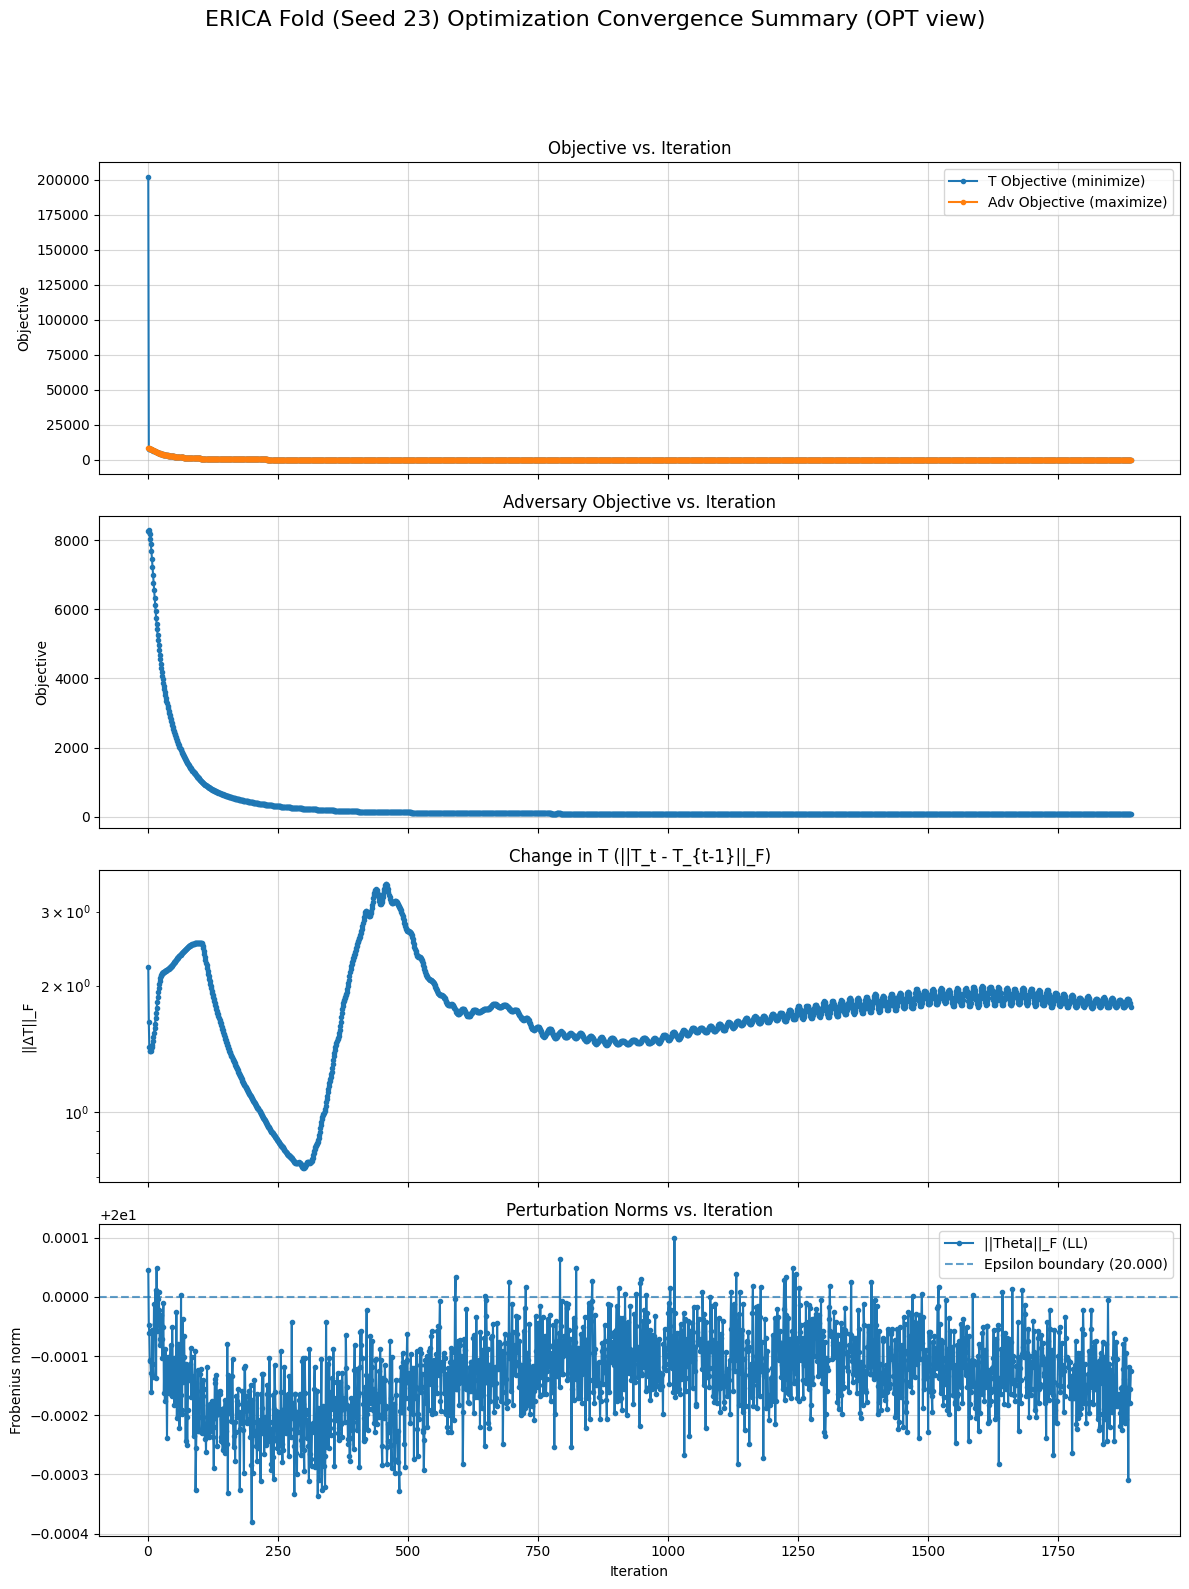

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_0.5_delta_0.0

--- Running DiRoCA 2/5: ε=1.0, δ=0.0 ---
Starting DiRoCA Training Run (OPT view): eps=1.0, del=0.0 (delta ignored)
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization (OPT view):  20%|█▉        | 1975/10000 [43:02<2:54:52,  1.31s/it]


Converged at iteration 1976 (delta_obj < 0.0001)


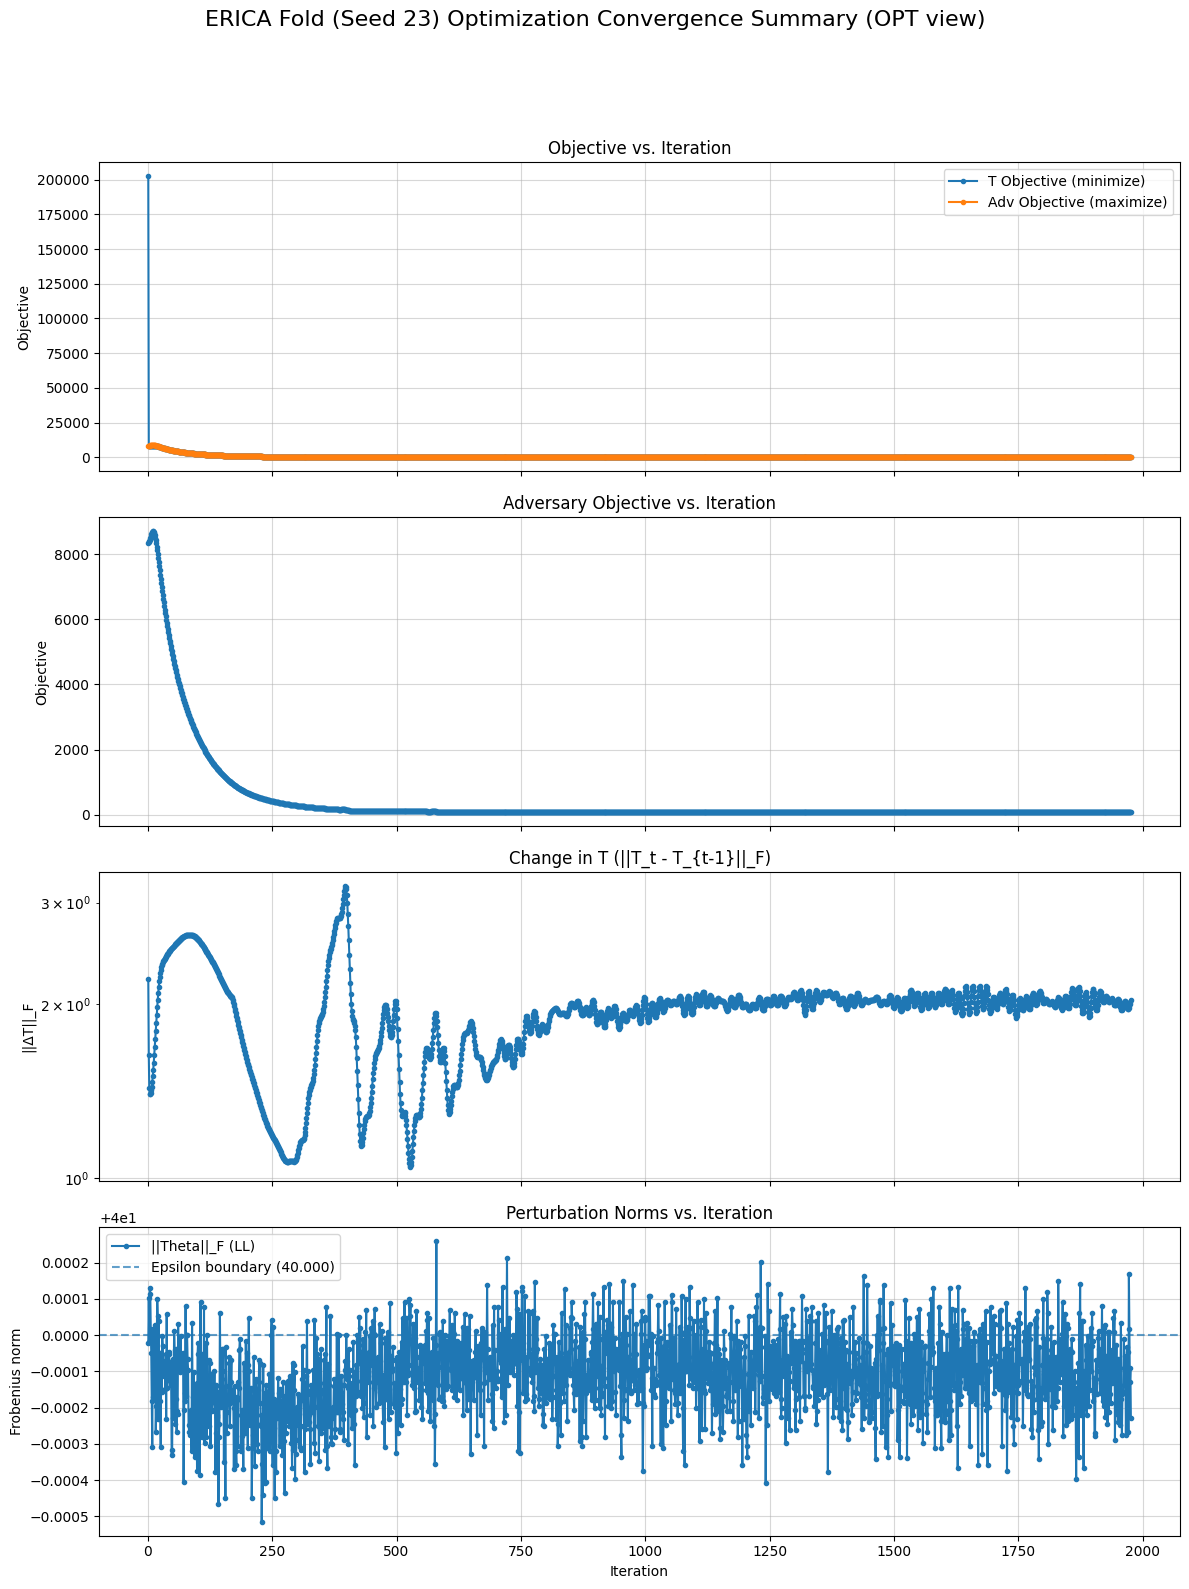

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_1.0_delta_0.0

--- Running DiRoCA 3/5: ε=2.0, δ=0.0 ---
Starting DiRoCA Training Run (OPT view): eps=2.0, del=0.0 (delta ignored)
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization (OPT view):  21%|██▏       | 2136/10000 [47:15<2:54:01,  1.33s/it]


Converged at iteration 2137 (delta_obj < 0.0001)


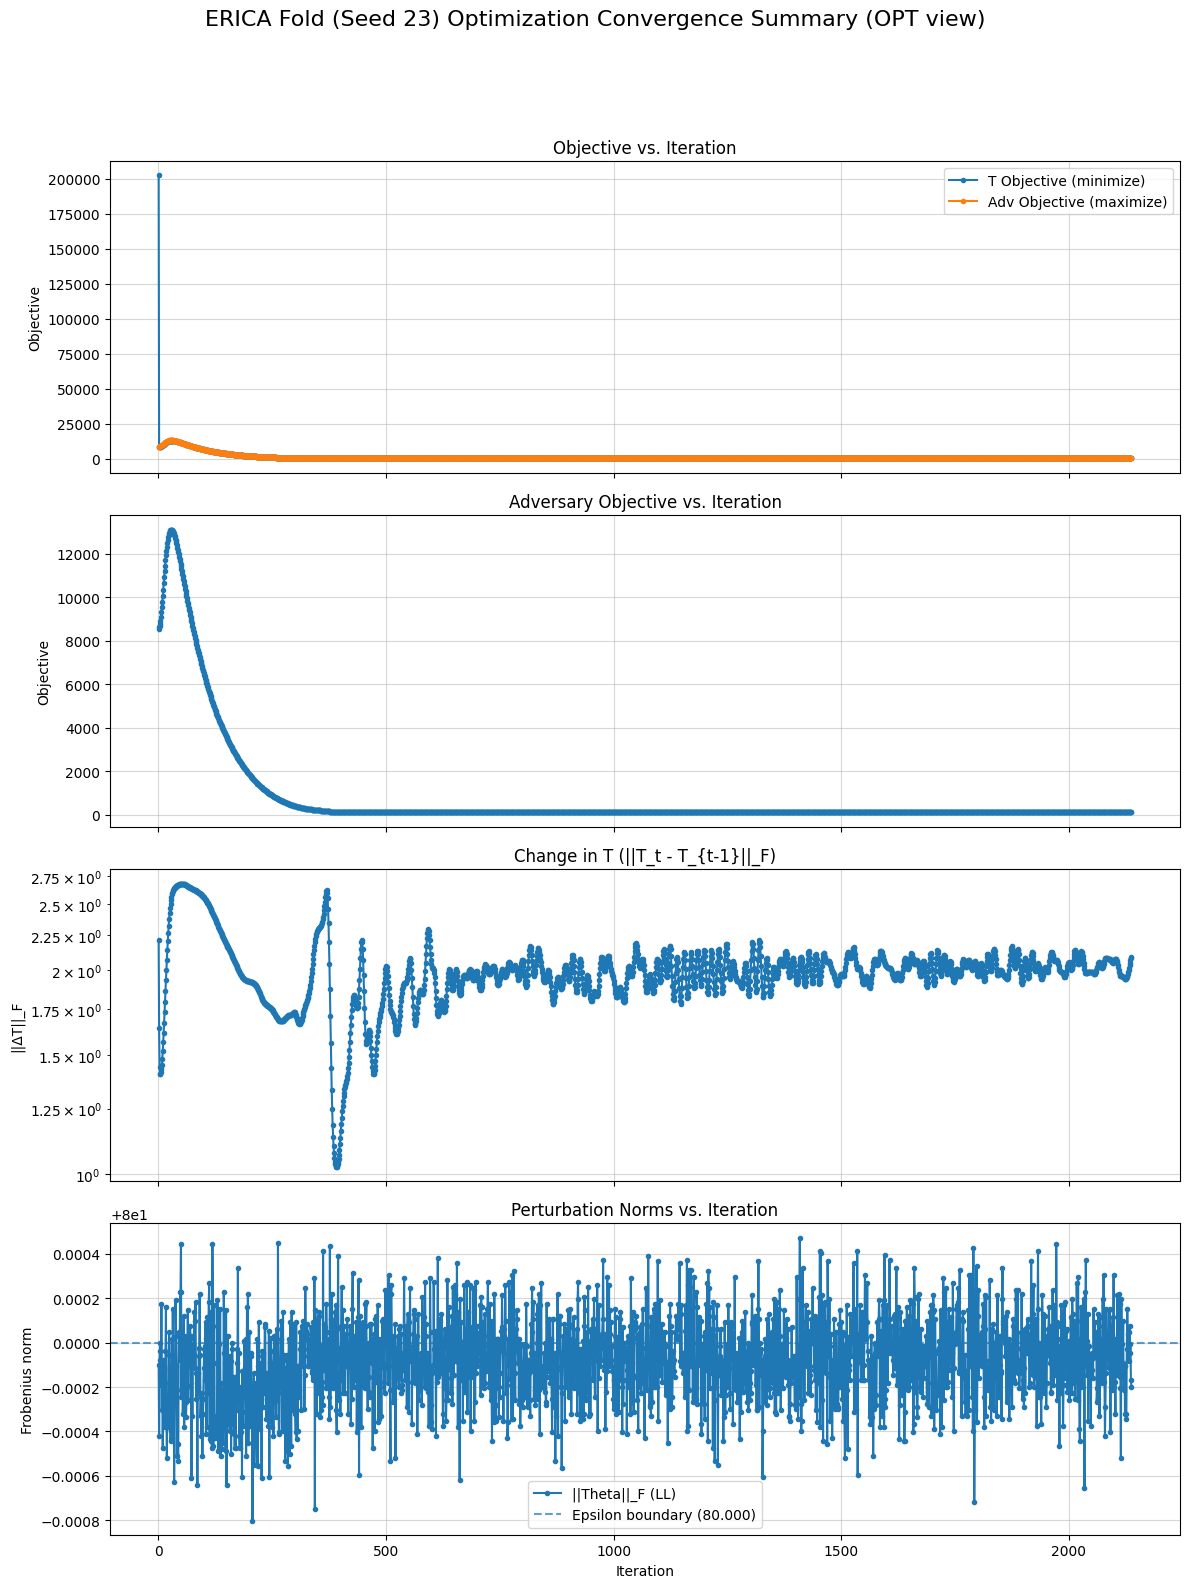

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_2.0_delta_0.0

--- Running DiRoCA 4/5: ε=4.0, δ=0.0 ---
Starting DiRoCA Training Run (OPT view): eps=4.0, del=0.0 (delta ignored)
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization (OPT view): 100%|██████████| 10000/10000 [3:50:41<00:00,  1.38s/it] 


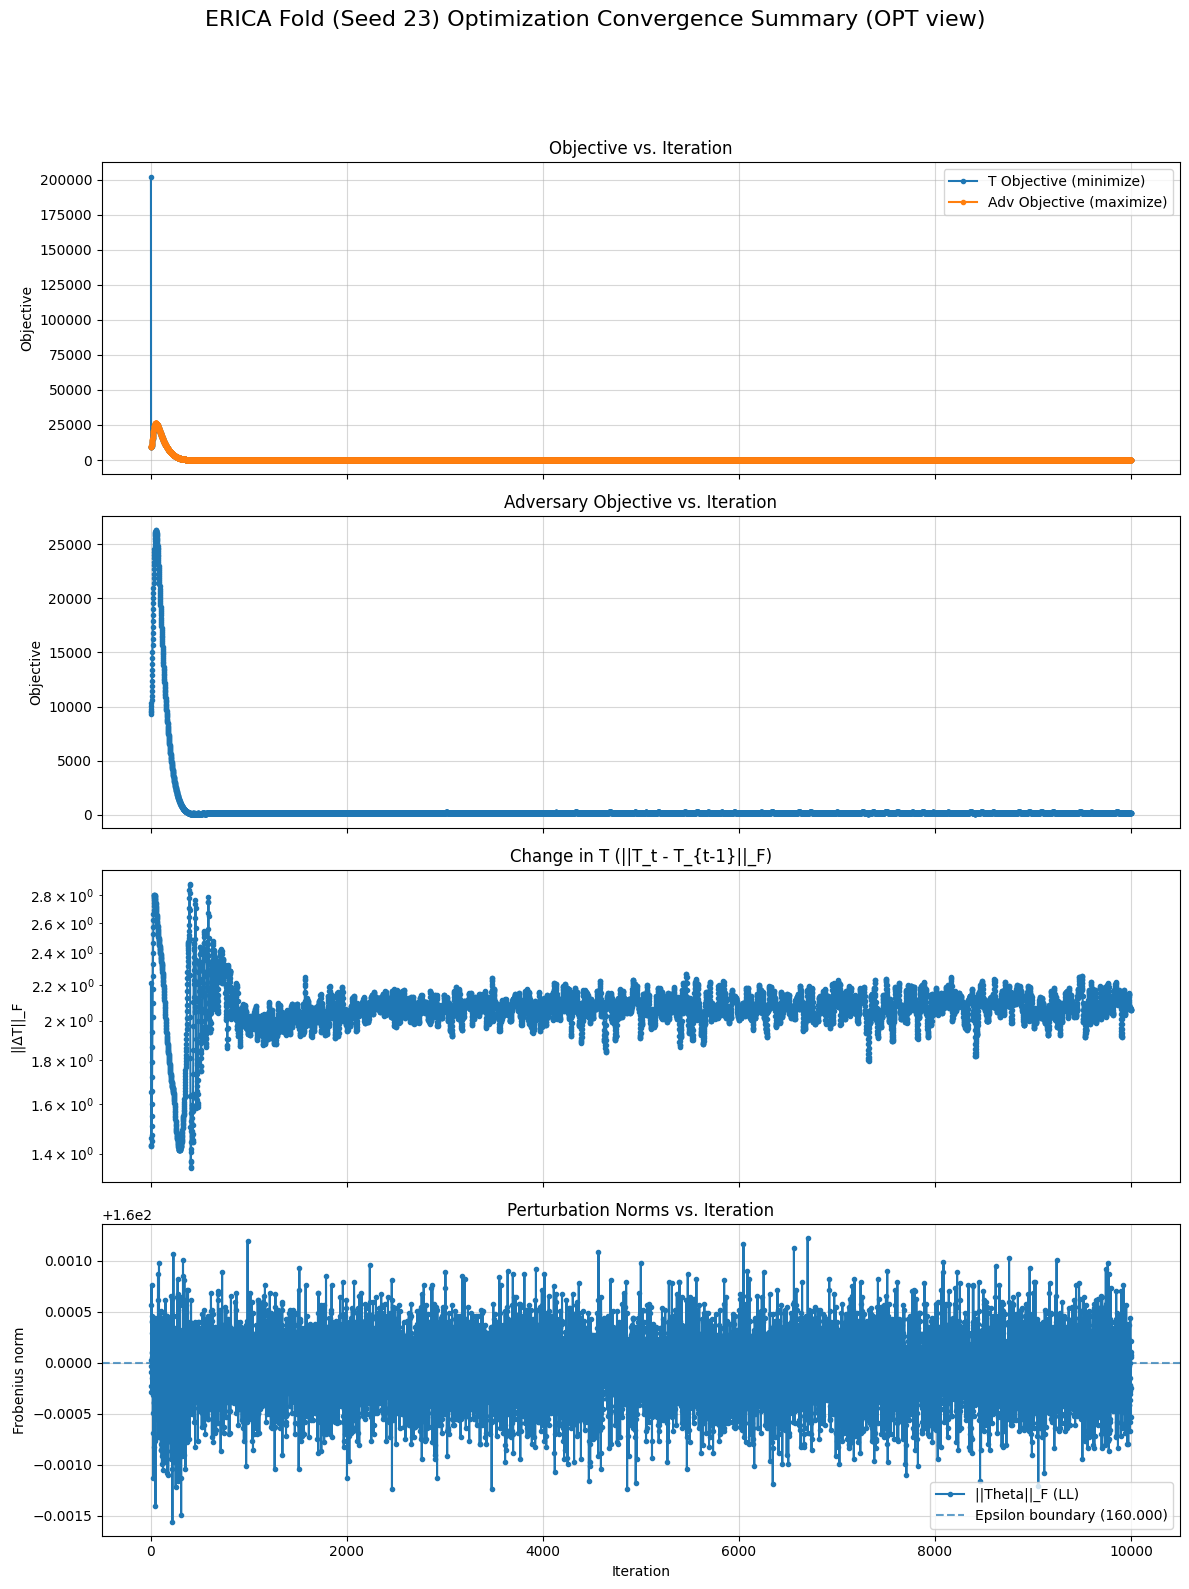

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_4.0_delta_0.0

--- Running DiRoCA 5/5: ε=8.0, δ=0.0 ---
Starting DiRoCA Training Run (OPT view): eps=8.0, del=0.0 (delta ignored)
Hyperparameters: {'eta_min': 0.001, 'eta_max': 0.001, 'max_iter': 10000, 'num_steps_min': 5, 'num_steps_max': 2, 'initialization': 'random', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ERICA Optimization (OPT view): 100%|██████████| 10000/10000 [3:50:43<00:00,  1.38s/it] 


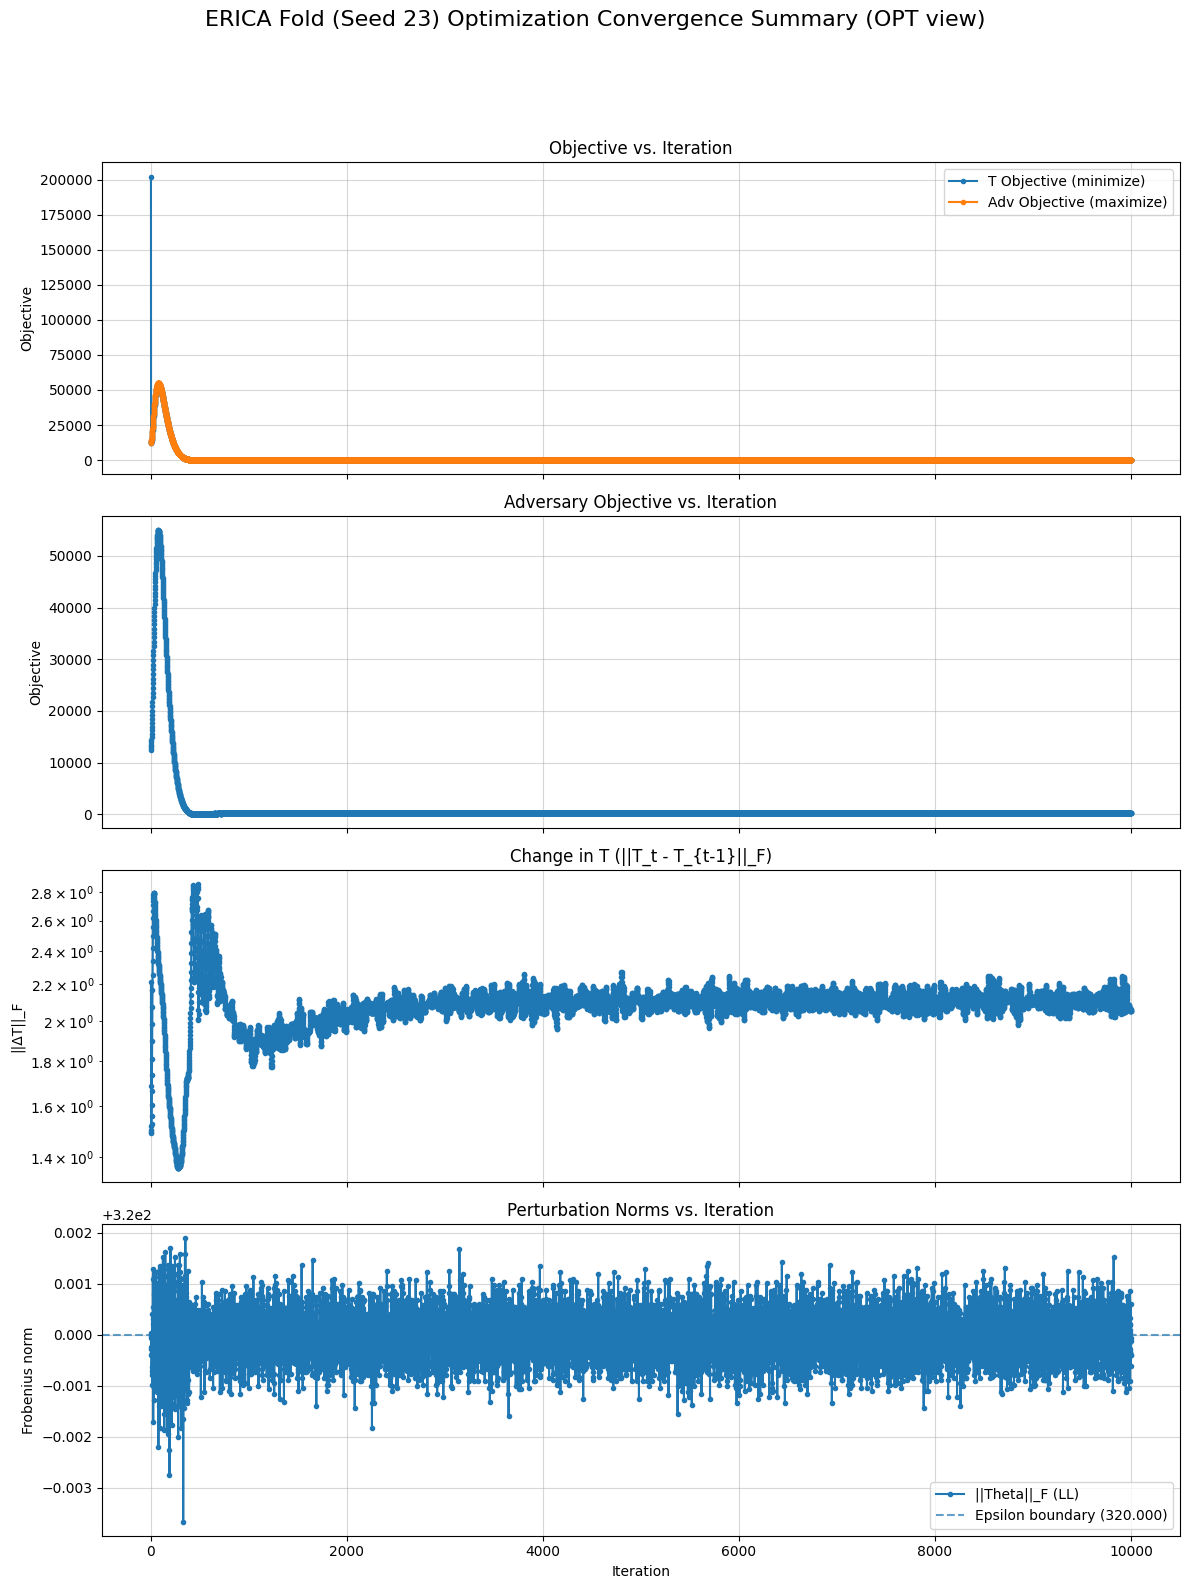

  ✓ Training completed for Fold 1

DiRoCA Training complete.
✓ Completed eps_8.0_delta_0.0

DiRoCA Multi-Radius Training Complete (OPT view)!

Results Summary:
  ✓ eps_0.5_delta_0.0: Success
  ✓ eps_1.0_delta_0.0: Success
  ✓ eps_2.0_delta_0.0: Success
  ✓ eps_4.0_delta_0.0: Success
  ✓ eps_8.0_delta_0.0: Success


In [14]:
import torch
import numpy as np
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print("\n" + "="*20 + " Training DiRoCA Multiple Radii (OPT view: δ=0) " + "="*20)

# --- Hyperparameters for DiRoCA ---
diroca_hyperparams = {
    'eta_min': 1e-3,
    'eta_max': 1e-3,
    'max_iter': 10000,
    'num_steps_min': 5,
    'num_steps_max': 2,   # still ok; Phi will be ignored if δ=0
    'initialization': 'random',
    'optimizers': 'adam',
}

fixed_params_diroca = {
    'tol': 1e-4,
    'seed': 23,
    'robust_L': True,
    'robust_H': False,   # OPT view: robust only at LL
    'experiment': 'cmnist',
    'gain': 0.0,
}

# ------------------------------------------------------------------
# OPT view: δ is fixed to 0 (no HL ambiguity).
# So we only sweep ε.
# ------------------------------------------------------------------
eps_list = [0.5, 1.0, 2.0, 4.0, 8.0]
radius_combinations = [(eps, 0.0) for eps in eps_list]

print(f"OPT view active: sweeping ε over {eps_list}, always using δ=0.0")

# --- Select noise tensors (use fixed versions if available) ---
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

# Sanity check
print(f"Using U_ll_hat_run with shape: {U_ll_hat_run.shape}")
print(f"Using U_hl_hat_run with shape: {U_hl_hat_run.shape}  (ignored in optimization if δ=0)")

# Store results for each radius combination
all_results_diroca = {}
all_monitors_diroca = {}

print(f"\nRunning DiRoCA for {len(radius_combinations)} radius combinations...")

for i, (epsilon, delta) in enumerate(radius_combinations):
    print(f"\n--- Running DiRoCA {i+1}/{len(radius_combinations)}: ε={epsilon}, δ={delta} ---")

    try:
        results_diroca, monitors_diroca = train_diroca_single_run(
            cv_folds,
            U_ll_hat_run,
            U_hl_hat_run,
            det_ll_dict,
            det_hl_dict,
            omega,
            diroca_hyperparams,
            fixed_params_diroca,
            epsilon,
            delta,
        )

        radius_key = f"eps_{epsilon}_delta_{delta}"
        all_results_diroca[radius_key] = results_diroca
        all_monitors_diroca[radius_key] = monitors_diroca

        print(f"✓ Completed {radius_key}")

    except Exception as e:
        radius_key = f"eps_{epsilon}_delta_{delta}"
        print(f"✗ Failed {radius_key}: {str(e)}")
        all_results_diroca[radius_key] = None
        all_monitors_diroca[radius_key] = None

    # Optional: free some memory between runs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "="*50)
print("DiRoCA Multi-Radius Training Complete (OPT view)!")
print("="*50)

# --- Summary of Results ---
print("\nResults Summary:")
for radius_key, results in all_results_diroca.items():
    if results is not None:
        print(f"  ✓ {radius_key}: Success")
    else:
        print(f"  ✗ {radius_key}: Failed")

# --- Access Individual Results Example ---
# Example: Access results for epsilon=2.0
# results_2 = all_results_diroca['eps_2.0_delta_0.0']
# monitors_2 = all_monitors_diroca['eps_2.0_delta_0.0']



==================== Training GradCA (δ = 0 OPT view) ====================
Using U_ll_hat_run with shape: torch.Size([2000, 3072])
Using U_hl_hat_run with shape: torch.Size([2000, 64])  (ignored since δ = 0)
Starting GradCA Training (OPT view)...
Hyperparameters: {'eta_min': 0.001, 'max_iter': 10000, 'num_steps_min': 1, 'initialization': 'zeros', 'optimizers': 'adam'}

--- Processing Fold 1/5 ---
Using device: cpu


ENRICO Optimization (OPT view):  81%|████████  | 8057/10000 [23:30<05:40,  5.71it/s]



Converged at iteration 8058 (delta_obj < 0.0001)


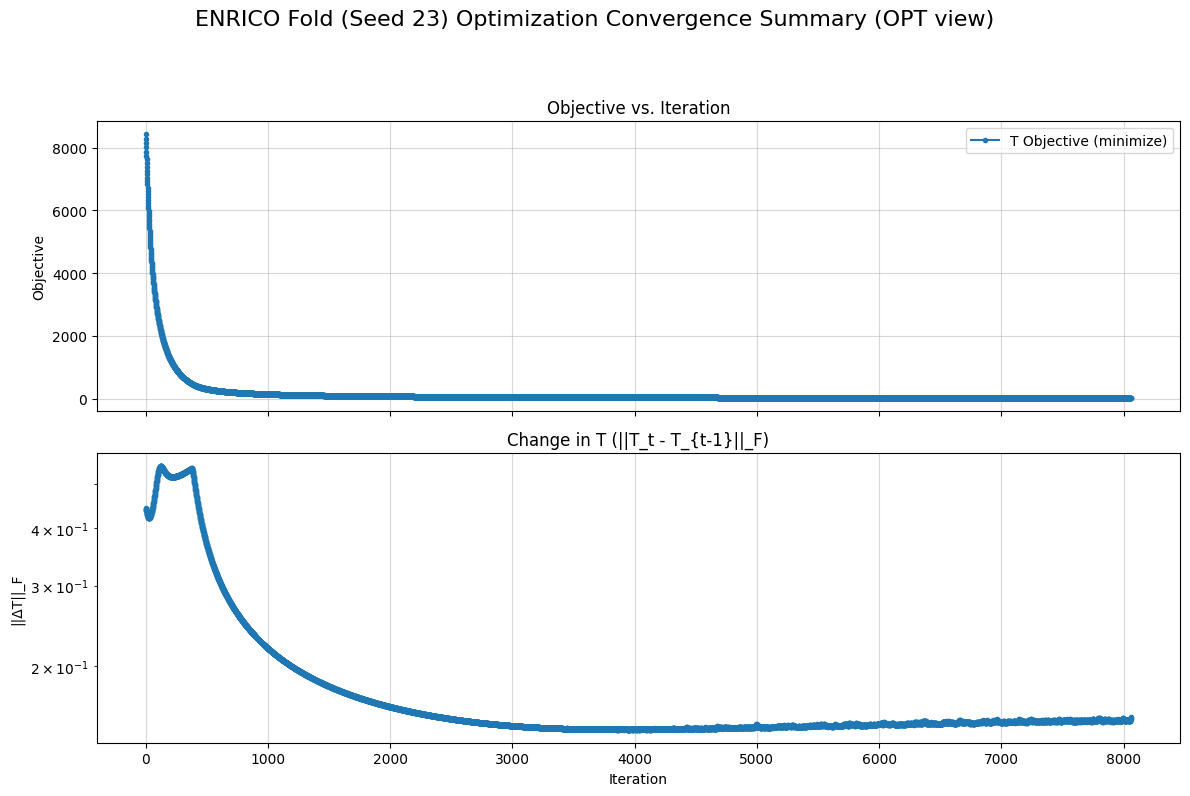

  ✓ Training completed for Fold 1

GradCA Training complete.

GradCA Training finished.


In [15]:
import torch
import numpy as np
import os
import gc
import pandas as pd  # Needed for monitor plots
import matplotlib.pyplot as plt  # Needed for monitor plots
from tqdm import tqdm  # Needed by monitor and optimizers

print("\n" + "="*20 + " Training GradCA (δ = 0 OPT view) " + "="*20)

# --- Hyperparameters for GradCA ---
gradca_hyperparams = {
    'eta_min': 1e-3,
    'max_iter': 10000,        # Number of outer iterations
    'num_steps_min': 1,      # T-update steps per iteration
    'initialization': 'zeros',
    'optimizers': 'adam',
}

fixed_params_gradca = {
    'tol': 1e-4,
    'seed': 23,
    'experiment': 'cmnist',
    'gain': 0.0,
}

# --- Select noise tensors (use fixed versions if available) ---
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

print(f"Using U_ll_hat_run with shape: {U_ll_hat_run.shape}")
print(f"Using U_hl_hat_run with shape: {U_hl_hat_run.shape}  (ignored since δ = 0)")

# --- Execute Training ---
results_gradca, monitors_gradca = train_gradca_single_run(
    cv_folds,
    U_ll_hat_run,
    U_hl_hat_run,
    det_ll_dict,
    det_hl_dict,
    omega,
    gradca_hyperparams,
    fixed_params_gradca,
)

print("\nGradCA Training finished.")

# Optional: free some memory after training
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [16]:
import torch
import numpy as np
from tqdm import tqdm
import torch.optim as optim

# ============================================================
# Barycentric objective: pixels → z, opt-view
# ============================================================

def barycentric_objective_cmnist_opt(
    T,
    U_ll_hat, U_hl_hat,
    det_ll_dict_opt, det_hl_dict_opt,
    omega,
):
    """
    BaryCA objective in the *opt view*:

      - LL: pixels only        X_ll(iota) ∈ R^{N × 3072}
      - HL: latent z only      X_hl(eta)  ∈ R^{N × z_dim}
      - T:  R^{3072} → R^{z_dim}

    We:
      1) Average the deterministic parts across interventions:
            avg_ll_pixels = mean_iota X_ll(iota)
            avg_hl_z      = mean_eta  X_hl(eta)
      2) Add the same noise U_ll_hat, U_hl_hat
      3) Match via T:

            loss = || T( avg_ll_pixels + U_ll_hat )
                     - ( avg_hl_z      + U_hl_hat ) ||_F^2 / N
    """
    device = T.device

    # Ensure noise on same device / shape (N, 3072) and (N, z_dim)
    U_ll_hat = torch.as_tensor(U_ll_hat, dtype=torch.float32, device=device)
    U_hl_hat = torch.as_tensor(U_hl_hat, dtype=torch.float32, device=device)

    if U_ll_hat.ndim > 2:
        U_ll_hat = U_ll_hat.view(U_ll_hat.shape[0], -1)
    if U_hl_hat.ndim > 2:
        U_hl_hat = U_hl_hat.view(U_hl_hat.shape[0], -1)

    ll_list = []
    hl_list = []
    num_envs = 0

    for iota, eta in omega.items():
        if iota in det_ll_dict_opt and eta in det_hl_dict_opt:
            X_ll = det_ll_dict_opt[iota].to(device)   # (N, 3072)
            X_hl = det_hl_dict_opt[eta].to(device)    # (N, z_dim)

            # Basic sanity: batch sizes must match noise
            if X_ll.shape[0] != U_ll_hat.shape[0] or X_hl.shape[0] != U_hl_hat.shape[0]:
                continue

            ll_list.append(X_ll)
            hl_list.append(X_hl)
            num_envs += 1

    if num_envs == 0:
        # No matching env pairs → zero loss (but something is misconfigured)
        return torch.tensor(0.0, device=device)

    # Average deterministic parts across envs
    avg_ll_pixels = torch.mean(torch.stack(ll_list, dim=0), dim=0)    # (N, 3072)
    avg_hl_z      = torch.mean(torch.stack(hl_list,  dim=0), dim=0)   # (N, z_dim)

    N = avg_ll_pixels.shape[0]

    noisy_ll = avg_ll_pixels + U_ll_hat     # (N, 3072)
    noisy_hl = avg_hl_z      + U_hl_hat     # (N, z_dim)

    # T: (z_dim, 3072), noisy_ll: (N, 3072)
    mapped_ll = (T @ noisy_ll.T).T          # (N, z_dim)
    diff = mapped_ll - noisy_hl
    loss = torch.norm(diff, p="fro")**2 / max(1, N)

    return loss


# ============================================================
# Core BaryCA optimizer (pixels → z, dict + omega API)
# ============================================================

def run_empirical_bary_optim_cmnist(
    U_ll_hat, U_hl_hat,
    det_ll_dict_opt, det_hl_dict_opt,
    omega,
    lr=1e-3,
    max_iter=5000,
    tol=1e-4,
    seed=42,
    monitor=None,
):
    """
    Core BaryCA optimization in the pixels→z opt-view.

    Args:
      U_ll_hat        : (N, 3072) low-level noise (pixels)
      U_hl_hat        : (N, z_dim) high-level noise (z)
      det_ll_dict_opt : {iota: (N, 3072)} deterministic pixels per env
      det_hl_dict_opt : {eta:  (N, z_dim)} deterministic z per env
      omega           : env mapping dict {iota -> eta}
      lr, max_iter, tol, seed: standard optimizer settings
      monitor         : EmpiricalMonitor or None

    Returns:
      T_opt  : numpy array (z_dim, 3072)
      monitor: EmpiricalMonitor with logs
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Prepare noise tensors ---
    U_ll_hat = torch.as_tensor(U_ll_hat, dtype=torch.float32, device=device)
    U_hl_hat = torch.as_tensor(U_hl_hat, dtype=torch.float32, device=device)
    if U_ll_hat.ndim > 2:
        U_ll_hat = U_ll_hat.view(U_ll_hat.shape[0], -1)
    if U_hl_hat.ndim > 2:
        U_hl_hat = U_hl_hat.view(U_hl_hat.shape[0], -1)

    N, l = U_ll_hat.shape     # l = 3072
    _, h = U_hl_hat.shape     # h = z_dim

    # --- Move deterministic dicts to device ---
    det_ll_dict_dev = {k: v.to(device) for k, v in det_ll_dict_opt.items()}
    det_hl_dict_dev = {k: v.to(device) for k, v in det_hl_dict_opt.items()}

    # --- Initialize T: (z_dim, 3072) ---
    T = torch.randn(h, l, device=device, requires_grad=True)
    optimizer = optim.Adam([T], lr=lr)

    prev_loss = float("inf")
    T_prev = None

    # Use your existing EmpiricalMonitor if present
    if monitor is None and "EmpiricalMonitor" in globals():
        monitor = EmpiricalMonitor()
    elif monitor is None:
        monitor = None  # Totally optional; code works without it

    for iteration in tqdm(range(max_iter), desc="BaryCA Optimization (OPT view)"):
        T_prev = T.detach().clone()

        optimizer.zero_grad()
        loss = barycentric_objective_cmnist_opt(
            T,
            U_ll_hat, U_hl_hat,
            det_ll_dict_dev, det_hl_dict_dev,
            omega,
        )

        if torch.isnan(loss):
            print(f"NaN loss encountered at iteration {iteration}. Stopping.")
            break

        loss.backward()
        optimizer.step()

        current_loss_item = loss.item()

        # Track if monitor is available
        if monitor is not None:
            monitor.track_iteration(
                iteration=iteration + 1,
                T_objective=current_loss_item,
                T_matrix=T,
                T_matrix_prev=T_prev,
            )

        if iteration % 50 == 0:
            tqdm.write(f"[BaryCA] Iter {iteration}, Loss={current_loss_item:.6f}")

        if abs(prev_loss - current_loss_item) < tol:
            print(f"Converged at iteration {iteration} (Δloss < {tol})")
            break

        prev_loss = current_loss_item

    print(f"Final BaryCA loss: {current_loss_item:.6f}")

    # Optional: show convergence plots
    if monitor is not None:
        monitor.plot_summary(title_prefix=f"BaryCA Fold (Seed {seed})")

    T_final = T.detach().cpu().numpy()
    return T_final, monitor

import torch
import numpy as np
import gc

def train_baryca_single_run(
    cv_folds,
    U_ll_hat, U_hl_hat,
    det_ll_dict_opt, det_hl_dict_opt,
    omega,
    run_hyperparams,
    fixed_params,
):
    """
    Wrapper to train BaryCA across CV folds in the pixels→z setting.

    Inputs:
      - cv_folds          : list of {'train': idx, 'test': idx}
      - U_ll_hat          : (N, 3072) noise on pixels
      - U_hl_hat          : (N, z_dim) noise on z
      - det_ll_dict_opt   : {iota: (N, 3072)} deterministic pixels
      - det_hl_dict_opt   : {eta:  (N, z_dim)} deterministic z
      - omega             : mapping dict {iota -> eta}
      - run_hyperparams   : {'lr':..., 'max_iter':..., 'tol':...}
      - fixed_params      : {'seed': ...}

    Returns:
      ({'baryca': {fold_key: { 'baryca_run': {...} }}}, monitors)
    """
    print("Starting BaryCA Training (OPT view)...")
    print(f"Hyperparameters: {run_hyperparams}")

    baryca_training_results = {}
    monitors = {}

    lr       = run_hyperparams.get("lr", 1e-3)
    max_iter = run_hyperparams.get("max_iter", 5000)
    tol      = run_hyperparams.get("tol", 1e-4)
    seed     = fixed_params.get("seed", 42)

    for i, fold_info in enumerate(cv_folds):
        fold_key = f"fold_{i}"
        print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
        train_indices, test_indices = fold_info["train"], fold_info["test"]

        # Slice noise
        U_ll_train = torch.as_tensor(U_ll_hat[train_indices], dtype=torch.float32)
        U_hl_train = torch.as_tensor(U_hl_hat[train_indices], dtype=torch.float32)
        if U_ll_train.ndim > 2:
            U_ll_train = U_ll_train.view(U_ll_train.shape[0], -1)
        if U_hl_train.ndim > 2:
            U_hl_train = U_hl_train.view(U_hl_train.shape[0], -1)

        # Slice deterministic opt-view dicts
        det_ll_train = {k: v[train_indices] for k, v in det_ll_dict_opt.items()}
        det_hl_train = {k: v[train_indices] for k, v in det_hl_dict_opt.items()}

        # Monitor per fold
        fold_monitor = EmpiricalMonitor() if "EmpiricalMonitor" in globals() else None

        try:
            T_opt, trained_monitor = run_empirical_bary_optim_cmnist(
                U_ll_train,
                U_hl_train,
                det_ll_train,
                det_hl_train,
                omega,
                lr=lr,
                max_iter=max_iter,
                tol=tol,
                seed=seed,
                monitor=fold_monitor,
            )

            method_key = "baryca_run"
            baryca_training_results[fold_key] = {
                method_key: {
                    "T_matrix": torch.tensor(T_opt, dtype=torch.float32),
                    "test_indices": test_indices,
                }
            }
            monitors[fold_key] = trained_monitor
            print(f"  ✓ BaryCA training completed for Fold {i+1}")
        except Exception as e:
            print(f"  ✗ ERROR during BaryCA training for Fold {i+1}: {e}")
            baryca_training_results[fold_key] = {"error": str(e)}
            monitors[fold_key] = None

        # keep your one-fold debug behaviour
        break

    print("\nBaryCA Training complete.")
    return {"baryca": baryca_training_results}, monitors



In [17]:
# import torch
# import numpy as np
# import os
# import gc
# import pandas as pd
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# print("\n" + "="*20 + " Training BaryCA (pixels → z only) " + "="*20)

# # --- Hyperparameters for BaryCA ---
# baryca_hyperparams = {
#     'lr': 1e-3,
#     'max_iter': 100,
#     'tol': 1e-4,
# }

# fixed_params_baryca = {
#     'seed': 23,
# }

# # --- Select noise tensors (use fixed versions if available) ---
# U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
# U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

# print(f"Using U_ll_hat_run with shape: {U_ll_hat_run.shape}  (pixels noise)")
# print(f"Using U_hl_hat_run with shape: {U_hl_hat_run.shape}  (raw z noise)")

# # ============================================================
# # OPT VIEW:
# #   LL opt-view: pixels only  -> (N, 3072)
# #   HL opt-view: z only       -> (N, z_dim inferred)
# # Also align U_hl_hat_run to the same z_dim.
# # ============================================================

# # infer z_dim from HL deterministic obs tensor
# obs_key = "obs"
# assert obs_key in det_hl_dict, f"{obs_key=} not in det_hl_dict keys."

# hl_full_dim = det_hl_dict[obs_key].shape[1]          # should be 20 + z_dim
# z_dim = hl_full_dim - 20
# assert z_dim > 0, f"Inferred z_dim={z_dim} is not positive. Check det_hl_dict shapes."

# print(f"Inferred z_dim from det_hl_dict['obs']: {z_dim}")

# # build reduced deterministic dicts
# det_ll_dict_opt = {k: v[:, :3072] for k, v in det_ll_dict.items()}
# det_hl_dict_opt = {k: v[:, 20:20+z_dim] for k, v in det_hl_dict.items()}

# # align HL noise to inferred z_dim
# if U_hl_hat_run.shape[1] != z_dim:
#     print(f"[Aligning] U_hl_hat_run dim {U_hl_hat_run.shape[1]} → {z_dim}")
#     U_hl_hat_run = U_hl_hat_run[:, :z_dim]

# some_iota = next(iter(det_ll_dict_opt.keys()))
# some_eta  = next(iter(det_hl_dict_opt.keys()))
# print(f"det_ll_dict_opt[{some_iota!r}] shape: {det_ll_dict_opt[some_iota].shape}")
# print(f"det_hl_dict_opt[{some_eta!r}] shape: {det_hl_dict_opt[some_eta].shape}")
# print(f"U_hl_hat_run aligned shape: {U_hl_hat_run.shape}")

# # --- Execute Training ---
# results_baryca, monitors_baryca = train_baryca_single_run(
#     cv_folds,
#     U_ll_hat_run,
#     U_hl_hat_run,
#     det_ll_dict_opt,
#     det_hl_dict_opt,
#     omega,
#     baryca_hyperparams,
#     fixed_params_baryca,
# )

# print("\nBaryCA Training finished.")

# gc.collect()
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()



==================== Training BaryCA (pixels → z only) ====================
Using U_ll_hat_run with shape: torch.Size([2000, 3072])  (pixels noise)
Using U_hl_hat_run with shape: torch.Size([2000, 64])  (raw z noise)
Inferred z_dim from det_hl_dict['obs']: 64
det_ll_dict_opt['obs'] shape: torch.Size([2000, 3072])
det_hl_dict_opt['obs'] shape: torch.Size([2000, 64])
U_hl_hat_run aligned shape: torch.Size([2000, 64])
Starting BaryCA Training (OPT view)...
Hyperparameters: {'lr': 0.001, 'max_iter': 10000, 'tol': 0.0001}

--- Processing Fold 1/5 ---
Using device: cpu


BaryCA Optimization (OPT view):   0%|          | 1/10000 [00:00<19:16,  8.65it/s]

[BaryCA] Iter 0, Loss=5001.152832


BaryCA Optimization (OPT view):   1%|          | 53/10000 [00:04<13:37, 12.17it/s]

[BaryCA] Iter 50, Loss=2370.701172


...

[BaryCA] Iter 9900, Loss=3.598123


BaryCA Optimization (OPT view): 100%|█████████▉| 9952/10000 [14:06<00:04, 11.76it/s]

[BaryCA] Iter 9950, Loss=3.525562


BaryCA Optimization (OPT view): 100%|██████████| 10000/10000 [14:10<00:00, 11.76it/s]


Final BaryCA loss: 3.455355


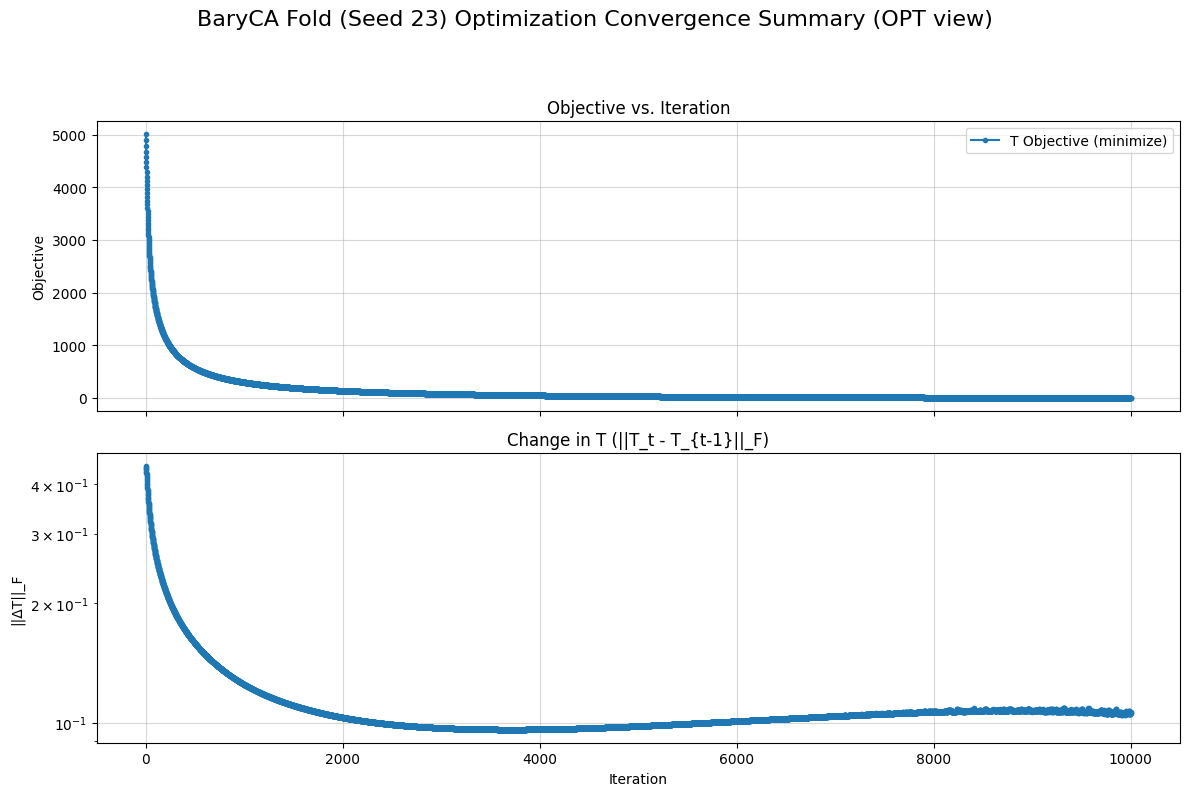

  ✓ BaryCA training completed for Fold 1

BaryCA Training complete.

BaryCA Training finished.


In [18]:
import torch
import numpy as np
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print("\n" + "="*20 + " Training BaryCA (pixels → z only) " + "="*20)

# --- Hyperparameters for BaryCA ---
baryca_hyperparams = {
    'lr': 1e-3,
    'max_iter': 10000,   # you can increase later if you want tighter convergence
    'tol': 1e-4,
}

fixed_params_baryca = {
    'seed': 23,
}

# --- Select noise tensors (use fixed versions if available) ---
U_ll_hat_run = U_ll_hat_fixed if 'U_ll_hat_fixed' in locals() else U_ll_hat
U_hl_hat_run = U_hl_hat_fixed if 'U_hl_hat_fixed' in locals() else U_hl_hat

print(f"Using U_ll_hat_run with shape: {U_ll_hat_run.shape}  (pixels noise)")
print(f"Using U_hl_hat_run with shape: {U_hl_hat_run.shape}  (raw z noise)")

# ============================================================
# OPT VIEW:
#   LL opt-view: pixels only  -> (N, 3072)
#   HL opt-view: z only       -> (N, z_dim inferred)
# Also align U_hl_hat_run to the same z_dim.
# ============================================================

# infer z_dim from HL deterministic obs tensor
obs_key = "obs"
assert obs_key in det_hl_dict, f"{obs_key=} not in det_hl_dict keys."

hl_full_dim = det_hl_dict[obs_key].shape[1]          # should be 20 + z_dim
z_dim = hl_full_dim - 20
assert z_dim > 0, f"Inferred z_dim={z_dim} is not positive. Check det_hl_dict shapes."

print(f"Inferred z_dim from det_hl_dict['obs']: {z_dim}")

# build reduced deterministic dicts: pixels-only LL, z-only HL
det_ll_dict_opt = {k: v[:, :3072]       for k, v in det_ll_dict.items()}     # (N, 3072)
det_hl_dict_opt = {k: v[:, 20:20+z_dim] for k, v in det_hl_dict.items()}     # (N, z_dim)

# align HL noise to inferred z_dim
if U_hl_hat_run.shape[1] != z_dim:
    print(f"[Aligning] U_hl_hat_run dim {U_hl_hat_run.shape[1]} → {z_dim}")
    U_hl_hat_run = U_hl_hat_run[:, :z_dim]

some_iota = next(iter(det_ll_dict_opt.keys()))
some_eta  = next(iter(det_hl_dict_opt.keys()))
print(f"det_ll_dict_opt[{some_iota!r}] shape: {det_ll_dict_opt[some_iota].shape}")
print(f"det_hl_dict_opt[{some_eta!r}] shape: {det_hl_dict_opt[some_eta].shape}")
print(f"U_hl_hat_run aligned shape: {U_hl_hat_run.shape}")

# --- Execute Training ---
results_baryca, monitors_baryca = train_baryca_single_run(
    cv_folds,
    U_ll_hat_run,
    U_hl_hat_run,
    det_ll_dict_opt,   # pixels only
    det_hl_dict_opt,   # z only
    omega,
    baryca_hyperparams,
    fixed_params_baryca,
)

print("\nBaryCA Training finished.")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [19]:
# # ==========================
# # TRAINING Abs-LiNGAM (SELF-CONTAINED, pixels → z only)
# # ==========================
# import torch
# import numpy as np
# import gc

# print("\n" + "="*20 + " Training Abs-LiNGAM (pixels → z only, SELF-CONTAINED) " + "="*20)

# # --- Hyperparameters for Abs-LiNGAM ---
# abslingam_hyperparams = {
#     'tau_perfect': 1e-2,
#     'tau_noisy': 1e-1,
# }
# tau_p = abslingam_hyperparams['tau_perfect']
# tau_n = abslingam_hyperparams['tau_noisy']

# # ------------------------------------------------------------
# # Local fallbacks (in case CELL 9 wasn't run in this kernel)
# # ------------------------------------------------------------
# if "perfect_abstraction" not in globals():
#     def perfect_abstraction(px_samples, py_samples, tau_threshold=1e-2):
#         """
#         Dense least-squares: px @ T ≈ py, via pinv.
#         px: (N, D_ll), py: (N, D_hl)
#         returns T_raw: (D_ll, D_hl)
#         """
#         T_raw = np.linalg.pinv(px_samples) @ py_samples
#         mask = (np.abs(T_raw) > tau_threshold)
#         return T_raw * mask

# if "noisy_abstraction" not in globals():
#     def noisy_abstraction(px_samples, py_samples, tau_threshold=1e-1, refit_coeff=False):
#         """
#         Sparse argmax-per-row mask on pinv solution.
#         px: (N, D_ll), py: (N, D_hl)
#         returns T_masked: (D_ll, D_hl)
#         """
#         T_raw_hat = np.linalg.pinv(px_samples) @ py_samples
#         D_hl = py_samples.shape[1]
#         argmax_idx = np.argmax(np.abs(T_raw_hat), axis=1)          # (D_ll,)
#         onehot = np.eye(D_hl)[argmax_idx]                          # (D_ll, D_hl)
#         onehot *= (np.abs(T_raw_hat) > tau_threshold).astype(int)  # thresh
#         return onehot * T_raw_hat

# # --- Safety checks ---
# assert "obs" in det_ll_dict, "det_ll_dict must contain 'obs'"
# assert "obs" in det_hl_dict, "det_hl_dict must contain 'obs'"

# det_ll_obs_all = det_ll_dict["obs"]  # (N, 3092)
# det_hl_obs_all = det_hl_dict["obs"]  # (N, 84)

# ll_pix_dim = 3072
# hl_label_dim = 20
# hl_z_dim = det_hl_obs_all.shape[1] - hl_label_dim
# assert hl_z_dim > 0, f"HL z-dim inferred as {hl_z_dim}, expected >0"

# print(f"det_ll_obs_all shape: {det_ll_obs_all.shape}")
# print(f"det_hl_obs_all shape: {det_hl_obs_all.shape}")
# print(f"Inferred hl_z_dim = {hl_z_dim}")

# abslingam_training_results = {}

# for i, fold_info in enumerate(cv_folds):
#     fold_key = f'fold_{i}'
#     print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
#     train_indices, test_indices = fold_info['train'], fold_info['test']

#     try:
#         # --- Slice observational deterministic data for this fold ---
#         det_ll_train = det_ll_obs_all[train_indices]  # (N_train, 3092)
#         det_hl_train = det_hl_obs_all[train_indices]  # (N_train, 84)

#         # --- NEW SETTING: fit ONLY pixels → z ---
#         X_pix = det_ll_train[:, :ll_pix_dim]       # (N_train, 3072)
#         Y_z   = det_hl_train[:, hl_label_dim:]     # (N_train, 64)

#         X_pix_np = X_pix.detach().cpu().numpy().astype(np.float32)
#         Y_z_np   = Y_z.detach().cpu().numpy().astype(np.float32)

#         # --- Run Abs-LiNGAM ---
#         T_perfect_raw = perfect_abstraction(X_pix_np, Y_z_np, tau_threshold=tau_p)  # (3072, 64)
#         T_noisy_raw   = noisy_abstraction(X_pix_np, Y_z_np, tau_threshold=tau_n, refit_coeff=False)

#         # transpose to (64, 3072)
#         T_perfect = T_perfect_raw.T.astype(np.float32)
#         T_noisy   = T_noisy_raw.T.astype(np.float32)

#         abslingam_training_results[fold_key] = {
#             "Abs-LiNGAM (Perfect)": {
#                 "T_matrix": torch.tensor(T_perfect, dtype=torch.float32),
#                 "test_indices": test_indices,
#             },
#             "Abs-LiNGAM (Noisy)": {
#                 "T_matrix": torch.tensor(T_noisy, dtype=torch.float32),
#                 "test_indices": test_indices,
#             }
#         }

#         print(f"  ✓ Abs-LiNGAM completed for Fold {i+1}")
#         print(f"    Perfect T shape: {T_perfect.shape}")
#         print(f"    Noisy   T shape: {T_noisy.shape}")

#     except Exception as e:
#         print(f"  ✗ ERROR during Abs-LiNGAM for Fold {i+1}: {e}")
#         abslingam_training_results[fold_key] = {'error': str(e)}

#     break  # keep your debug 1-fold behavior

# print("\nAbs-LiNGAM Training finished.")

# results_abslingam = {'abslingam': abslingam_training_results}

# gc.collect()
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()


In [20]:
# ==========================
# TRAINING Abs-LiNGAM (SELF-CONTAINED, pixels → z only)
# ==========================
import torch
import numpy as np
import gc

print("\n" + "="*20 + " Training Abs-LiNGAM (pixels → z only, SELF-CONTAINED) " + "="*20)

# --- Hyperparameters ---
abslingam_hyperparams = {
    'tau_perfect': 1e-2,
    'tau_noisy':  1e-1,
}
tau_p = abslingam_hyperparams['tau_perfect']
tau_n = abslingam_hyperparams['tau_noisy']


# ------------------------------------------------------------
# Local fallback definitions (safe defaults)
# ------------------------------------------------------------
if "perfect_abstraction" not in globals():
    def perfect_abstraction(px_samples, py_samples, tau_threshold=1e-2):
        T_raw = np.linalg.pinv(px_samples) @ py_samples
        mask = (np.abs(T_raw) > tau_threshold)
        return T_raw * mask

if "noisy_abstraction" not in globals():
    def noisy_abstraction(px_samples, py_samples, tau_threshold=1e-1, refit_coeff=False):
        T_raw = np.linalg.pinv(px_samples) @ py_samples
        D_hl = py_samples.shape[1]
        argmax_idx = np.argmax(np.abs(T_raw), axis=1)
        onehot = np.eye(D_hl)[argmax_idx]
        onehot *= (np.abs(T_raw) > tau_threshold).astype(int)
        return onehot * T_raw


# --- Check observational keys ---
assert "obs" in det_ll_dict, "det_ll_dict must contain key 'obs'"
assert "obs" in det_hl_dict, "det_hl_dict must contain key 'obs'"

det_ll_obs_all = det_ll_dict["obs"]   # (N, 3092)
det_hl_obs_all = det_hl_dict["obs"]   # (N, 84) or (N, 64)

print(f"det_ll_obs_all shape: {det_ll_obs_all.shape}")
print(f"det_hl_obs_all shape: {det_hl_obs_all.shape}")

# --- Robustly extract z dims (64) ---
if det_hl_obs_all.shape[1] == 84:
    # [digit_onehot(10), color_onehot(10), z(64)]
    Y_z_all = det_hl_obs_all[:, 20:]
elif det_hl_obs_all.shape[1] == 64:
    # z-only (already)
    Y_z_all = det_hl_obs_all
else:
    raise ValueError(
        f"Unexpected HL dimension {det_hl_obs_all.shape[1]}, expected 84 or 64"
    )

print(f"Inferred z-dim = {Y_z_all.shape[1]}")


# --- LL pixels ---
X_pix_all = det_ll_obs_all[:, :3072]  # (N, 3072)


abslingam_training_results = {}

for i, fold_info in enumerate(cv_folds):
    fold_key = f'fold_{i}'
    print(f"\n--- Processing Fold {i+1}/{len(cv_folds)} ---")
    train_idx, test_idx = fold_info["train"], fold_info["test"]

    try:
        X_pix = X_pix_all[train_idx]
        Y_z   = Y_z_all[train_idx]

        X_np = X_pix.detach().cpu().numpy().astype(np.float32)
        Y_np = Y_z.detach().cpu().numpy().astype(np.float32)

        # --- Compute Abs-LiNGAM estimators ---
        T_perfect_raw = perfect_abstraction(X_np, Y_np, tau_threshold=tau_p)  # (3072, 64)
        T_noisy_raw   = noisy_abstraction(X_np, Y_np, tau_threshold=tau_n)

        # Transpose to match baseline convention (64 × 3072)
        T_perfect = T_perfect_raw.T.astype(np.float32)
        T_noisy   = T_noisy_raw.T.astype(np.float32)

        abslingam_training_results[fold_key] = {
            "Abs-LiNGAM (Perfect)": {
                "T_matrix": torch.tensor(T_perfect, dtype=torch.float32),
                "test_indices": test_idx,
            },
            "Abs-LiNGAM (Noisy)": {
                "T_matrix": torch.tensor(T_noisy, dtype=torch.float32),
                "test_indices": test_idx,
            }
        }

        print(f"  ✓ Abs-LiNGAM completed for Fold {i+1}")
        print(f"    Perfect T shape: {T_perfect.shape}")
        print(f"    Noisy   T shape: {T_noisy.shape}")

    except Exception as e:
        print(f"  ✗ ERROR during Abs-LiNGAM for Fold {i+1}: {e}")
        abslingam_training_results[fold_key] = {"error": str(e)}

    break  # preserve your debugging behavior (run 1 fold only)


print("\nAbs-LiNGAM Training finished.")

results_abslingam = {"abslingam": abslingam_training_results}

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



==================== Training Abs-LiNGAM (pixels → z only, SELF-CONTAINED) ====================
det_ll_obs_all shape: torch.Size([2000, 3092])
det_hl_obs_all shape: torch.Size([2000, 84])
Inferred z-dim = 64

--- Processing Fold 1/5 ---
  ✓ Abs-LiNGAM completed for Fold 1
    Perfect T shape: (64, 3072)
    Noisy   T shape: (64, 3072)

Abs-LiNGAM Training finished.


In [21]:
# --- Merge results from individual training runs ---
print("Merging results from all training runs...")

all_results = {}

def _is_valid_method_dict(x):
    return isinstance(x, dict) and len(x) > 0

# ================== DiRoCA (multiple radii) ==================
# all_results_diroca: {radius_key: {'diroca': {fold_key: ...}}}
if 'all_results_diroca' in locals() and isinstance(all_results_diroca, dict):
    for radius_key, results_outer in all_results_diroca.items():
        if not _is_valid_method_dict(results_outer):
            print(f"  ✗ Skipped DiRoCA results for {radius_key} (None/invalid).")
            continue

        if 'diroca' not in results_outer or not isinstance(results_outer['diroca'], dict):
            print(f"  ✗ Skipped DiRoCA results for {radius_key} (missing 'diroca' key).")
            continue

        method_name = f"diroca_{radius_key}"   # e.g. 'diroca_eps_1.0_delta_0.0'
        all_results[method_name] = results_outer['diroca']
        print(f"  ✓ Added DiRoCA results for {radius_key}.")
else:
    print("  ✗ Warning: DiRoCA results ('all_results_diroca') not found or invalid.")

# ================== GradCA ==================
# results_gradca: {'gradca': {fold_key: ...}}
if 'results_gradca' in locals() and isinstance(results_gradca, dict) and 'gradca' in results_gradca:
    if isinstance(results_gradca['gradca'], dict):
        all_results['gradca'] = results_gradca['gradca']
        print("  ✓ Added GradCA results (single run).")
    else:
        print("  ✗ Warning: results_gradca['gradca'] not a dict.")
else:
    print("  ✗ Warning: GradCA results not found or invalid.")

# ================== BaryCA ==================
# results_baryca: {'baryca': {fold_key: ...}}
if 'results_baryca' in locals() and isinstance(results_baryca, dict) and 'baryca' in results_baryca:
    if isinstance(results_baryca['baryca'], dict):
        all_results['baryca'] = results_baryca['baryca']
        print("  ✓ Added BaryCA results (single run).")
    else:
        print("  ✗ Warning: results_baryca['baryca'] not a dict.")
else:
    print("  ✗ Warning: BaryCA results not found or invalid.")

# ================== Abs-LiNGAM ==================
# results_abslingam: {'abslingam': {fold_key: {'Abs-LiNGAM (Perfect)':..., 'Abs-LiNGAM (Noisy)':...}}}
if 'results_abslingam' in locals() and isinstance(results_abslingam, dict) and 'abslingam' in results_abslingam:
    if isinstance(results_abslingam['abslingam'], dict):
        all_results['abslingam'] = results_abslingam['abslingam']
        print("  ✓ Added Abs-LiNGAM results (single run).")
    else:
        print("  ✗ Warning: results_abslingam['abslingam'] not a dict.")
else:
    print("  ✗ Warning: Abs-LiNGAM results not found or invalid.")

# ================== Summary / Sanity Check ==================
print("\nStructure of merged 'all_results':")
if not all_results:
    print("  'all_results' is empty. Cannot proceed with evaluation.")
else:
    for method_name, fold_dict in all_results.items():
        if not isinstance(fold_dict, dict):
            print(f"  - {method_name}: invalid (not a dict).")
            continue

        total_folds = len(fold_dict)
        valid_folds = 0
        for fold_key, fold_data in fold_dict.items():
            if isinstance(fold_data, dict) and 'error' not in fold_data:
                valid_folds += 1

        print(f"  - {method_name}: Contains results for {valid_folds}/{total_folds} folds.")

        # Extra info for Abs-LiNGAM variants
        if method_name == 'abslingam' and valid_folds > 0:
            # find first non-error fold
            first_valid_fold = None
            for fk, fd in fold_dict.items():
                if isinstance(fd, dict) and 'error' not in fd:
                    first_valid_fold = fk
                    break
            if first_valid_fold is not None:
                print(f"    (Abs-LiNGAM variants in {first_valid_fold}: "
                      f"{list(fold_dict[first_valid_fold].keys())})")

print("\nMerging complete.")


Merging results from all training runs...
  ✓ Added DiRoCA results for eps_0.5_delta_0.0.
  ✓ Added DiRoCA results for eps_1.0_delta_0.0.
  ✓ Added DiRoCA results for eps_2.0_delta_0.0.
  ✓ Added DiRoCA results for eps_4.0_delta_0.0.
  ✓ Added DiRoCA results for eps_8.0_delta_0.0.
  ✓ Added GradCA results (single run).
  ✓ Added BaryCA results (single run).
  ✓ Added Abs-LiNGAM results (single run).

Structure of merged 'all_results':
  - diroca_eps_0.5_delta_0.0: Contains results for 1/1 folds.
  - diroca_eps_1.0_delta_0.0: Contains results for 1/1 folds.
  - diroca_eps_2.0_delta_0.0: Contains results for 1/1 folds.
  - diroca_eps_4.0_delta_0.0: Contains results for 1/1 folds.
  - diroca_eps_8.0_delta_0.0: Contains results for 1/1 folds.
  - gradca: Contains results for 1/1 folds.
  - baryca: Contains results for 1/1 folds.
  - abslingam: Contains results for 1/1 folds.
    (Abs-LiNGAM variants in fold_0: ['Abs-LiNGAM (Perfect)', 'Abs-LiNGAM (Noisy)'])

Merging complete.


In [22]:
print('done! long run!')

done! long run!



==================== Visualizing Adversarial Perturbations (UPDATED) ====================
Using DiRoCA results: diroca_eps_0.5_delta_0.0
Using run key: eps_0.5_delta_0.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21289207..0.19954887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027298685..0.025063505].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.40364233..0.2693317].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.025899533..0.02146288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32553926..0.2432847].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.026963634..0.025607012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got r

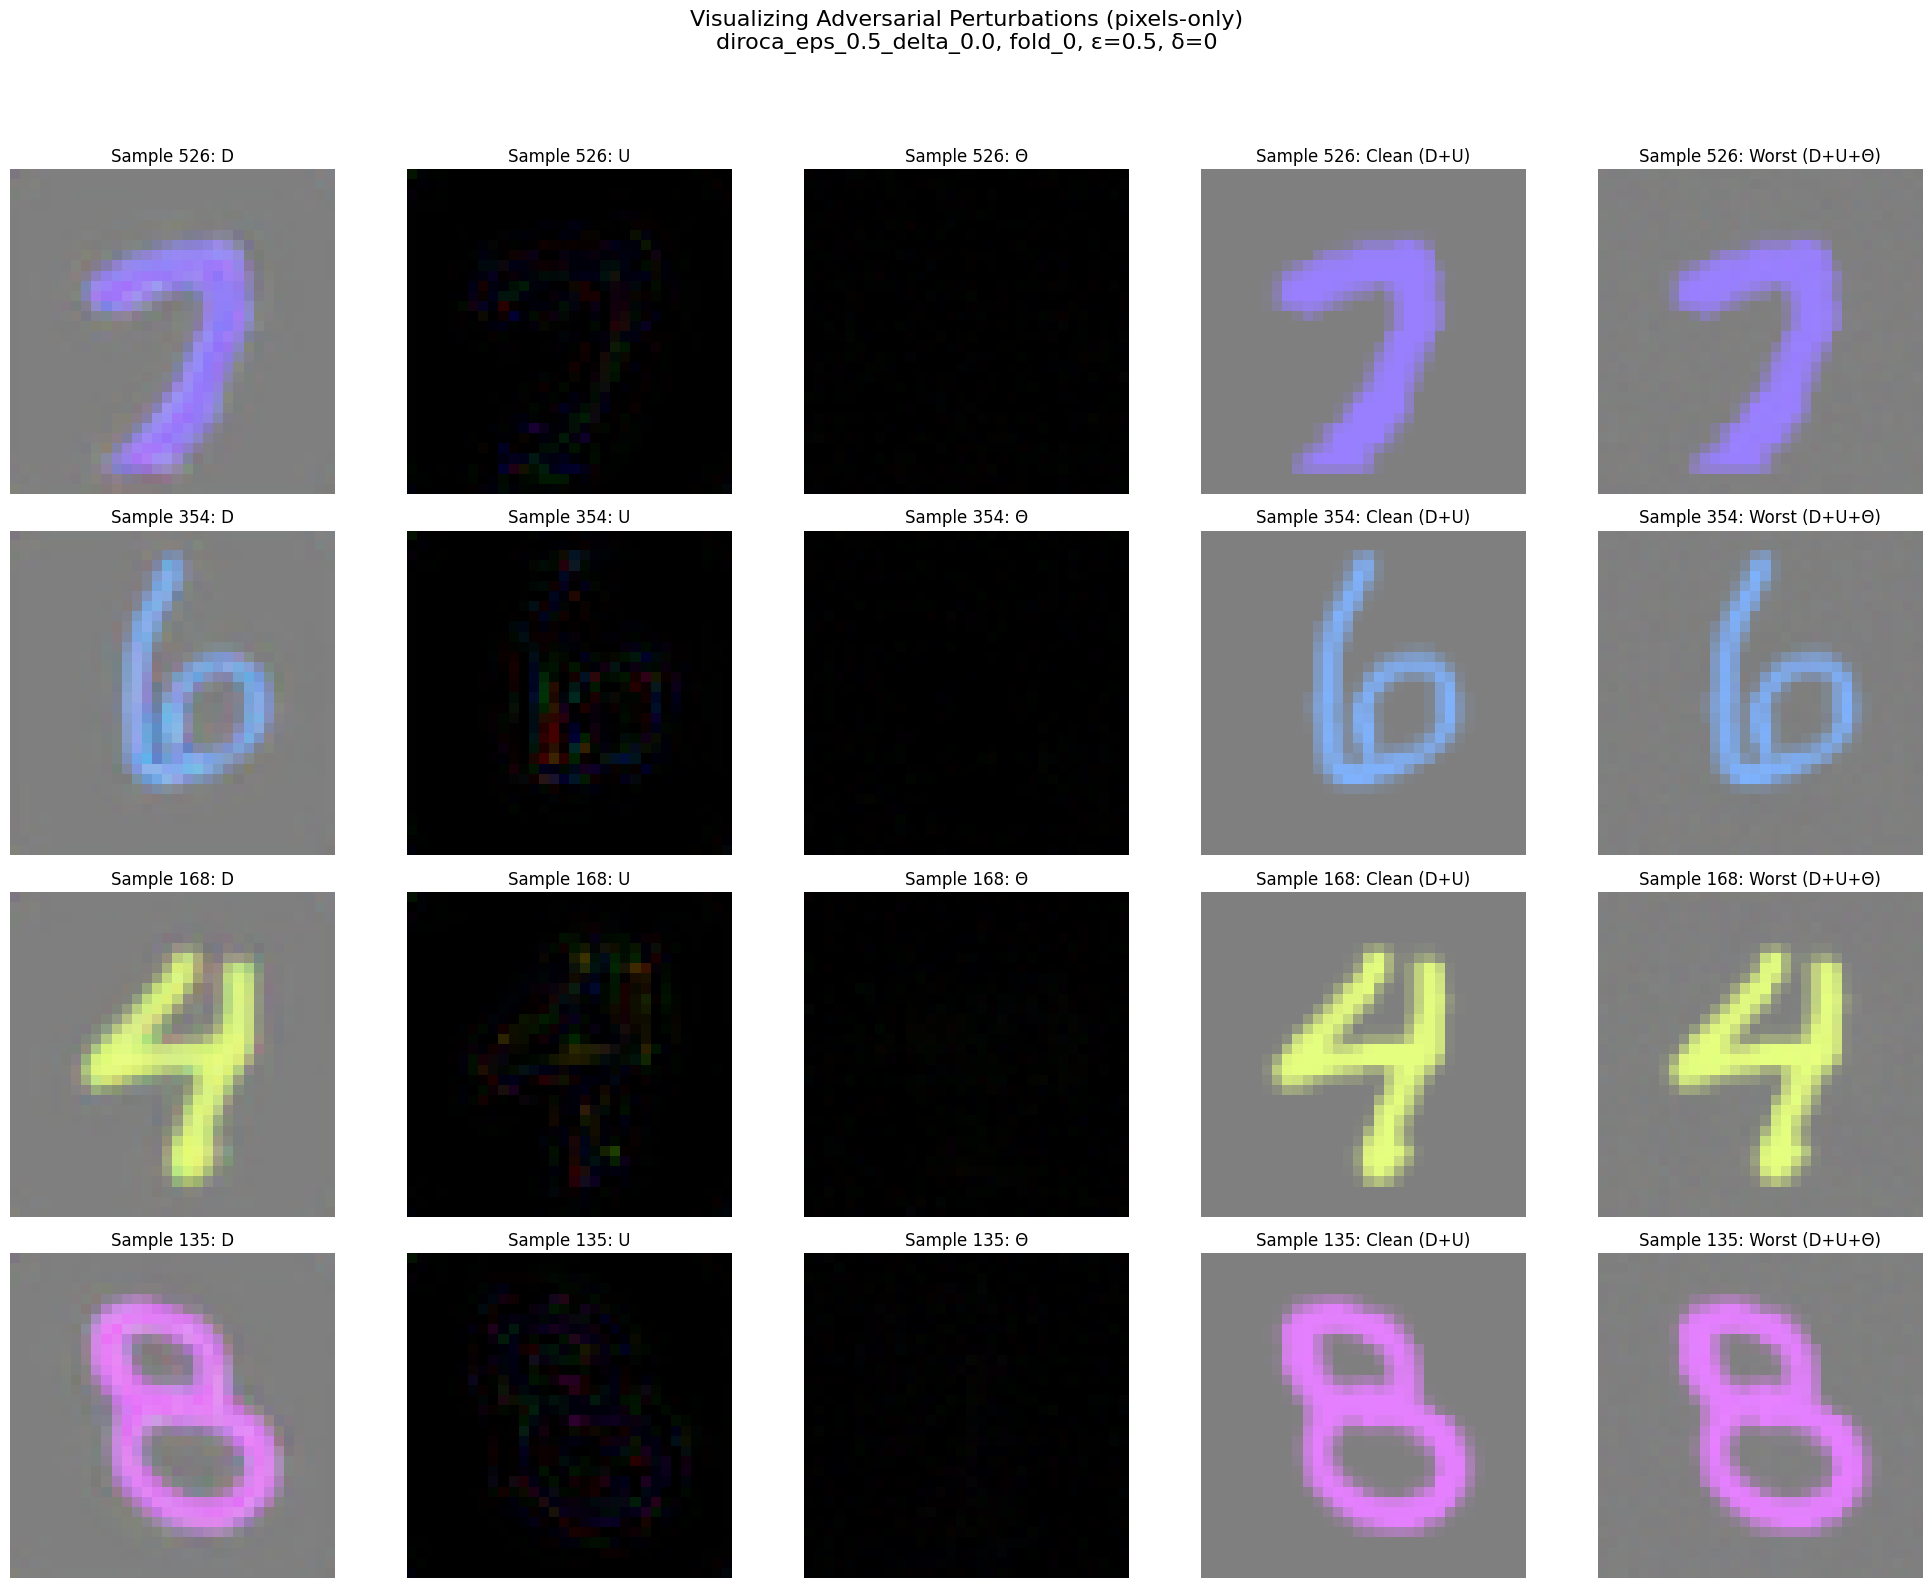

✓ Visualization completed successfully!


In [23]:
# --- Visualization Cell (CMNIST) — UPDATED for pixels-only optimization + delta=0 ---
import matplotlib.pyplot as plt
import torch
import numpy as np

print("\n" + "="*20 + " Visualizing Adversarial Perturbations (UPDATED) " + "="*20)

# ------------------------------------------------------------
# 0) Helper: find observational LL key in det_ll_dict
# ------------------------------------------------------------
def find_obs_ll_key(det_ll_dict):
    keys = list(det_ll_dict.keys())
    if not keys:
        raise ValueError("det_ll_dict is empty; cannot find observational key.")
    for k in keys:
        if isinstance(k, str) and k.lower() in ["obs", "observational", "none", "null"]:
            return k
        label = getattr(k, "label", None)
        if isinstance(label, str) and label.lower() in ["obs", "observational"]:
            return k
    print("[Warning] No explicit obs key found. Falling back to first key:", keys[0])
    return keys[0]

# ------------------------------------------------------------
# 1) Select DiRoCA run and fold
# ------------------------------------------------------------
fold_key_to_show = "fold_0"

diroca_key_toplevel = next((k for k in all_results if k.startswith("diroca_eps_")), None)
if diroca_key_toplevel is None:
    print("Error: No DiRoCA results found in all_results.")
    run_result = None
else:
    print(f"Using DiRoCA results: {diroca_key_toplevel}")
    fold_block = all_results[diroca_key_toplevel].get(fold_key_to_show, None)

    if fold_block is None:
        print(f"Error: Fold {fold_key_to_show} not found in {diroca_key_toplevel}")
        run_result = None
    else:
        run_keys = [k for k in fold_block.keys() if k.startswith("eps_")]
        if not run_keys:
            print(f"Error: no inner keys 'eps_*' in fold data. Keys: {list(fold_block.keys())}")
            run_result = None
        else:
            run_key = run_keys[0]
            run_result = fold_block[run_key]
            if isinstance(run_result, dict) and "error" in run_result:
                print(f"Error in run result: {run_result['error']}")
                run_result = None
            else:
                print(f"Using run key: {run_key}")

if run_result is None:
    print("✗ Could not access DiRoCA run_result for visualization.")
else:
    # ------------------------------------------------------------
    # 2) Extract Theta and fold/train indices
    # ------------------------------------------------------------
    final_Theta_ll = run_result.get("final_Theta_ll", None)
    if final_Theta_ll is None:
        raise ValueError("Theta (final_Theta_ll) not found in run_result.")

    if not isinstance(final_Theta_ll, torch.Tensor):
        final_Theta_ll = torch.tensor(final_Theta_ll, dtype=torch.float32)

    epsilon_run = run_result.get("epsilon", "Unknown")
    fold_index = int(fold_key_to_show.split("_")[-1])
    train_indices = cv_folds[fold_index]["train"]

    # ------------------------------------------------------------
    # 3) Get the *exact* U_ll used in training (pixels only)
    # ------------------------------------------------------------
    if "U_ll_hat_fixed" in locals():
        U_ll_base = torch.as_tensor(U_ll_hat_fixed, dtype=torch.float32)
    else:
        U_ll_base = torch.as_tensor(U_ll_hat, dtype=torch.float32)
        if U_ll_base.ndim > 2:
            U_ll_base = U_ll_base.view(U_ll_base.shape[0], -1)

    U_ll_train = U_ll_base[train_indices]  # (N_train, 3072)

    # ------------------------------------------------------------
    # 4) Deterministic LL part for obs key
    #     Works for:
    #       - full det_ll_dict: (N,3092)
    #       - pixels-only det_ll_dict_opt: (N,3072)
    # ------------------------------------------------------------
    obs_ll_key = find_obs_ll_key(det_ll_dict)
    det_ll_train_obs = det_ll_dict[obs_ll_key][train_indices]

    if not isinstance(det_ll_train_obs, torch.Tensor):
        det_ll_train_obs = torch.as_tensor(det_ll_train_obs, dtype=torch.float32)

    if det_ll_train_obs.shape[1] == 3092:
        det_pixels_train = det_ll_train_obs[:, :3072]   # (N_train, 3072)
        # labels exist but are ignored in opt/viz
    elif det_ll_train_obs.shape[1] == 3072:
        det_pixels_train = det_ll_train_obs             # (N_train, 3072)
    else:
        raise ValueError(
            f"Unexpected det_ll_train_obs width {det_ll_train_obs.shape[1]} "
            "expected 3072 or 3092."
        )

    # ------------------------------------------------------------
    # 5) Align Theta to train split + pixels-only view
    # ------------------------------------------------------------
    # Theta stored per-train-sample in optimizer output
    if final_Theta_ll.shape[0] != len(train_indices):
        # allow case where Theta is full-N but train sliced
        if final_Theta_ll.shape[0] == U_ll_base.shape[0]:
            final_Theta_ll = final_Theta_ll[train_indices]
        else:
            raise ValueError(
                f"Theta rows {final_Theta_ll.shape[0]} do not match "
                f"train size {len(train_indices)} or full N {U_ll_base.shape[0]}."
            )

    if final_Theta_ll.shape[1] != 3072:
        raise ValueError(f"Theta has {final_Theta_ll.shape[1]} cols, expected 3072 (pixels-only).")

    # ------------------------------------------------------------
    # 6) Reconstruct clean / worst-case pixels
    # ------------------------------------------------------------
    clean_recon_pixels = det_pixels_train + U_ll_train
    worst_case_pixels = clean_recon_pixels + final_Theta_ll

    # ------------------------------------------------------------
    # 7) Select samples
    # ------------------------------------------------------------
    num_samples_to_show = 4
    N_train = U_ll_train.shape[0]
    num_samples_to_show = min(num_samples_to_show, N_train)

    np.random.seed(fold_index + 42)
    sample_indices = np.random.choice(N_train, num_samples_to_show, replace=False)

    # ------------------------------------------------------------
    # 8) Reshape helpers
    # ------------------------------------------------------------
    def reshape_and_rescale_for_plot(pixel_vector_neg1_1):
        """3072 -> (32,32,3), rescale [-1,1] -> [0,1]."""
        if not isinstance(pixel_vector_neg1_1, torch.Tensor):
            pixel_vector_neg1_1 = torch.tensor(pixel_vector_neg1_1)
        pixel_vector_neg1_1 = pixel_vector_neg1_1.detach().cpu()

        if pixel_vector_neg1_1.numel() != 3072:
            return np.zeros((32, 32, 3))

        img_chw = pixel_vector_neg1_1.view(3, 32, 32)
        img_hwc = img_chw.permute(1, 2, 0).numpy()
        img_rescaled = (img_hwc + 1.0) / 2.0
        return np.clip(img_rescaled, 0.0, 1.0)

    def reshape_for_plot(pixel_vector):
        """3072 -> (32,32,3), keep raw values (for U / Θ heatmaps)."""
        if not isinstance(pixel_vector, torch.Tensor):
            pixel_vector = torch.tensor(pixel_vector)
        pixel_vector = pixel_vector.detach().cpu()
        if pixel_vector.numel() != 3072:
            return np.zeros((32, 32, 3))
        img_chw = pixel_vector.view(3, 32, 32)
        return img_chw.permute(1, 2, 0).numpy()

    # ------------------------------------------------------------
    # 9) Plot
    # ------------------------------------------------------------
    fig, axes = plt.subplots(num_samples_to_show, 5, figsize=(20, 4 * num_samples_to_show))
    if num_samples_to_show == 1:
        axes = np.array([axes])

    fig.suptitle(
        f"Visualizing Adversarial Perturbations (pixels-only)\n"
        f"{diroca_key_toplevel}, {fold_key_to_show}, ε={epsilon_run}, δ=0",
        fontsize=16, y=1.02
    )

    for row_i, idx in enumerate(sample_indices):
        # Col 1: Deterministic D
        ax = axes[row_i, 0]
        ax.imshow(reshape_and_rescale_for_plot(det_pixels_train[idx]))
        ax.set_title(f"Sample {idx}: D")
        ax.axis("off")

        # Col 2: U noise
        ax = axes[row_i, 1]
        img_u = reshape_for_plot(U_ll_train[idx])
        norm = np.max(np.abs(img_u)) if img_u.size > 0 else 0.1
        ax.imshow(img_u, cmap="RdBu_r", vmin=-norm-1e-6, vmax=norm+1e-6)
        ax.set_title(f"Sample {idx}: U")
        ax.axis("off")

        # Col 3: Θ adversary
        ax = axes[row_i, 2]
        img_th = reshape_for_plot(final_Theta_ll[idx])
        norm = np.max(np.abs(img_th)) if img_th.size > 0 else 0.1
        ax.imshow(img_th, cmap="RdBu_r", vmin=-norm-1e-6, vmax=norm+1e-6)
        ax.set_title(f"Sample {idx}: Θ")
        ax.axis("off")

        # Col 4: Clean D+U
        ax = axes[row_i, 3]
        ax.imshow(reshape_and_rescale_for_plot(clean_recon_pixels[idx]))
        ax.set_title(f"Sample {idx}: Clean (D+U)")
        ax.axis("off")

        # Col 5: Worst D+U+Θ
        ax = axes[row_i, 4]
        ax.imshow(reshape_and_rescale_for_plot(worst_case_pixels[idx]))
        ax.set_title(f"Sample {idx}: Worst (D+U+Θ)")
        ax.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    print("✓ Visualization completed successfully!")


## Evaluation

In [24]:
import torch
import numpy as np

def apply_huber_contamination_cmnist(clean_data, alpha, noise_scale, noise_dims, seed=None, loc=0.0):
    """
    Contaminate ONLY the specified dimensions (columns) of clean_data with Gaussian noise.

    New setting reminder:
      - We will call this ONLY on LL pixel blocks during evaluation.
      - Digit/Color one-hots are NEVER passed here and never contaminated.

    Args:
        clean_data : (N, D) tensor or array
        alpha      : fraction of samples to contaminate in [0,1]
        noise_scale: std of Gaussian noise
        noise_dims : slice / list / np.ndarray / torch.Tensor of column indices
        seed       : RNG seed
        loc        : mean shift of noise (0.0 = zero-mean)
    """
    # --- Early exit (numerically safe) ---
    if alpha is None or noise_scale is None or np.isclose(alpha, 0.0) or np.isclose(noise_scale, 0.0):
        if isinstance(clean_data, torch.Tensor):
            return clean_data.clone().to(torch.float32)
        return torch.tensor(clean_data, dtype=torch.float32)

    # --- Convert input to tensor ---
    if isinstance(clean_data, torch.Tensor):
        data_cont = clean_data.to(torch.float32).clone()
    else:
        data_cont = torch.tensor(clean_data, dtype=torch.float32).clone()
    device = data_cont.device
    N, D = data_cont.shape

    # --- Build index tensor for noise_dims ---
    if isinstance(noise_dims, slice):
        start = 0 if noise_dims.start is None else noise_dims.start
        stop  = D if noise_dims.stop is None else noise_dims.stop
        step  = 1 if noise_dims.step is None else noise_dims.step
        noise_idx = torch.arange(start, stop, step, device=device)
    elif isinstance(noise_dims, (list, tuple, np.ndarray, torch.Tensor)):
        noise_idx = torch.as_tensor(noise_dims, dtype=torch.long, device=device)
    else:
        raise TypeError(f"Unsupported type for noise_dims: {type(noise_dims)}")

    # --- Keep only valid indices ---
    noise_idx = noise_idx[(noise_idx >= 0) & (noise_idx < D)]
    if noise_idx.numel() == 0:
        return data_cont

    # --- Extract sub-matrix to contaminate ---
    data_to_noise = data_cont.index_select(dim=1, index=noise_idx)  # (N, |noise_idx|)

    # --- Sample Gaussian noise ---
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=loc, scale=noise_scale, size=tuple(data_to_noise.shape)).astype(np.float32)
    noise_tensor = torch.tensor(noise, dtype=torch.float32, device=device)

    noisy_slice = data_to_noise + noise_tensor

    # --- Full contamination ---
    if alpha >= 1.0:
        data_cont[:, noise_idx] = noisy_slice
        return data_cont

    # --- Partial contamination ---
    n_contaminate = int(alpha * N)
    if n_contaminate <= 0:
        return data_cont

    idx_to_contaminate_np = rng.choice(N, size=n_contaminate, replace=False)
    idx_to_contaminate = torch.as_tensor(idx_to_contaminate_np, dtype=torch.long, device=device)

    # Replace only selected rows and selected columns
    data_cont.index_copy_(
        dim=0,
        index=idx_to_contaminate,
        source=data_cont.index_select(0, idx_to_contaminate).scatter(
            1,
            noise_idx.view(1, -1).expand(n_contaminate, -1),
            noisy_slice.index_select(0, idx_to_contaminate)
        )
    )
    return data_cont

print("✅ apply_huber_contamination_cmnist ready (pixels-only eval usage).")


✅ apply_huber_contamination_cmnist ready (pixels-only eval usage).


In [25]:
def calculate_empirical_error_flat(T_matrix, Dll_test_flat, Dhl_test):
    """
    Abstraction error (Frobenius MSE) in the NEW setting.

    NEW default:
      - T maps pixels -> z only.
      - LL labels (digit/color one-hots) are copied 1-1 to HL labels.
      - We evaluate against full HL vector [labels(20) | z(d_z)].

    Fallback:
      - If T is full (84 x 3092), use old full-linear evaluation.

    Args:
        T_matrix      : torch.Tensor or np.ndarray
                       Either (d_z, 3072) or (84, 3092)
        Dll_test_flat : (N, 3072) OR (N, 3092)  [pixels | LL labels]
        Dhl_test      : (N, 64)   OR (N, 84)    [HL labels | z]
    """
    try:
        # --- to tensors ---
        T_matrix = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        Dll_test_flat = Dll_test_flat if isinstance(Dll_test_flat, torch.Tensor) else torch.tensor(Dll_test_flat, dtype=torch.float32)
        Dhl_test = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T_matrix = T_matrix.to(device)
        Dll_test_flat = Dll_test_flat.to(device)
        Dhl_test = Dhl_test.to(device)

        N = Dll_test_flat.shape[0]

        # ============================================================
        # Case A (NEW): T is z-only: (d_z, 3072)
        # ============================================================
        if T_matrix.shape[1] == 3072:
            d_z = T_matrix.shape[0]

            # Dll may be pixels-only or pixels+labels
            if Dll_test_flat.shape[1] == 3072:
                ll_pixels = Dll_test_flat
                ll_labels = None
            elif Dll_test_flat.shape[1] == 3092:
                ll_pixels = Dll_test_flat[:, :3072]
                ll_labels = Dll_test_flat[:, 3072:]  # (N,20)
            else:
                return float("inf")

            # Dhl may be z-only or labels+z
            if Dhl_test.shape[1] == d_z:
                hl_labels = ll_labels  # if present, else None
                hl_z = Dhl_test
            elif Dhl_test.shape[1] == 20 + d_z:
                hl_labels = Dhl_test[:, :20]
                hl_z = Dhl_test[:, 20:]
            else:
                return float("inf")

            with torch.no_grad():
                z_pred = ll_pixels @ T_matrix.T  # (N, d_z)

                if hl_labels is None:
                    # compare only z
                    diff = z_pred - hl_z
                else:
                    pred_full = torch.cat([hl_labels, z_pred], dim=1)
                    true_full = torch.cat([hl_labels, hl_z], dim=1)
                    diff = pred_full - true_full

                err = torch.norm(diff, p="fro") ** 2 / max(1, N)
            return float(err.item())

        # ============================================================
        # Case B (OLD/FULL): T is full map (84, 3092)
        # ============================================================
        if T_matrix.shape[1] == Dll_test_flat.shape[1] and T_matrix.shape[0] == Dhl_test.shape[1]:
            with torch.no_grad():
                Dhl_pred = Dll_test_flat @ T_matrix.T
                diff = Dhl_pred - Dhl_test
                err = torch.norm(diff, p="fro") ** 2 / max(1, N)
            return float(err.item())

        # If nothing matched, shape mismatch
        return float("inf")

    except Exception as e:
        print(f"Error in calculate_empirical_error_flat: {e}")
        return float("inf")

In [26]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc

# Assumed: cv_folds, omega, Dll_samples, Dhl_samples, all_results, output_dir

if 'output_dir' not in locals():
    output_dir = 'data/cmnist/results_empirical'
os.makedirs(output_dir, exist_ok=True)

print("\n--- Starting Evaluation: Clean & Huber-Noise (Cases 1 & 2) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5   # noise level for alpha=1
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # 0 -> clean, 1 -> fully noisy

evaluation_records = []

# Count total configs for progress bar
total_methods_trained = 0
for method_group_key, method_data_inner in all_results.items():
    if isinstance(method_data_inner, dict):
        for fold_key, fold_data in method_data_inner.items():
            if isinstance(fold_data, dict) and 'error' not in fold_data:
                total_methods_trained += len(fold_data)

total_configs = total_methods_trained * len(ALPHA_VALUES_TO_TEST) * N_TRIALS

if total_configs == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_eval = tqdm(total=total_configs, desc="Evaluating (clean + huber)")

    LL_PIXEL_DIMS = slice(0, 3072)  # flattened RGB pixels

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                # Human-readable method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                for alpha in ALPHA_VALUES_TO_TEST:
                    noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                    loc_ll = 0.0  # label-preserving pixel noise (mean 0)

                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images_01, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images_01):
                                    continue

                                # --- Test split ---
                                ll_images_test_01 = ll_images_01[test_idx]      # (N_test,3,32,32) in [0,1]
                                ll_digits_test    = ll_digits[test_idx]
                                ll_colors_test    = ll_colors[test_idx]
                                Dhl_test_clean    = Dhl_samples[eta][test_idx]  # (N_test,84) clean HL

                                seed = hash((fold_idx, run_key, float(alpha),
                                             float(noise_scale), trial, str(iota))) % (2**32)

                                # ------------------------------------------------
                                # NEW: rescale pixels to tanh space [-1,1]
                                # (training & det_ll_dict live in tanh space)
                                # ------------------------------------------------
                                ll_images_test_tanh = ll_images_test_01 * 2.0 - 1.0  # [0,1] -> [-1,1]

                                # flatten images and contaminate only pixels
                                ll_images_test_flat = ll_images_test_tanh.view(ll_images_test_tanh.shape[0], -1)
                                ll_images_cont_flat = apply_huber_contamination_cmnist(
                                    ll_images_test_flat, alpha, noise_scale,
                                    noise_dims=LL_PIXEL_DIMS, seed=seed, loc=loc_ll
                                )

                                # one-hot digits & colors (never contaminated)
                                ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                                ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()

                                device = ll_images_cont_flat.device
                                Dll_test_cont_flat_full = torch.cat(
                                    [ll_images_cont_flat,
                                     ll_digits_onehot.to(device),
                                     ll_colors_onehot.to(device)],
                                    dim=1
                                )  # (N_test, 3092)

                                # High-level stays clean (labels + z)
                                Dhl_test = Dhl_test_clean.to(device)

                                error = calculate_empirical_error_flat(
                                    T_matrix, Dll_test_cont_flat_full, Dhl_test
                                )
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)

                            except Exception as e:
                                print(f"ERROR inner loop: {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha}, N{noise_scale}, "
                                      f"T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'huber_noise',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha),
                            'noise_scale': float(noise_scale),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta']   = run_result.get('delta', np.nan)

                        evaluation_records.append(record)
                        pbar_eval.update(1)

                        # cleanup
                        del (ll_images_test_01, ll_images_test_tanh, ll_digits_test, ll_colors_test,
                             Dhl_test_clean, ll_images_test_flat, ll_images_cont_flat,
                             ll_digits_onehot, ll_colors_onehot, Dll_test_cont_flat_full)
                        if 'error' in locals():
                            del error
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors

    pbar_eval.close()

    full_results_df = pd.DataFrame(evaluation_records)
    eval_output_path = os.path.join(output_dir, "cmnist_eval_clean_and_huber.pkl")
    full_results_df.to_pickle(eval_output_path)
    print(f"\nEvaluation results saved to {eval_output_path}")



--- Starting Evaluation: Clean & Huber-Noise (Cases 1 & 2) ---


Evaluating (clean + huber): 100%|██████████| 90/90 [00:13<00:00,  6.87it/s]


Evaluation results saved to data/cmnist/results_empirical/cmnist_eval_clean_and_huber.pkl


In [91]:
import numpy as np
import torchvision.transforms as T
import torch

def apply_camera_shifts_cmnist(images_01, alpha, transform, seed=None):
    """
    Apply a camera/augmentation transform to a fraction alpha of images.

    INPUT:
        images_01 : (N, C, H, W) tensor in [0,1]  (as stored in Dll_samples)
    OUTPUT:
        images_tanh_aug : (N, C, H, W) in tanh space [-1,1]
                          matching the optimization pipeline.
    """
    # alpha = 0 → no augmentation, but STILL convert to tanh
    if alpha <= 0.0:
        return images_01 * 2.0 - 1.0

    images_aug = images_01.clone()
    N = images_01.shape[0]
    rng = np.random.default_rng(seed)
    n_aug = int(alpha * N)

    if n_aug == 0:
        return images_01 * 2.0 - 1.0

    idx_all = np.arange(N)
    idx_aug = rng.choice(idx_all, size=n_aug, replace=False)

    for j in idx_aug:
        # torchvision transforms expect input in [0,1]
        images_aug[j] = transform(images_aug[j])

    # --- NEW: Convert augmented images to tanh space [-1,1] ---
    images_tanh_aug = images_aug * 2.0 - 1.0
    return images_tanh_aug


In [92]:
camera_transform = T.Compose([
    T.RandomAffine(
        degrees=45,              # small rotation
        translate=(0.1, 0.1),    # small translation
        scale=(0.9, 1.1)         # mild zoom
    ),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    # optionally: T.GaussianBlur(3, sigma=(0.1, 1.0)),
])


In [93]:
print("\n--- Starting Evaluation: Camera/Augmentation Shifts (Case 3) ---")

N_TRIALS = 5
ALPHA_VALUES_CAMERA = [0.0, 1.0]  # 0 -> clean, 1 -> all images augmented

eval_records_camera = []

if total_methods_trained == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_cam = tqdm(
        total=total_methods_trained * len(ALPHA_VALUES_CAMERA) * N_TRIALS,
        desc="Evaluating (camera shifts)"
    )

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                # Human-readable method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                # ------------------------------------------------------------
                # Determine which "view" this T corresponds to:
                #   opt-view : (64, 3072)  pixels -> z
                #   full old : (84, 3092)  [pixels|labels] -> [labels|z]
                # We evaluate only z from pixels.
                # ------------------------------------------------------------
                if isinstance(T_matrix, torch.Tensor):
                    T_shape = tuple(T_matrix.shape)
                else:
                    T_shape = tuple(np.asarray(T_matrix).shape)

                is_opt_view  = (T_shape == (64, 3072))
                is_full_view = (T_shape == (84, 3092))

                if not (is_opt_view or is_full_view):
                    print(f"[Warning] Unexpected T shape {T_shape} for {eval_method_name}. Skipping.")
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                for alpha_cam in ALPHA_VALUES_CAMERA:
                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images):
                                    continue

                                # LL images are in [0,1]
                                ll_images_test = ll_images[test_idx]          # (N,C,H,W) in [0,1]
                                ll_digits_test = ll_digits[test_idx]
                                ll_colors_test = ll_colors[test_idx]

                                # HL full vector, but we only want z-block
                                Dhl_test_full = Dhl_samples[eta][test_idx]   # (N,84)
                                Dhl_test_z    = Dhl_test_full[:, 20:]        # (N,64)

                                seed = hash((fold_idx, run_key, float(alpha_cam),
                                             trial, str(iota))) % (2**32)

                                # 1) apply camera shifts in [0,1] and convert to tanh INSIDE helper
                                ll_images_shifted_tanh = apply_camera_shifts_cmnist(
                                    ll_images_test, alpha_cam, camera_transform, seed=seed
                                )  # (N,C,H,W) in [-1,1]

                                # 2) flatten pixels only (tanh space)
                                ll_pixels_shifted_flat = ll_images_shifted_tanh.view(
                                    ll_images_shifted_tanh.shape[0], -1
                                )  # (N,3072)

                                device = ll_pixels_shifted_flat.device

                                # Build LL input and T block depending on view
                                if is_opt_view:
                                    Dll_input = ll_pixels_shifted_flat        # (N,3072)
                                    T_use     = T_matrix                      # (64,3072)
                                    Dhl_target = Dhl_test_z.to(device)        # (N,64)
                                else:
                                    # full-view T: slice z<-pixels block
                                    if not isinstance(T_matrix, torch.Tensor):
                                        T_matrix = torch.tensor(T_matrix, dtype=torch.float32)
                                    T_use = T_matrix[20:, :3072]             # (64,3072)

                                    Dll_input  = ll_pixels_shifted_flat      # (N,3072)
                                    Dhl_target = Dhl_test_z.to(device)       # (N,64)

                                # Compute error on z only
                                error = calculate_empirical_error_flat(
                                    T_use, Dll_input, Dhl_target
                                )
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)

                            except Exception as e:
                                print(f"ERROR (camera) inner loop: {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha_cam}, T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'camera_aug',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha_cam),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta']   = run_result.get('delta', np.nan)

                        eval_records_camera.append(record)
                        pbar_cam.update(1)

                        # cleanup
                        del (ll_images_test, ll_digits_test, ll_colors_test,
                             Dhl_test_full, Dhl_test_z,
                             ll_images_shifted_tanh, ll_pixels_shifted_flat)
                        if 'error' in locals():
                            del error
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors

    pbar_cam.close()

    df_cam = pd.DataFrame(eval_records_camera)
    cam_output_path = os.path.join(output_dir, "cmnist_eval_camera_shifts.pkl")
    df_cam.to_pickle(cam_output_path)
    print(f"\nCamera-shift evaluation results saved to {cam_output_path}")



--- Starting Evaluation: Camera/Augmentation Shifts (Case 3) ---


Evaluating (camera shifts): 100%|██████████| 90/90 [01:48<00:00,  1.21s/it]


Camera-shift evaluation results saved to data/cmnist/results_empirical/cmnist_eval_camera_shifts.pkl


In [94]:
# === SUMMARY: CAMERA SHIFT RESULTS ===

if 'df_cam' not in locals():
    raise ValueError("df_cam not found. Run the camera evaluation cell first.")

# Filter rows for clean (alpha=0) and fully shifted (alpha=1)
df_cam_clean = df_cam[
    (df_cam['shift_type'] == 'camera_aug') &
    (df_cam['alpha'].abs() < 1e-8)
]

df_cam_shift = df_cam[
    (df_cam['shift_type'] == 'camera_aug') &
    (df_cam['alpha'].round(3) == 1.0)
]

# Compute summaries
summary_cam_clean = (
    df_cam_clean.groupby('method')['error']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

summary_cam_shift = (
    df_cam_shift.groupby('method')['error']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

print("\n================ CAMERA SHIFT EVALUATION SUMMARY ================\n")

print("--- Camera: Clean (alpha = 0) ---")
if len(summary_cam_clean) == 0:
    print("No clean (alpha=0) results found.")
else:
    print(summary_cam_clean)

print("\n--- Camera: Fully Shifted (alpha = 1) ---")
if len(summary_cam_shift) == 0:
    print("No shifted (alpha=1) results found.")
else:
    print(summary_cam_shift)

print("\n===============================================================\n")



================ CAMERA SHIFT EVALUATION SUMMARY ================

--- Camera: Clean (alpha = 0) ---
                                    mean  std
method                                       
DiRoCA (eps_8.0_delta_0.0)  5.260559e+03  0.0
DiRoCA (eps_2.0_delta_0.0)  7.165742e+03  0.0
DiRoCA (eps_4.0_delta_0.0)  7.269567e+03  0.0
DiRoCA (eps_1.0_delta_0.0)  8.512774e+03  0.0
DiRoCA (eps_0.5_delta_0.0)  1.399889e+04  0.0
Abs-LiNGAM (Noisy)          2.450986e+04  0.0
Abs-LiNGAM (Perfect)        3.479978e+05  0.0
BaryCA                      1.032708e+07  0.0
GradCA                      1.908432e+07  0.0

--- Camera: Fully Shifted (alpha = 1) ---
                                    mean          std
method                                               
DiRoCA (eps_8.0_delta_0.0)  5.463862e+03     7.154676
DiRoCA (eps_4.0_delta_0.0)  7.537587e+03     8.947459
DiRoCA (eps_2.0_delta_0.0)  7.576298e+03     2.943744
DiRoCA (eps_1.0_delta_0.0)  8.833620e+03    11.582890
DiRoCA (eps_0.5_delta_0.0

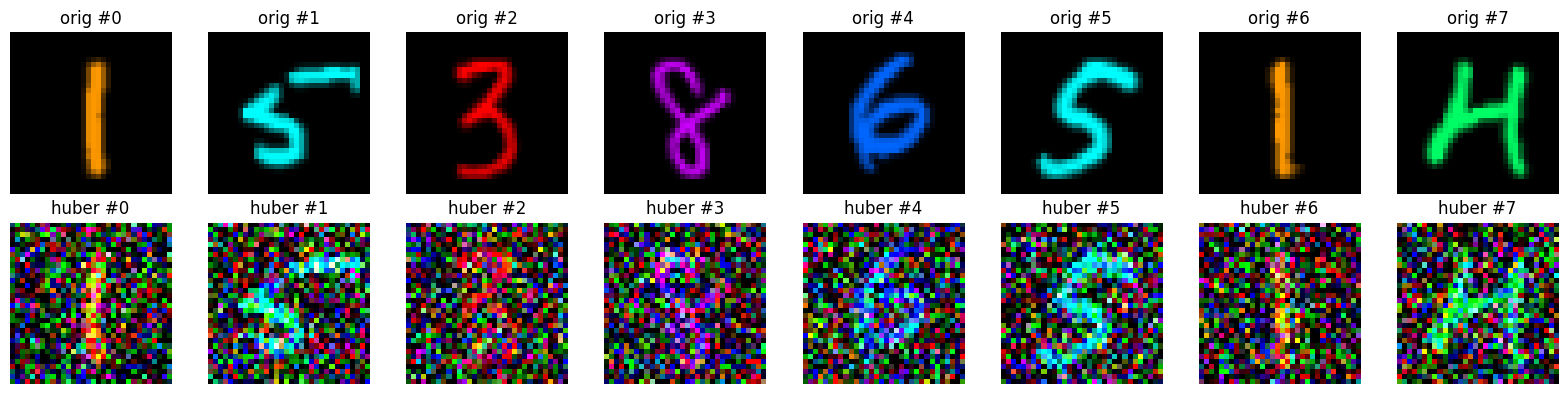

In [31]:
import torch
import matplotlib.pyplot as plt

# pick observational environment explicitly
iota_obs = "obs" if "obs" in Dll_samples else list(Dll_samples.keys())[0]
ll_images, _, ll_digits, ll_colors = Dll_samples[iota_obs]

# pick some indices
idx = torch.arange(16)  # first 16 examples
imgs = ll_images[idx]   # (16, C, H, W)

# flatten for Huber (pixels only)
imgs_flat = imgs.view(imgs.shape[0], -1)
d = imgs_flat.shape[1]

imgs_huber_flat = apply_huber_contamination_cmnist(
    imgs_flat,
    alpha=1.0,
    noise_scale=0.5,
    noise_dims=slice(0, d),   # contaminate ONLY pixels
    seed=0,
    loc=0.0
)

imgs_huber = imgs_huber_flat.view_as(imgs)  # back to (N,C,H,W)

# plot original vs huber
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 4))

for j in range(n_show):
    # original
    ax = axes[0, j]
    img = imgs[j].detach().cpu()
    if img.shape[0] == 1:
        ax.imshow(img.squeeze(0).clamp(0, 1), cmap="gray")
    else:
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    ax.set_title(f"orig #{j}")

    # huber
    ax = axes[1, j]
    img_h = imgs_huber[j].detach().cpu()
    if img_h.shape[0] == 1:
        ax.imshow(img_h.squeeze(0).clamp(0, 1), cmap="gray")
    else:
        ax.imshow(img_h.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    ax.set_title(f"huber #{j}")

plt.tight_layout()
plt.show()


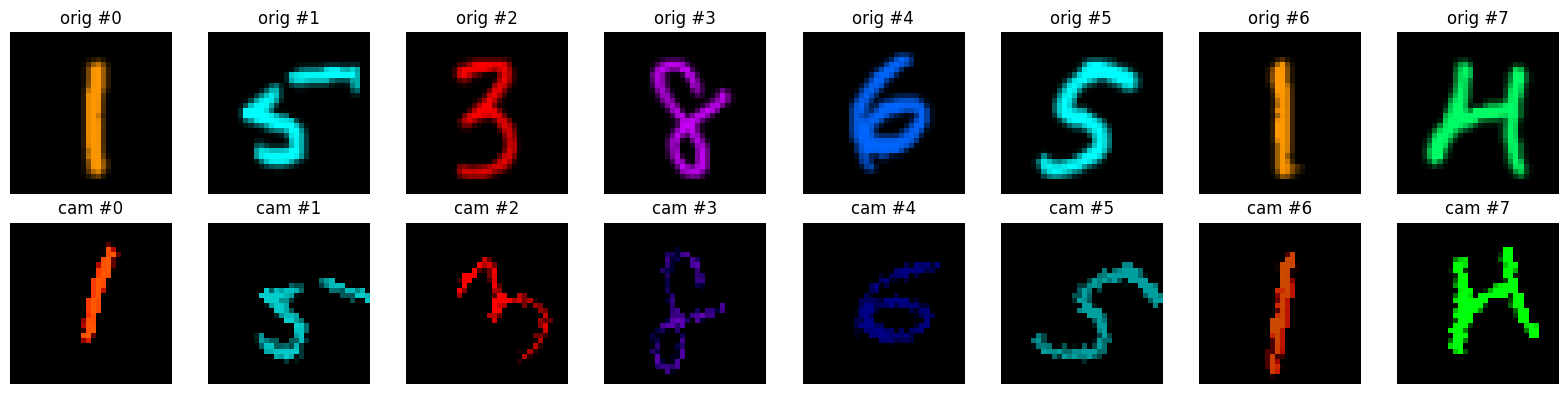

In [95]:
import matplotlib.pyplot as plt
import torch

# reuse same subset imgs = ll_images[idx] from previous cell
imgs_cam = apply_camera_shifts_cmnist(
    imgs,
    alpha=1.0,              # apply to all 16
    transform=camera_transform,
    seed=0
)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2*n_show, 4))

for j in range(n_show):
    # original
    ax = axes[0, j]
    img = imgs[j].detach().cpu()
    if img.shape[0] == 1:
        ax.imshow(img.squeeze(0).clamp(0, 1), cmap="gray")
    else:
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    ax.set_title(f"orig #{j}")

    # camera-shifted
    ax = axes[1, j]
    img_c = imgs_cam[j].detach().cpu()
    if img_c.shape[0] == 1:
        ax.imshow(img_c.squeeze(0).clamp(0, 1), cmap="gray")
    else:
        ax.imshow(img_c.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    ax.set_title(f"cam #{j}")

plt.tight_layout()
plt.show()


In [33]:
import torch
import pandas as pd
import numpy as np

records = []

# helper: coerce and slice to pixel->z block if needed
def extract_T_pix_to_z(T):
    """
    New setting expects T to be (d_z, 3072).
    If a full T (84, 3092) is passed, slice to z<-pixels part:
        rows 20: (z block), cols :3072 (pixels block).
    """
    T = T if isinstance(T, torch.Tensor) else torch.tensor(T, dtype=torch.float32)

    if T.ndim != 2:
        raise ValueError(f"T must be 2D, got shape {tuple(T.shape)}")

    # already pixel->z
    if T.shape[1] == 3072:
        return T

    # full old-style T (84,3092)
    if T.shape == (84, 3092):
        return T[20:, :3072]  # z rows, pixel cols

    # fallback: try to infer by matching pixel dim
    if T.shape[1] > 3072:
        return T[:, :3072]

    return T  # last resort

for method_group_key, folds in all_results.items():
    if not isinstance(folds, dict):
        continue

    for fold_key, fold_data in folds.items():
        if not fold_key.startswith("fold_"):
            continue
        if not isinstance(fold_data, dict) or "error" in fold_data:
            continue  # skip failed folds

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if not isinstance(run_result, dict):
                continue
            if "error" in run_result or run_result.get("T_matrix") is None:
                continue

            T_raw = run_result["T_matrix"]
            try:
                T = extract_T_pix_to_z(T_raw)
            except Exception as e:
                print(f"[skip] could not parse T for {method_group_key}/{fold_key}/{run_key}: {e}")
                continue

            # method name logic (same as eval)
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            # spectral & Frobenius norms on pixel->z map
            with torch.no_grad():
                fro_norm = torch.linalg.norm(T, ord='fro').item()
                try:
                    spec_norm = torch.linalg.norm(T, ord=2).item()
                except RuntimeError:
                    spec_norm = float("nan")

            # radii used in training (now stored at top-level)
            eps_train   = run_result.get("epsilon", np.nan)
            delta_train = run_result.get("delta", np.nan)

            records.append({
                "method_group": method_group_key,
                "run_key": run_key,
                "fold": fold_idx,
                "method": method_name,
                "T_shape": tuple(T.shape),
                "fro_norm": fro_norm,
                "spec_norm": spec_norm,
                "epsilon_train": float(eps_train) if eps_train is not None else np.nan,
                "delta_train": float(delta_train) if delta_train is not None else np.nan,
            })

norm_df = pd.DataFrame(records)

print("\n=== Per-run norms and training radii (first 50 rows) ===")
print(norm_df.head(50))

print("\n=== Aggregated by method (mean ± std) ===")
summary = norm_df.groupby("method")[["fro_norm", "spec_norm", "epsilon_train", "delta_train"]].agg(["mean", "std"])
print(summary)



=== Per-run norms and training radii (first 50 rows) ===
               method_group               run_key  fold  \
0  diroca_eps_0.5_delta_0.0     eps_0.5_delta_0.0     0   
1  diroca_eps_1.0_delta_0.0     eps_1.0_delta_0.0     0   
2  diroca_eps_2.0_delta_0.0     eps_2.0_delta_0.0     0   
3  diroca_eps_4.0_delta_0.0     eps_4.0_delta_0.0     0   
4  diroca_eps_8.0_delta_0.0     eps_8.0_delta_0.0     0   
5                    gradca            gradca_run     0   
6                    baryca            baryca_run     0   
7                 abslingam  Abs-LiNGAM (Perfect)     0   
8                 abslingam    Abs-LiNGAM (Noisy)     0   

                       method     T_shape    fro_norm   spec_norm  \
0  DiRoCA (eps_0.5_delta_0.0)  (64, 3072)   29.456884   10.618994   
1  DiRoCA (eps_1.0_delta_0.0)  (64, 3072)   23.619524   10.340919   
2  DiRoCA (eps_2.0_delta_0.0)  (64, 3072)   22.941946   12.404062   
3  DiRoCA (eps_4.0_delta_0.0)  (64, 3072)   28.496632   16.030350   
4  DiR

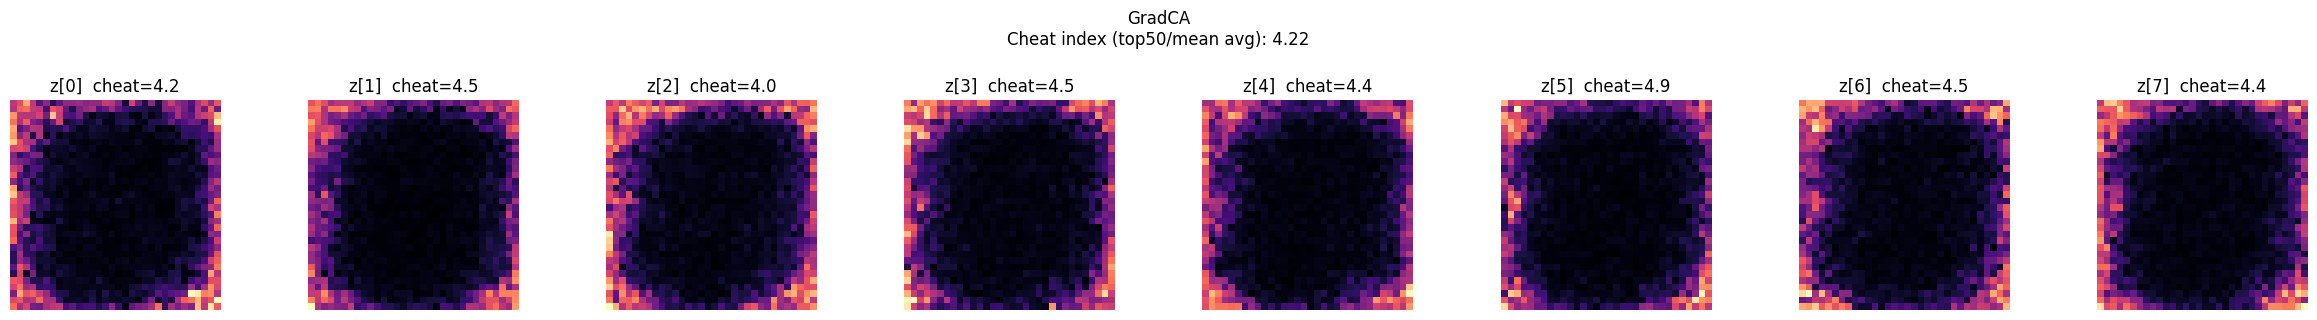

Cheat index: 4.223248481750488


In [34]:
# ================= Pixel-importance heatmaps + cheat index =================
import torch
import numpy as np
import matplotlib.pyplot as plt

def _as_tensor(x):
    return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)

def compute_pixel_importance(T_matrix, img_shape=(3, 32, 32)):
    """
    T_matrix: (z_dim, 3072) mapping pixels -> z
    Returns:
      imp_maps: (z_dim, H, W) per-z heatmaps based on sum over RGB |weights|
      cheat_index: scalar concentration score (higher = more 'cheaty'/sparse)
    """
    T = _as_tensor(T_matrix).detach().cpu()
    z_dim, d_ll = T.shape
    assert d_ll == np.prod(img_shape), f"Expected d_ll={np.prod(img_shape)}, got {d_ll}"

    C, H, W = img_shape
    T_img = T.view(z_dim, C, H, W)
    imp_maps = T_img.abs().sum(dim=1)  # (z_dim, H, W)

    # --- cheat index: top-k / mean concentration averaged over z ---
    flat = imp_maps.view(z_dim, -1)  # (z_dim, H*W)
    k = min(50, flat.shape[1])
    topk_mean = flat.topk(k, dim=1).values.mean(dim=1)
    all_mean = flat.mean(dim=1) + 1e-12
    cheat_per_z = (topk_mean / all_mean)
    cheat_index = cheat_per_z.mean().item()

    return imp_maps.numpy(), cheat_index, cheat_per_z.numpy()

def plot_importance_maps(T_matrix, title="", n_show=8):
    imp_maps, cheat_index, cheat_per_z = compute_pixel_importance(T_matrix)
    z_dim, H, W = imp_maps.shape
    n_show = min(n_show, z_dim)

    fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
    if n_show == 1:
        axes = [axes]

    for i in range(n_show):
        ax = axes[i]
        hm = imp_maps[i]
        vmax = np.max(hm) if np.max(hm) > 0 else 1.0
        ax.imshow(hm, cmap="magma", vmin=0.0, vmax=vmax)
        ax.set_title(f"z[{i}]  cheat={cheat_per_z[i]:.1f}")
        ax.axis("off")

    plt.suptitle(f"{title}\nCheat index (top50/mean avg): {cheat_index:.2f}", y=1.05)
    plt.tight_layout()
    plt.show()

    return cheat_index

# -------- Example usage --------
# Pick any learned T you want to inspect (shape (64,3072))
T_example = all_results['gradca']['fold_0']['gradca_run']['T_matrix']
cheat_val = plot_importance_maps(T_example, title="GradCA", n_show=8)
print("Cheat index:", cheat_val)


In [35]:
# ================= Semantic evaluation (interventional consistency) =================
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

def _as_tensor(x, device=None):
    t = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
    return t.to(device) if device is not None else t

@torch.no_grad()
def semantic_errors_pixels_to_z(
    T_matrix,
    det_ll_dict_opt,   # each (N, 3072) deterministic pixels only
    det_hl_dict_opt,   # each (N, 64) deterministic z only
    U_ll_hat_opt,      # (N, 3072) LL noise (test-time, maybe contaminated)
    U_hl_hat_opt,      # (N, 64)   HL noise (usually clean)
    omega,
    test_idx=None,     # optional index list/tensor for test split
    device=None,
):
    """
    Computes:
      e_{iota,eta}(T) = E || T (D_ll[iota]+U_ll) - (D_hl[eta]+U_hl) ||^2
    over all (iota, eta) in omega.

    Returns dict with per-pair errors plus:
      mean_iv_error, max_iv_error, var_iv_error
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    T = _as_tensor(T_matrix, device=device)
    U_ll = _as_tensor(U_ll_hat_opt, device=device)
    U_hl = _as_tensor(U_hl_hat_opt, device=device)

    if test_idx is not None:
        test_idx = torch.as_tensor(test_idx, dtype=torch.long, device=device)
        U_ll = U_ll.index_select(0, test_idx)
        U_hl = U_hl.index_select(0, test_idx)

    pair_errors = {}

    for iota, eta in omega.items():
        if iota not in det_ll_dict_opt or eta not in det_hl_dict_opt:
            continue

        Dll = _as_tensor(det_ll_dict_opt[iota], device=device)
        Dhl = _as_tensor(det_hl_dict_opt[eta], device=device)

        if test_idx is not None:
            Dll = Dll.index_select(0, test_idx)
            Dhl = Dhl.index_select(0, test_idx)

        # endo LL/HL (pixels->z setting)
        X_ll = Dll + U_ll           # (N_test, 3072)
        Z_hl = Dhl + U_hl           # (N_test, 64)

        Z_pred = X_ll @ T.T         # (N_test, 64)
        diff = Z_pred - Z_hl
        err = (diff.norm(p="fro")**2 / max(1, diff.shape[0])).item()

        pair_errors[(iota, eta)] = err

    errs = np.array(list(pair_errors.values()), dtype=np.float32)
    out = {
        "pair_errors": pair_errors,
        "mean_iv_error": float(np.mean(errs)) if len(errs) else np.nan,
        "max_iv_error": float(np.max(errs)) if len(errs) else np.nan,
        "var_iv_error": float(np.var(errs)) if len(errs) else np.nan,
    }
    return out


def run_semantic_eval_all_methods(
    all_results,
    det_ll_dict_opt, det_hl_dict_opt,
    U_ll_hat_opt, U_hl_hat_opt,
    omega
):
    """
    Drop-in evaluator over your all_results structure.
    Returns a DataFrame with mean/max/var interventional errors per run.
    """
    records = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for method_group_key, folds in all_results.items():
        if not isinstance(folds, dict):
            continue

        for fold_key, fold_data in folds.items():
            if not fold_key.startswith("fold_"):
                continue
            if not isinstance(fold_data, dict) or "error" in fold_data:
                continue
            fold_idx = int(fold_key.split("_")[-1])

            for run_key, run_result in fold_data.items():
                if not isinstance(run_result, dict) or "error" in run_result:
                    continue
                if run_result.get("T_matrix") is None:
                    continue

                T = run_result["T_matrix"]
                test_idx = run_result.get("test_indices", None)

                # match your naming conventions
                if method_group_key.startswith("diroca_"):
                    method_name = f"DiRoCA ({run_key})"
                elif method_group_key == "gradca":
                    method_name = "GradCA"
                elif method_group_key == "baryca":
                    method_name = "BaryCA"
                elif method_group_key == "abslingam":
                    method_name = run_key
                else:
                    method_name = f"{method_group_key}_{run_key}"

                sem = semantic_errors_pixels_to_z(
                    T, det_ll_dict_opt, det_hl_dict_opt,
                    U_ll_hat_opt, U_hl_hat_opt,
                    omega, test_idx=test_idx, device=device
                )

                records.append({
                    "method_group": method_group_key,
                    "run_key": run_key,
                    "fold": fold_idx,
                    "method": method_name,
                    "mean_iv_error": sem["mean_iv_error"],
                    "max_iv_error": sem["max_iv_error"],
                    "var_iv_error": sem["var_iv_error"],
                })

    return pd.DataFrame(records)

# -------- Example usage --------
sem_df = run_semantic_eval_all_methods(
    all_results,
    det_ll_dict_opt, det_hl_dict_opt,
    U_ll_hat_run, U_hl_hat_run,
    omega
)
print(sem_df.sort_values("mean_iv_error").head(20))
print(sem_df.groupby("method")[["mean_iv_error","max_iv_error","var_iv_error"]].agg(["mean","std"]))


               method_group               run_key  fold  \
0  diroca_eps_0.5_delta_0.0     eps_0.5_delta_0.0     0   
1  diroca_eps_1.0_delta_0.0     eps_1.0_delta_0.0     0   
2  diroca_eps_2.0_delta_0.0     eps_2.0_delta_0.0     0   
3  diroca_eps_4.0_delta_0.0     eps_4.0_delta_0.0     0   
5                    gradca            gradca_run     0   
4  diroca_eps_8.0_delta_0.0     eps_8.0_delta_0.0     0   
6                    baryca            baryca_run     0   
7                 abslingam  Abs-LiNGAM (Perfect)     0   
8                 abslingam    Abs-LiNGAM (Noisy)     0   

                       method  mean_iv_error  max_iv_error  var_iv_error  
0  DiRoCA (eps_0.5_delta_0.0)      81.318718    104.611374    235.746902  
1  DiRoCA (eps_1.0_delta_0.0)      84.013710    107.431198    239.385223  
2  DiRoCA (eps_2.0_delta_0.0)      87.898819    109.607697    202.292480  
3  DiRoCA (eps_4.0_delta_0.0)      97.290207    115.747032    148.275467  
5                      GradCA     

In [36]:
import torch
import pandas as pd
import numpy as np

records = []

for method_group_key, folds in all_results.items():
    if not isinstance(folds, dict):
        continue

    for fold_key, fold_data in folds.items():
        if not fold_key.startswith("fold_"):
            continue
        if not isinstance(fold_data, dict) or "error" in fold_data:
            continue  # skip failed folds

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if not isinstance(run_result, dict):
                continue
            if "error" in run_result or run_result.get("T_matrix") is None:
                continue

            T = run_result["T_matrix"]
            T = T if isinstance(T, torch.Tensor) else torch.tensor(T, dtype=torch.float32)

            # method name logic (same as in your eval)
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            # spectral & Frobenius norms
            with torch.no_grad():
                fro_norm = torch.linalg.norm(T, ord='fro').item()
                try:
                    spec_norm = torch.linalg.norm(T, ord=2).item()
                except RuntimeError:
                    # fallback if 2-norm fails for any reason
                    spec_norm = float("nan")

            # optimization params (to see actual eps/delta used)
            opt_params = run_result.get("optimization_params", {})
            eps_train  = opt_params.get("epsilon", np.nan)
            delta_train = opt_params.get("delta", np.nan)

            records.append({
                "method_group": method_group_key,
                "run_key": run_key,
                "fold": fold_idx,
                "method": method_name,
                "fro_norm": fro_norm,
                "spec_norm": spec_norm,
                "epsilon_train": float(eps_train),
                "delta_train": float(delta_train),
            })

norm_df = pd.DataFrame(records)

print("\n=== Per-run norms and training radii (first 50 rows) ===")
print(norm_df.head(50))

print("\n=== Aggregated by method (mean ± std) ===")
summary = norm_df.groupby("method")[["fro_norm", "spec_norm", "epsilon_train", "delta_train"]].agg(["mean", "std"])
print(summary)



=== Per-run norms and training radii (first 50 rows) ===
               method_group               run_key  fold  \
0  diroca_eps_0.5_delta_0.0     eps_0.5_delta_0.0     0   
1  diroca_eps_1.0_delta_0.0     eps_1.0_delta_0.0     0   
2  diroca_eps_2.0_delta_0.0     eps_2.0_delta_0.0     0   
3  diroca_eps_4.0_delta_0.0     eps_4.0_delta_0.0     0   
4  diroca_eps_8.0_delta_0.0     eps_8.0_delta_0.0     0   
5                    gradca            gradca_run     0   
6                    baryca            baryca_run     0   
7                 abslingam  Abs-LiNGAM (Perfect)     0   
8                 abslingam    Abs-LiNGAM (Noisy)     0   

                       method    fro_norm   spec_norm  epsilon_train  \
0  DiRoCA (eps_0.5_delta_0.0)   29.456884   10.618994            NaN   
1  DiRoCA (eps_1.0_delta_0.0)   23.619524   10.340919            NaN   
2  DiRoCA (eps_2.0_delta_0.0)   22.941946   12.404062            NaN   
3  DiRoCA (eps_4.0_delta_0.0)   28.496632   16.030350          

In [37]:
# ================== Cell 1: Core imports & helper functions ==================

import os
import gc
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn.functional as F
import torchvision.transforms as T

# -----------------------------------------------------------------------------
# Huber contamination (pixels only, CMNIST)
# -----------------------------------------------------------------------------
def apply_huber_contamination_cmnist(clean_data, alpha, noise_scale, noise_dims, seed=None, loc=0.0):
    """
    Contaminate ONLY the specified dimensions (columns) of clean_data with Gaussian noise.

    New setting reminder:
      - We call this ONLY on LL pixel blocks during evaluation.
      - Digit/Color one-hots are NEVER passed here and never contaminated.

    Args:
        clean_data : (N, D) tensor or array
        alpha      : fraction of samples to contaminate in [0,1]
        noise_scale: std of Gaussian noise
        noise_dims : slice / list / np.ndarray / torch.Tensor of column indices
        seed       : RNG seed
        loc        : mean shift of noise (0.0 = zero-mean)
    """
    # --- Early exit (numerically safe) ---
    if alpha is None or noise_scale is None or np.isclose(alpha, 0.0) or np.isclose(noise_scale, 0.0):
        if isinstance(clean_data, torch.Tensor):
            return clean_data.clone().to(torch.float32)
        return torch.tensor(clean_data, dtype=torch.float32)

    # --- Convert input to tensor ---
    if isinstance(clean_data, torch.Tensor):
        data_cont = clean_data.to(torch.float32).clone()
    else:
        data_cont = torch.tensor(clean_data, dtype=torch.float32).clone()
    device = data_cont.device
    N, D = data_cont.shape

    # --- Build index tensor for noise_dims ---
    if isinstance(noise_dims, slice):
        start = 0 if noise_dims.start is None else noise_dims.start
        stop  = D if noise_dims.stop is None else noise_dims.stop
        step  = 1 if noise_dims.step is None else noise_dims.step
        noise_idx = torch.arange(start, stop, step, device=device)
    elif isinstance(noise_dims, (list, tuple, np.ndarray, torch.Tensor)):
        noise_idx = torch.as_tensor(noise_dims, dtype=torch.long, device=device)
    else:
        raise TypeError(f"Unsupported type for noise_dims: {type(noise_dims)}")

    # --- Keep only valid indices ---
    noise_idx = noise_idx[(noise_idx >= 0) & (noise_idx < D)]
    if noise_idx.numel() == 0:
        return data_cont

    # --- Extract sub-matrix to contaminate ---
    data_to_noise = data_cont.index_select(dim=1, index=noise_idx)  # (N, |noise_idx|)

    # --- Sample Gaussian noise ---
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=loc, scale=noise_scale, size=tuple(data_to_noise.shape)).astype(np.float32)
    noise_tensor = torch.tensor(noise, dtype=torch.float32, device=device)

    noisy_slice = data_to_noise + noise_tensor

    # --- Full contamination ---
    if alpha >= 1.0:
        data_cont[:, noise_idx] = noisy_slice
        return data_cont

    # --- Partial contamination ---
    n_contaminate = int(alpha * N)
    if n_contaminate <= 0:
        return data_cont

    idx_to_contaminate_np = rng.choice(N, size=n_contaminate, replace=False)
    idx_to_contaminate = torch.as_tensor(idx_to_contaminate_np, dtype=torch.long, device=device)

    # Replace only selected rows and selected columns
    data_cont.index_copy_(
        dim=0,
        index=idx_to_contaminate,
        source=data_cont.index_select(0, idx_to_contaminate).scatter(
            1,
            noise_idx.view(1, -1).expand(n_contaminate, -1),
            noisy_slice.index_select(0, idx_to_contaminate)
        )
    )
    return data_cont

print("✅ apply_huber_contamination_cmnist ready (pixels-only eval usage).")


# -----------------------------------------------------------------------------
# Empirical abstraction error: pixels -> z, with optional labels
# -----------------------------------------------------------------------------
def calculate_empirical_error_flat(T_matrix, Dll_test_flat, Dhl_test):
    """
    Abstraction error (Frobenius MSE) in the NEW setting.

    NEW default:
      - T maps pixels -> z only.
      - LL labels (digit/color one-hots) are copied 1-1 to HL labels.
      - We evaluate against full HL vector [labels(20) | z(d_z)].

    Fallback:
      - If T is full (84 x 3092), use old full-linear evaluation.

    Args:
        T_matrix      : torch.Tensor or np.ndarray
                       Either (d_z, 3072) or (84, 3092)
        Dll_test_flat : (N, 3072) OR (N, 3092)  [pixels | LL labels]
        Dhl_test      : (N, 64)   OR (N, 84)    [HL labels | z]
    """
    try:
        # to tensors
        T_matrix = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        Dll_test_flat = Dll_test_flat if isinstance(Dll_test_flat, torch.Tensor) else torch.tensor(Dll_test_flat, dtype=torch.float32)
        Dhl_test = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T_matrix = T_matrix.to(device)
        Dll_test_flat = Dll_test_flat.to(device)
        Dhl_test = Dhl_test.to(device)

        N = Dll_test_flat.shape[0]

        # ============================================================
        # Case A (NEW): T is z-only: (d_z, 3072)
        # ============================================================
        if T_matrix.shape[1] == 3072:
            d_z = T_matrix.shape[0]

            # Dll may be pixels-only or pixels+labels
            if Dll_test_flat.shape[1] == 3072:
                ll_pixels = Dll_test_flat
                ll_labels = None
            elif Dll_test_flat.shape[1] == 3092:
                ll_pixels = Dll_test_flat[:, :3072]
                ll_labels = Dll_test_flat[:, 3072:]  # (N,20)
            else:
                return float("inf")

            # Dhl may be z-only or labels+z
            if Dhl_test.shape[1] == d_z:
                hl_labels = ll_labels  # if present, else None
                hl_z = Dhl_test
            elif Dhl_test.shape[1] == 20 + d_z:
                hl_labels = Dhl_test[:, :20]
                hl_z = Dhl_test[:, 20:]
            else:
                return float("inf")

            with torch.no_grad():
                z_pred = ll_pixels @ T_matrix.T  # (N, d_z)

                if hl_labels is None:
                    diff = z_pred - hl_z
                else:
                    pred_full = torch.cat([hl_labels, z_pred], dim=1)
                    true_full = torch.cat([hl_labels, hl_z], dim=1)
                    diff = pred_full - true_full

                err = torch.norm(diff, p="fro") ** 2 / max(1, N)
            return float(err.item())

        # ============================================================
        # Case B (OLD/FULL): T is full map (84, 3092)
        # ============================================================
        if T_matrix.shape[1] == Dll_test_flat.shape[1] and T_matrix.shape[0] == Dhl_test.shape[1]:
            with torch.no_grad():
                Dhl_pred = Dll_test_flat @ T_matrix.T
                diff = Dhl_pred - Dhl_test
                err = torch.norm(diff, p="fro") ** 2 / max(1, N)
            return float(err.item())

        # If nothing matched, shape mismatch
        return float("inf")

    except Exception as e:
        print(f"Error in calculate_empirical_error_flat: {e}")
        return float("inf")


# -----------------------------------------------------------------------------
# Camera / augmentation shifts (CMNIST)
# -----------------------------------------------------------------------------
def apply_camera_shifts_cmnist(images_01, alpha, transform, seed=None):
    """
    Apply a camera/augmentation transform to a fraction alpha of images.

    INPUT:
        images_01 : (N, C, H, W) tensor in [0,1]  (as stored in Dll_samples)
    OUTPUT:
        images_tanh_aug : (N, C, H, W) in tanh space [-1,1]
                          matching the optimization pipeline.
    """
    # alpha = 0 → no augmentation, but STILL convert to tanh
    if alpha <= 0.0:
        return images_01 * 2.0 - 1.0

    images_aug = images_01.clone()
    N = images_01.shape[0]
    rng = np.random.default_rng(seed)
    n_aug = int(alpha * N)

    if n_aug == 0:
        return images_01 * 2.0 - 1.0

    idx_all = np.arange(N)
    idx_aug = rng.choice(idx_all, size=n_aug, replace=False)

    for j in idx_aug:
        # torchvision transforms expect input in [0,1]
        images_aug[j] = transform(images_aug[j])

    images_tanh_aug = images_aug * 2.0 - 1.0
    return images_tanh_aug


camera_transform = T.Compose([
    T.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
])
print("✅ camera_transform & apply_camera_shifts_cmnist ready.")


# -----------------------------------------------------------------------------
# Semantic / IV evaluation helpers (pixels -> z)
# -----------------------------------------------------------------------------
def _as_tensor_sem(x, device=None):
    t = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
    return t.to(device) if device is not None else t


@torch.no_grad()
def semantic_errors_pixels_to_z(
    T_matrix,
    det_ll_dict_opt,   # each (N, 3072) deterministic pixels only
    det_hl_dict_opt,   # each (N, 64) deterministic z only
    U_ll_hat_opt,      # (N, 3072) LL noise (test-time, maybe contaminated)
    U_hl_hat_opt,      # (N, 64)   HL noise (usually clean)
    omega,
    test_idx=None,     # optional index list/tensor for test split
    device=None,
):
    """
    Computes:
      e_{iota,eta}(T) = E || T (D_ll[iota]+U_ll) - (D_hl[eta]+U_hl) ||^2
    over all (iota, eta) in omega.

    Returns dict with per-pair errors plus:
      mean_iv_error, max_iv_error, var_iv_error
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    T = _as_tensor_sem(T_matrix, device=device)
    U_ll = _as_tensor_sem(U_ll_hat_opt, device=device)
    U_hl = _as_tensor_sem(U_hl_hat_opt, device=device)

    if test_idx is not None:
        test_idx = torch.as_tensor(test_idx, dtype=torch.long, device=device)
        U_ll = U_ll.index_select(0, test_idx)
        U_hl = U_hl.index_select(0, test_idx)

    pair_errors = {}

    for iota, eta in omega.items():
        if iota not in det_ll_dict_opt or eta not in det_hl_dict_opt:
            continue

        Dll = _as_tensor_sem(det_ll_dict_opt[iota], device=device)
        Dhl = _as_tensor_sem(det_hl_dict_opt[eta], device=device)

        if test_idx is not None:
            Dll = Dll.index_select(0, test_idx)
            Dhl = Dhl.index_select(0, test_idx)

        X_ll = Dll + U_ll           # (N_test, 3072)
        Z_hl = Dhl + U_hl           # (N_test, 64)

        Z_pred = X_ll @ T.T         # (N_test, 64)
        diff = Z_pred - Z_hl
        err = (diff.norm(p="fro")**2 / max(1, diff.shape[0])).item()

        pair_errors[(iota, eta)] = err

    errs = np.array(list(pair_errors.values()), dtype=np.float32)
    out = {
        "pair_errors": pair_errors,
        "mean_iv_error": float(np.mean(errs)) if len(errs) else np.nan,
        "max_iv_error": float(np.max(errs)) if len(errs) else np.nan,
        "var_iv_error": float(np.var(errs)) if len(errs) else np.nan,
    }
    return out


def run_semantic_eval_all_methods(
    all_results,
    det_ll_dict_opt, det_hl_dict_opt,
    U_ll_hat_opt, U_hl_hat_opt,
    omega
):
    """
    Evaluator over all_results structure.
    Returns a DataFrame with mean/max/var interventional errors per run.
    """
    records = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for method_group_key, folds in all_results.items():
        if not isinstance(folds, dict):
            continue

        for fold_key, fold_data in folds.items():
            if not fold_key.startswith("fold_"):
                continue
            if not isinstance(fold_data, dict) or "error" in fold_data:
                continue
            fold_idx = int(fold_key.split("_")[-1])

            for run_key, run_result in fold_data.items():
                if not isinstance(run_result, dict) or "error" in run_result:
                    continue
                if run_result.get("T_matrix") is None:
                    continue

                T = run_result["T_matrix"]
                test_idx = run_result.get("test_indices", None)

                # match naming conventions
                if method_group_key.startswith("diroca_"):
                    method_name = f"DiRoCA ({run_key})"
                elif method_group_key == "gradca":
                    method_name = "GradCA"
                elif method_group_key == "baryca":
                    method_name = "BaryCA"
                elif method_group_key == "abslingam":
                    method_name = run_key
                else:
                    method_name = f"{method_group_key}_{run_key}"

                sem = semantic_errors_pixels_to_z(
                    T, det_ll_dict_opt, det_hl_dict_opt,
                    U_ll_hat_opt, U_hl_hat_opt,
                    omega, test_idx=test_idx, device=device
                )

                records.append({
                    "method_group": method_group_key,
                    "run_key": run_key,
                    "fold": fold_idx,
                    "method": method_name,
                    "mean_iv_error": sem["mean_iv_error"],
                    "max_iv_error": sem["max_iv_error"],
                    "var_iv_error": sem["var_iv_error"],
                })

    return pd.DataFrame(records)


# -----------------------------------------------------------------------------
# Helper for norms / condition numbers: extract pixel->z block
# -----------------------------------------------------------------------------
def extract_T_pix_to_z(T):
    """
    New setting expects T to be (d_z, 3072).
    If a full T (84, 3092) is passed, slice to z<-pixels part:
        rows 20: (z block), cols :3072 (pixels block).
    """
    T = T if isinstance(T, torch.Tensor) else torch.tensor(T, dtype=torch.float32)

    if T.ndim != 2:
        raise ValueError(f"T must be 2D, got shape {tuple(T.shape)}")

    # already pixel->z
    if T.shape[1] == 3072:
        return T

    # full old-style T (84,3092)
    if T.shape == (84, 3092):
        return T[20:, :3072]  # z rows, pixel cols

    # fallback: try to infer by matching pixel dim
    if T.shape[1] > 3072:
        return T[:, :3072]

    return T  # last resort


print("✅ Helper functions for IV, Huber, Camera & T extraction ready.")


✅ apply_huber_contamination_cmnist ready (pixels-only eval usage).
✅ camera_transform & apply_camera_shifts_cmnist ready.
✅ Helper functions for IV, Huber, Camera & T extraction ready.


In [38]:
# ================== Cell 2: Run IV / semantic evaluation ==================

# Assumes these exist in your notebook:
#   all_results,
#   det_ll_dict_opt, det_hl_dict_opt,
#   U_ll_hat_run (or U_ll_hat_opt),
#   U_hl_hat_run (or U_hl_hat_opt),
#   omega

sem_df = run_semantic_eval_all_methods(
    all_results,
    det_ll_dict_opt, det_hl_dict_opt,
    U_ll_hat_run, U_hl_hat_run,
    omega
)

print("\n=== Per-run semantic (IV) errors, sorted by mean_iv_error ===")
print(sem_df.sort_values("mean_iv_error").head(50))

print("\n=== Aggregated IV errors by method (mean ± std) ===")
summary_iv = sem_df.groupby("method")[["mean_iv_error", "max_iv_error", "var_iv_error"]].agg(["mean", "std"])
print(summary_iv)



=== Per-run semantic (IV) errors, sorted by mean_iv_error ===
               method_group               run_key  fold  \
0  diroca_eps_0.5_delta_0.0     eps_0.5_delta_0.0     0   
1  diroca_eps_1.0_delta_0.0     eps_1.0_delta_0.0     0   
2  diroca_eps_2.0_delta_0.0     eps_2.0_delta_0.0     0   
3  diroca_eps_4.0_delta_0.0     eps_4.0_delta_0.0     0   
5                    gradca            gradca_run     0   
4  diroca_eps_8.0_delta_0.0     eps_8.0_delta_0.0     0   
6                    baryca            baryca_run     0   
7                 abslingam  Abs-LiNGAM (Perfect)     0   
8                 abslingam    Abs-LiNGAM (Noisy)     0   

                       method  mean_iv_error  max_iv_error  var_iv_error  
0  DiRoCA (eps_0.5_delta_0.0)      81.318718    104.611374    235.746902  
1  DiRoCA (eps_1.0_delta_0.0)      84.013710    107.431198    239.385223  
2  DiRoCA (eps_2.0_delta_0.0)      87.898819    109.607697    202.292480  
3  DiRoCA (eps_4.0_delta_0.0)      97.290207  

In [39]:
# ================== Cell 3: Run Huber evaluation (alpha=0,1) ==================

# Assumed globals:
#   all_results, Dll_samples, Dhl_samples, omega
#   cv_folds (only for counting folds if you want, but not strictly needed)

if 'output_dir' not in locals():
    output_dir = 'data/cmnist/results_empirical'
os.makedirs(output_dir, exist_ok=True)

print("\n--- Starting Evaluation: Clean & Huber-Noise (Cases 1 & 2) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5   # noise level for alpha=1
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # 0 -> clean, 1 -> fully noisy

evaluation_records = []

# Count total methods to set progress bar
total_methods_trained = 0
for method_group_key, method_data_inner in all_results.items():
    if isinstance(method_data_inner, dict):
        for fold_key, fold_data in method_data_inner.items():
            if isinstance(fold_data, dict) and 'error' not in fold_data:
                total_methods_trained += len(fold_data)

total_configs = total_methods_trained * len(ALPHA_VALUES_TO_TEST) * N_TRIALS

if total_configs == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_eval = tqdm(total=total_configs, desc="Evaluating (clean + huber)")

    LL_PIXEL_DIMS = slice(0, 3072)  # flattened RGB pixels

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                # Human-readable method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                for alpha in ALPHA_VALUES_TO_TEST:
                    noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                    loc_ll = 0.0  # label-preserving pixel noise (mean 0)

                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images_01, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images_01):
                                    continue

                                # --- Test split ---
                                ll_images_test_01 = ll_images_01[test_idx]      # (N_test,3,32,32) in [0,1]
                                ll_digits_test    = ll_digits[test_idx]
                                ll_colors_test    = ll_colors[test_idx]
                                Dhl_test_clean    = Dhl_samples[eta][test_idx]  # (N_test,84) clean HL

                                seed = hash((fold_idx, run_key, float(alpha),
                                             float(noise_scale), trial, str(iota))) % (2**32)

                                # Rescale pixels to tanh space [-1,1]
                                ll_images_test_tanh = ll_images_test_01 * 2.0 - 1.0

                                # flatten images and contaminate only pixels
                                ll_images_test_flat = ll_images_test_tanh.view(ll_images_test_tanh.shape[0], -1)
                                ll_images_cont_flat = apply_huber_contamination_cmnist(
                                    ll_images_test_flat, alpha, noise_scale,
                                    noise_dims=LL_PIXEL_DIMS, seed=seed, loc=loc_ll
                                )

                                # one-hot digits & colors (never contaminated)
                                ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                                ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()

                                device = ll_images_cont_flat.device
                                Dll_test_cont_flat_full = torch.cat(
                                    [ll_images_cont_flat,
                                     ll_digits_onehot.to(device),
                                     ll_colors_onehot.to(device)],
                                    dim=1
                                )  # (N_test, 3092)

                                # High-level stays clean (labels + z)
                                Dhl_test = Dhl_test_clean.to(device)

                                error = calculate_empirical_error_flat(
                                    T_matrix, Dll_test_cont_flat_full, Dhl_test
                                )
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)

                            except Exception as e:
                                print(f"ERROR inner loop: {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha}, N{noise_scale}, "
                                      f"T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'huber_noise',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha),
                            'noise_scale': float(noise_scale),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta']   = run_result.get('delta', np.nan)

                        evaluation_records.append(record)
                        pbar_eval.update(1)

                        # cleanup
                        del (ll_images_test_01, ll_images_test_tanh, ll_digits_test, ll_colors_test,
                             Dhl_test_clean, ll_images_test_flat, ll_images_cont_flat,
                             ll_digits_onehot, ll_colors_onehot, Dll_test_cont_flat_full)
                        if 'error' in locals():
                            del error
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors
                        gc.collect()

    pbar_eval.close()

    full_results_df = pd.DataFrame(evaluation_records)
    eval_output_path = os.path.join(output_dir, "cmnist_eval_clean_and_huber.pkl")
    full_results_df.to_pickle(eval_output_path)
    print(f"\nHuber evaluation results saved to {eval_output_path}")

    # --------- Summary: alpha=0 vs alpha=1 ----------
    df_huber_clean = full_results_df[
        (full_results_df['shift_type'] == 'huber_noise') &
        (full_results_df['alpha'].abs() < 1e-8)
    ]
    df_huber_shift = full_results_df[
        (full_results_df['shift_type'] == 'huber_noise') &
        (full_results_df['alpha'].round(3) == 1.0)
    ]

    summary_huber_clean = (
        df_huber_clean.groupby('method')['error']
        .agg(['mean', 'std'])
        .sort_values('mean')
    )
    summary_huber_shift = (
        df_huber_shift.groupby('method')['error']
        .agg(['mean', 'std'])
        .sort_values('mean')
    )

    print("\n================ HUBER NOISE EVALUATION SUMMARY ================\n")

    print("--- Huber: Clean (alpha = 0) ---")
    if len(summary_huber_clean) == 0:
        print("No clean (alpha=0) results found.")
    else:
        print(summary_huber_clean)

    print("\n--- Huber: Fully Noisy (alpha = 1) ---")
    if len(summary_huber_shift) == 0:
        print("No shifted (alpha=1) results found.")
    else:
        print(summary_huber_shift)

    print("\n===============================================================\n")



--- Starting Evaluation: Clean & Huber-Noise (Cases 1 & 2) ---


Evaluating (clean + huber): 100%|██████████| 90/90 [01:00<00:00,  1.48it/s]


Huber evaluation results saved to data/cmnist/results_empirical/cmnist_eval_clean_and_huber.pkl

================ HUBER NOISE EVALUATION SUMMARY ================

--- Huber: Clean (alpha = 0) ---
                                    mean  std
method                                       
DiRoCA (eps_8.0_delta_0.0)  5.260559e+03  0.0
DiRoCA (eps_2.0_delta_0.0)  7.165741e+03  0.0
DiRoCA (eps_4.0_delta_0.0)  7.269567e+03  0.0
DiRoCA (eps_1.0_delta_0.0)  8.512775e+03  0.0
DiRoCA (eps_0.5_delta_0.0)  1.399889e+04  0.0
Abs-LiNGAM (Noisy)          2.450986e+04  0.0
Abs-LiNGAM (Perfect)        3.479977e+05  0.0
BaryCA                      1.032708e+07  0.0
GradCA                      1.908431e+07  0.0

--- Huber: Fully Noisy (alpha = 1) ---
                                    mean           std
method                                                
DiRoCA (eps_8.0_delta_0.0)  5.599133e+03     12.228932
DiRoCA (eps_2.0_delta_0.0)  7.294019e+03     11.827321
DiRoCA (eps_4.0_delta_0.0)  7.469212e

In [40]:
# ================== Cell 4: Run Camera-shift evaluation (alpha=0,1) ==================

print("\n--- Starting Evaluation: Camera/Augmentation Shifts (Case 3) ---")

N_TRIALS = 5
ALPHA_VALUES_CAMERA = [0.0, 1.0]  # 0 -> clean, 1 -> all images augmented

eval_records_camera = []

if total_methods_trained == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_cam = tqdm(
        total=total_methods_trained * len(ALPHA_VALUES_CAMERA) * N_TRIALS,
        desc="Evaluating (camera shifts)"
    )

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                # Human-readable method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                # Determine which "view" this T corresponds to
                if isinstance(T_matrix, torch.Tensor):
                    T_shape = tuple(T_matrix.shape)
                else:
                    T_shape = tuple(np.asarray(T_matrix).shape)

                is_opt_view  = (T_shape == (64, 3072))
                is_full_view = (T_shape == (84, 3092))

                if not (is_opt_view or is_full_view):
                    print(f"[Warning] Unexpected T shape {T_shape} for {eval_method_name}. Skipping.")
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                for alpha_cam in ALPHA_VALUES_CAMERA:
                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images):
                                    continue

                                # LL images are in [0,1]
                                ll_images_test = ll_images[test_idx]          # (N,C,H,W) in [0,1]
                                ll_digits_test = ll_digits[test_idx]
                                ll_colors_test = ll_colors[test_idx]

                                # HL full vector, but we only want z-block
                                Dhl_test_full = Dhl_samples[eta][test_idx]   # (N,84)
                                Dhl_test_z    = Dhl_test_full[:, 20:]        # (N,64)

                                seed = hash((fold_idx, run_key, float(alpha_cam),
                                             trial, str(iota))) % (2**32)

                                # apply camera shifts in [0,1] and convert to tanh
                                ll_images_shifted_tanh = apply_camera_shifts_cmnist(
                                    ll_images_test, alpha_cam, camera_transform, seed=seed
                                )  # (N,C,H,W) in [-1,1]

                                # flatten pixels only (tanh space)
                                ll_pixels_shifted_flat = ll_images_shifted_tanh.view(
                                    ll_images_shifted_tanh.shape[0], -1
                                )  # (N,3072)

                                device = ll_pixels_shifted_flat.device

                                # Build LL input and T block depending on view
                                if is_opt_view:
                                    Dll_input = ll_pixels_shifted_flat        # (N,3072)
                                    T_use     = T_matrix                      # (64,3072)
                                    Dhl_target = Dhl_test_z.to(device)        # (N,64)
                                else:
                                    # full-view T: slice z<-pixels block
                                    if not isinstance(T_matrix, torch.Tensor):
                                        T_matrix = torch.tensor(T_matrix, dtype=torch.float32)
                                    T_use = T_matrix[20:, :3072]             # (64,3072)

                                    Dll_input  = ll_pixels_shifted_flat      # (N,3072)
                                    Dhl_target = Dhl_test_z.to(device)       # (N,64)

                                # Compute error on z only
                                error = calculate_empirical_error_flat(
                                    T_use, Dll_input, Dhl_target
                                )
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)

                            except Exception as e:
                                print(f"ERROR (camera) inner loop: {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha_cam}, T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'camera_aug',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha_cam),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta']   = run_result.get('delta', np.nan)

                        eval_records_camera.append(record)
                        pbar_cam.update(1)

                        # cleanup
                        del (ll_images_test, ll_digits_test, ll_colors_test,
                             Dhl_test_full, Dhl_test_z,
                             ll_images_shifted_tanh, ll_pixels_shifted_flat)
                        if 'error' in locals():
                            del error
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors
                        gc.collect()

    pbar_cam.close()

    df_cam = pd.DataFrame(eval_records_camera)
    cam_output_path = os.path.join(output_dir, "cmnist_eval_camera_shifts.pkl")
    df_cam.to_pickle(cam_output_path)
    print(f"\nCamera-shift evaluation results saved to {cam_output_path}")

    # === SUMMARY: CAMERA SHIFT RESULTS ===

    df_cam_clean = df_cam[
        (df_cam['shift_type'] == 'camera_aug') &
        (df_cam['alpha'].abs() < 1e-8)
    ]

    df_cam_shift = df_cam[
        (df_cam['shift_type'] == 'camera_aug') &
        (df_cam['alpha'].round(3) == 1.0)
    ]

    summary_cam_clean = (
        df_cam_clean.groupby('method')['error']
        .agg(['mean', 'std'])
        .sort_values('mean')
    )

    summary_cam_shift = (
        df_cam_shift.groupby('method')['error']
        .agg(['mean', 'std'])
        .sort_values('mean')
    )

    print("\n================ CAMERA SHIFT EVALUATION SUMMARY ================\n")

    print("--- Camera: Clean (alpha = 0) ---")
    if len(summary_cam_clean) == 0:
        print("No clean (alpha=0) results found.")
    else:
        print(summary_cam_clean)

    print("\n--- Camera: Fully Shifted (alpha = 1) ---")
    if len(summary_cam_shift) == 0:
        print("No shifted (alpha=1) results found.")
    else:
        print(summary_cam_shift)

    print("\n===============================================================\n")



--- Starting Evaluation: Camera/Augmentation Shifts (Case 3) ---


Evaluating (camera shifts): 100%|██████████| 90/90 [04:57<00:00,  3.30s/it]


Camera-shift evaluation results saved to data/cmnist/results_empirical/cmnist_eval_camera_shifts.pkl

================ CAMERA SHIFT EVALUATION SUMMARY ================

--- Camera: Clean (alpha = 0) ---
                                    mean  std
method                                       
DiRoCA (eps_8.0_delta_0.0)  5.260559e+03  0.0
DiRoCA (eps_2.0_delta_0.0)  7.165742e+03  0.0
DiRoCA (eps_4.0_delta_0.0)  7.269567e+03  0.0
DiRoCA (eps_1.0_delta_0.0)  8.512774e+03  0.0
DiRoCA (eps_0.5_delta_0.0)  1.399889e+04  0.0
Abs-LiNGAM (Noisy)          2.450986e+04  0.0
Abs-LiNGAM (Perfect)        3.479978e+05  0.0
BaryCA                      1.032708e+07  0.0
GradCA                      1.908432e+07  0.0

--- Camera: Fully Shifted (alpha = 1) ---
                                    mean          std
method                                               
DiRoCA (eps_8.0_delta_0.0)  5.412395e+03    11.317334
DiRoCA (eps_4.0_delta_0.0)  7.392653e+03    13.391780
DiRoCA (eps_2.0_delta_0.0)  7.4

In [41]:
# ================== Cell 5: Condition numbers for each T ==================

cond_records = []

for method_group_key, folds in all_results.items():
    if not isinstance(folds, dict):
        continue

    for fold_key, fold_data in folds.items():
        if not fold_key.startswith("fold_"):
            continue
        if not isinstance(fold_data, dict) or "error" in fold_data:
            continue  # skip failed folds

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if not isinstance(run_result, dict):
                continue
            if "error" in run_result or run_result.get("T_matrix") is None:
                continue

            T_raw = run_result["T_matrix"]
            try:
                T = extract_T_pix_to_z(T_raw)  # (d_z, 3072)
            except Exception as e:
                print(f"[skip] could not parse T for {method_group_key}/{fold_key}/{run_key}: {e}")
                continue

            # method name logic (same as eval)
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            T = T.detach().cpu()
            with torch.no_grad():
                # Frobenius norm
                fro_norm = torch.linalg.norm(T, ord='fro').item()

                # Spectral norm (largest singular value)
                try:
                    spec_norm = torch.linalg.norm(T, ord=2).item()
                except RuntimeError:
                    spec_norm = float("nan")

                # Condition number via SVD: sigma_max / sigma_min
                try:
                    svals = torch.linalg.svdvals(T)
                    sigma_max = float(svals.max().item())
                    sigma_min = float(svals.min().item())
                    cond_number = sigma_max / max(sigma_min, 1e-12)
                except RuntimeError:
                    cond_number = float("nan")

            eps_train   = run_result.get("epsilon", np.nan)
            delta_train = run_result.get("delta", np.nan)

            cond_records.append({
                "method_group": method_group_key,
                "run_key": run_key,
                "fold": fold_idx,
                "method": method_name,
                "T_shape": tuple(T.shape),
                "fro_norm": fro_norm,
                "spec_norm": spec_norm,
                "cond_number": cond_number,
                "epsilon_train": float(eps_train) if eps_train is not None else np.nan,
                "delta_train": float(delta_train) if delta_train is not None else np.nan,
            })

cond_df = pd.DataFrame(cond_records)

print("\n=== Per-run norms and condition numbers (first 50 rows) ===")
print(cond_df.head(50))

print("\n=== Aggregated by method (mean ± std) ===")
summary_cond = cond_df.groupby("method")[["fro_norm", "spec_norm", "cond_number",
                                          "epsilon_train", "delta_train"]].agg(["mean", "std"])
print(summary_cond)



=== Per-run norms and condition numbers (first 50 rows) ===
               method_group               run_key  fold  \
0  diroca_eps_0.5_delta_0.0     eps_0.5_delta_0.0     0   
1  diroca_eps_1.0_delta_0.0     eps_1.0_delta_0.0     0   
2  diroca_eps_2.0_delta_0.0     eps_2.0_delta_0.0     0   
3  diroca_eps_4.0_delta_0.0     eps_4.0_delta_0.0     0   
4  diroca_eps_8.0_delta_0.0     eps_8.0_delta_0.0     0   
5                    gradca            gradca_run     0   
6                    baryca            baryca_run     0   
7                 abslingam  Abs-LiNGAM (Perfect)     0   
8                 abslingam    Abs-LiNGAM (Noisy)     0   

                       method     T_shape    fro_norm   spec_norm  \
0  DiRoCA (eps_0.5_delta_0.0)  (64, 3072)   29.456884   10.618994   
1  DiRoCA (eps_1.0_delta_0.0)  (64, 3072)   23.619524   10.340919   
2  DiRoCA (eps_2.0_delta_0.0)  (64, 3072)   22.941946   12.404062   
3  DiRoCA (eps_4.0_delta_0.0)  (64, 3072)   28.496632   16.030350   
4  

In [42]:
import os
import gc
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn.functional as F
import torchvision.transforms as T


In [43]:
def row_mse(z_pred, z_true):
    """
    Per-row MSE on z:
        (1/N) * sum_i || z_pred[i] - z_true[i] ||^2

    No division by dimension; error is average squared L2 norm per sample.
    """
    if not isinstance(z_pred, torch.Tensor):
        z_pred = torch.tensor(z_pred, dtype=torch.float32)
    if not isinstance(z_true, torch.Tensor):
        z_true = torch.tensor(z_true, dtype=torch.float32)

    z_pred = z_pred.to(torch.float32)
    z_true = z_true.to(torch.float32)

    assert z_pred.shape == z_true.shape, f"Shape mismatch: {z_pred.shape} vs {z_true.shape}"
    N = z_pred.shape[0]
    if N == 0:
        return float('nan')

    diff = z_pred - z_true
    # Frobenius^2 / N = mean over rows of squared L2 norm
    return (diff.pow(2).sum() / N).item()


In [44]:
def calculate_empirical_error_flat_row_mse(T_matrix, Dll_test_flat, Dhl_test):
    """
    Per-row MSE on z for CMNIST.

    Supported cases:
      - T: (64, 3072)         pixels -> z
      - T: (84, 3092) (full)  [pixels | labels] -> [labels | z]  (we slice z<-pixels)

    Dll_test_flat:
      - (N, 3072)            pixels only
      - (N, 3092)            [pixels | one-hot digit | one-hot color]

    Dhl_test:
      - (N, 64)              z only
      - (N, 84)              [HL labels(20) | z(64)]
    """
    try:
        # to tensors
        T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        X = Dll_test_flat if isinstance(Dll_test_flat, torch.Tensor) else torch.tensor(Dll_test_flat, dtype=torch.float32)
        Y = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T = T.to(device)
        X = X.to(device)
        Y = Y.to(device)

        # ==========================
        # Case A: T is (d_z, 3072)
        # ==========================
        if T.shape[1] == 3072:
            d_z = T.shape[0]

            # X: pixels or pixels+labels
            if X.shape[1] == 3072:
                ll_pixels = X
            elif X.shape[1] == 3092:
                ll_pixels = X[:, :3072]
            else:
                return float('nan')

            # Y: z or labels+z
            if Y.shape[1] == d_z:
                hl_z = Y
            elif Y.shape[1] == 20 + d_z:
                hl_z = Y[:, 20:]
            else:
                return float('nan')

            with torch.no_grad():
                z_pred = ll_pixels @ T.T   # (N, d_z)
            return row_mse(z_pred, hl_z)

        # ==========================
        # Case B: full T (84,3092)
        # ==========================
        if T.shape == (84, 3092) and Y.shape[1] == 84:
            with torch.no_grad():
                # z <- pixels block
                T_pix_to_z = T[20:, :3072]    # (64,3072)
                if X.shape[1] == 3092:
                    ll_pixels = X[:, :3072]
                else:
                    ll_pixels = X
                z_pred = ll_pixels @ T_pix_to_z.T
                hl_z = Y[:, 20:]
            return row_mse(z_pred, hl_z)

        # unsupported shape combo
        return float('nan')

    except Exception as e:
        print(f"Error in calculate_empirical_error_flat_row_mse: {e}")
        return float('nan')


In [45]:
def apply_huber_contamination_cmnist(clean_data, alpha, noise_scale, noise_dims, seed=None, loc=0.0):
    """
    Contaminate ONLY specified dimensions (columns) of clean_data with Gaussian noise.

    clean_data : (N,D) tensor or array, values already in tanh space [-1,1].
    alpha      : fraction of samples to contaminate in [0,1]
    noise_scale: std of Gaussian noise
    noise_dims : slice / list / np.ndarray / torch.Tensor of column indices
    loc        : mean of noise
    """
    if not isinstance(clean_data, torch.Tensor):
        data_cont = torch.tensor(clean_data, dtype=torch.float32).clone()
    else:
        data_cont = clean_data.clone().to(torch.float32)

    import numpy as _np

    # Early exit
    if alpha is None or noise_scale is None or _np.isclose(alpha, 0.0) or _np.isclose(noise_scale, 0.0):
        return data_cont

    device = data_cont.device
    N, D = data_cont.shape

    # build index tensor
    if isinstance(noise_dims, slice):
        start = 0 if noise_dims.start is None else noise_dims.start
        stop  = D if noise_dims.stop is None else noise_dims.stop
        step  = 1 if noise_dims.step is None else noise_dims.step
        noise_idx = torch.arange(start, stop, step, device=device)
    elif isinstance(noise_dims, (list, tuple, np.ndarray, torch.Tensor)):
        noise_idx = torch.as_tensor(noise_dims, dtype=torch.long, device=device)
    else:
        raise TypeError(f"Unsupported type for noise_dims: {type(noise_dims)}")

    # keep valid indices only
    noise_idx = noise_idx[(noise_idx >= 0) & (noise_idx < D)]
    if noise_idx.numel() == 0:
        return data_cont

    data_to_noise = data_cont.index_select(dim=1, index=noise_idx)  # (N, |noise_idx|)

    rng = _np.random.default_rng(seed)
    noise = rng.normal(loc=loc, scale=noise_scale, size=tuple(data_to_noise.shape)).astype(_np.float32)
    noise_tensor = torch.tensor(noise, dtype=torch.float32, device=device)

    noisy_slice = data_to_noise + noise_tensor

    # full contamination
    if alpha >= 1.0:
        data_cont[:, noise_idx] = noisy_slice
        return data_cont

    # partial contamination
    n_contaminate = int(alpha * N)
    if n_contaminate <= 0:
        return data_cont

    idx_to_contaminate_np = rng.choice(N, size=n_contaminate, replace=False)
    idx_to_contaminate = torch.as_tensor(idx_to_contaminate_np, dtype=torch.long, device=device)

    data_cont.index_copy_(
        dim=0,
        index=idx_to_contaminate,
        source=data_cont.index_select(0, idx_to_contaminate).scatter(
            1,
            noise_idx.view(1, -1).expand(n_contaminate, -1),
            noisy_slice.index_select(0, idx_to_contaminate)
        )
    )
    return data_cont


In [46]:
# === Huber evaluation (alpha = 0 and 1) with per-row MSE on z ===

if 'output_dir' not in locals():
    output_dir = 'data/cmnist/results_empirical'
os.makedirs(output_dir, exist_ok=True)

print("\n--- Starting Evaluation: Clean & Huber-Noise (per-row MSE on z) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5    # noise level for alpha=1
ALPHA_VALUES_TO_TEST = [0.0, 1.0]

evaluation_records_huber = []

# Count total methods
total_methods_trained = 0
for method_group_key, method_data_inner in all_results.items():
    if isinstance(method_data_inner, dict):
        for fold_key, fold_data in method_data_inner.items():
            if isinstance(fold_data, dict) and 'error' not in fold_data:
                total_methods_trained += len(fold_data)

total_configs = total_methods_trained * len(ALPHA_VALUES_TO_TEST) * N_TRIALS
print(f"Total Huber configs: {total_configs}")

if total_configs == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_eval = tqdm(total=total_configs, desc="Evaluating (clean + huber, row-MSE)")

    LL_PIXEL_DIMS = slice(0, 3072)  # flattened RGB pixels

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                # human-readable method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                for alpha in ALPHA_VALUES_TO_TEST:
                    noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                    loc_ll = 0.0

                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images_01, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images_01):
                                    continue

                                # test split
                                ll_images_test_01 = ll_images_01[test_idx]      # (N_test,3,32,32) in [0,1]
                                ll_digits_test    = ll_digits[test_idx]
                                ll_colors_test    = ll_colors[test_idx]
                                Dhl_test_clean    = Dhl_samples[eta][test_idx]  # (N_test,84) clean HL

                                seed = hash((fold_idx, run_key, float(alpha),
                                             float(noise_scale), trial, str(iota))) % (2**32)

                                # rescale [0,1] -> [-1,1]
                                ll_images_test_tanh = ll_images_test_01 * 2.0 - 1.0

                                # flatten images and contaminate only pixels
                                ll_images_test_flat = ll_images_test_tanh.view(ll_images_test_tanh.shape[0], -1)
                                ll_images_cont_flat = apply_huber_contamination_cmnist(
                                    ll_images_test_flat, alpha, noise_scale,
                                    noise_dims=LL_PIXEL_DIMS, seed=seed, loc=loc_ll
                                )

                                # one-hot digits & colors (never contaminated)
                                ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                                ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()

                                device = ll_images_cont_flat.device
                                Dll_test_cont_flat_full = torch.cat(
                                    [ll_images_cont_flat,
                                     ll_digits_onehot.to(device),
                                     ll_colors_onehot.to(device)],
                                    dim=1
                                )  # (N_test, 3092)

                                # HL stays clean (labels + z)
                                Dhl_test = torch.as_tensor(Dhl_test_clean, dtype=torch.float32, device=device)

                                error = calculate_empirical_error_flat_row_mse(
                                    T_matrix, Dll_test_cont_flat_full, Dhl_test
                                )
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)

                            except Exception as e:
                                print(f"[Huber ERROR] {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha}, N{noise_scale}, "
                                      f"T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'huber_noise_row_mse',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha),
                            'noise_scale': float(noise_scale),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta']   = run_result.get('delta', np.nan)

                        evaluation_records_huber.append(record)
                        pbar_eval.update(1)

                        # cleanup
                        del (ll_images_test_01, ll_images_test_tanh, ll_digits_test, ll_colors_test,
                             Dhl_test_clean, ll_images_test_flat, ll_images_cont_flat,
                             ll_digits_onehot, ll_colors_onehot, Dll_test_cont_flat_full)
                        if 'error' in locals():
                            del error
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors

    pbar_eval.close()

    df_huber = pd.DataFrame(evaluation_records_huber)
    eval_output_path = os.path.join(output_dir, "cmnist_eval_clean_and_huber_rowmse.pkl")
    df_huber.to_pickle(eval_output_path)
    print(f"\nHuber evaluation (row-MSE on z) saved to {eval_output_path}")

    # summary
    df_huber_clean = df_huber[np.isclose(df_huber['alpha'], 0.0)]
    df_huber_full  = df_huber[np.isclose(df_huber['alpha'], 1.0)]

    summary_huber_clean = df_huber_clean.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
    summary_huber_full  = df_huber_full.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')

    print("\n================ HUBER NOISE (ROW-MSE ON Z) SUMMARY ================\n")
    print("--- Huber: Clean (alpha = 0) ---")
    print(summary_huber_clean if len(summary_huber_clean) else "No results.")
    print("\n--- Huber: Fully Noisy (alpha = 1) ---")
    print(summary_huber_full if len(summary_huber_full) else "No results.")
    print("\n====================================================================\n")



--- Starting Evaluation: Clean & Huber-Noise (per-row MSE on z) ---
Total Huber configs: 90


Evaluating (clean + huber, row-MSE): 100%|██████████| 90/90 [00:38<00:00,  2.35it/s]


Huber evaluation (row-MSE on z) saved to data/cmnist/results_empirical/cmnist_eval_clean_and_huber_rowmse.pkl

================ HUBER NOISE (ROW-MSE ON Z) SUMMARY ================

--- Huber: Clean (alpha = 0) ---
                                    mean  std
method                                       
DiRoCA (eps_8.0_delta_0.0)  5.260559e+03  0.0
DiRoCA (eps_2.0_delta_0.0)  7.165742e+03  0.0
DiRoCA (eps_4.0_delta_0.0)  7.269567e+03  0.0
DiRoCA (eps_1.0_delta_0.0)  8.512774e+03  0.0
DiRoCA (eps_0.5_delta_0.0)  1.399889e+04  0.0
Abs-LiNGAM (Noisy)          2.450987e+04  0.0
Abs-LiNGAM (Perfect)        3.479978e+05  0.0
BaryCA                      1.032708e+07  0.0
GradCA                      1.908431e+07  0.0

--- Huber: Fully Noisy (alpha = 1) ---
                                    mean           std
method                                                
DiRoCA (eps_8.0_delta_0.0)  5.599133e+03     12.229065
DiRoCA (eps_2.0_delta_0.0)  7.294019e+03     11.827527
DiRoCA (eps_4.0_del

In [47]:
def apply_camera_shifts_cmnist(images_01, alpha, transform, seed=None):
    """
    Apply camera/augmentation transform to a fraction alpha of images.

    Input:
        images_01 : (N, C, H, W) in [0,1]
    Output:
        images_tanh_aug : (N, C, H, W) in [-1,1]
    """
    import numpy as _np

    if alpha <= 0.0:
        return images_01 * 2.0 - 1.0

    images_aug = images_01.clone()
    N = images_01.shape[0]
    rng = _np.random.default_rng(seed)
    n_aug = int(alpha * N)

    if n_aug == 0:
        return images_01 * 2.0 - 1.0

    idx_all = _np.arange(N)
    idx_aug = rng.choice(idx_all, size=n_aug, replace=False)

    for j in idx_aug:
        images_aug[j] = transform(images_aug[j])

    images_tanh_aug = images_aug * 2.0 - 1.0
    return images_tanh_aug


In [48]:
camera_transform = T.Compose([
    T.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
])

print("\n--- Starting Evaluation: Camera/Augmentation Shifts (per-row MSE on z) ---")

N_TRIALS = 5
ALPHA_VALUES_CAMERA = [0.0, 1.0]

eval_records_camera = []

if total_methods_trained == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_cam = tqdm(
        total=total_methods_trained * len(ALPHA_VALUES_CAMERA) * N_TRIALS,
        desc="Evaluating (camera shifts, row-MSE)"
    )

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                # pretty method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                # check view type
                T_arr = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix)
                T_shape = tuple(T_arr.shape)
                is_opt_view  = (T_shape == (64, 3072))
                is_full_view = (T_shape == (84, 3092))

                if not (is_opt_view or is_full_view):
                    print(f"[Warning] Unexpected T shape {T_shape} for {eval_method_name}. Skipping camera eval.")
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS)
                    continue

                for alpha_cam in ALPHA_VALUES_CAMERA:
                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images):
                                    continue

                                # LL in [0,1]
                                ll_images_test = ll_images[test_idx]
                                ll_digits_test = ll_digits[test_idx]
                                ll_colors_test = ll_colors[test_idx]

                                # HL full: [labels(20) | z(64)]
                                Dhl_test_full = Dhl_samples[eta][test_idx]
                                Dhl_test_z    = Dhl_test_full[:, 20:]  # (N,64)

                                seed = hash((fold_idx, run_key, float(alpha_cam),
                                             trial, str(iota))) % (2**32)

                                # apply camera shifts and convert to tanh
                                ll_images_shifted_tanh = apply_camera_shifts_cmnist(
                                    ll_images_test, alpha_cam, camera_transform, seed=seed
                                )
                                ll_pixels_shifted_flat = ll_images_shifted_tanh.view(
                                    ll_images_shifted_tanh.shape[0], -1
                                )
                                device = ll_pixels_shifted_flat.device

                                # depending on T-view, build inputs
                                if is_opt_view:
                                    Dll_input = ll_pixels_shifted_flat        # (N,3072)
                                    T_use     = T_arr.to(device)              # (64,3072)
                                    Dhl_target = torch.as_tensor(Dhl_test_z, dtype=torch.float32, device=device)
                                else:
                                    T_tensor = T_arr.to(device)
                                    T_use    = T_tensor[20:, :3072]           # (64,3072)
                                    Dll_input  = ll_pixels_shifted_flat       # (N,3072)
                                    Dhl_target = torch.as_tensor(Dhl_test_z, dtype=torch.float32, device=device)

                                error = calculate_empirical_error_flat_row_mse(
                                    T_use, Dll_input, Dhl_target
                                )
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)

                            except Exception as e:
                                print(f"[Camera ERROR] {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha_cam}, T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'camera_aug_row_mse',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha_cam),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta']   = run_result.get('delta', np.nan)

                        eval_records_camera.append(record)
                        pbar_cam.update(1)

                        # cleanup
                        del (ll_images_test, ll_digits_test, ll_colors_test,
                             Dhl_test_full, Dhl_test_z,
                             ll_images_shifted_tanh, ll_pixels_shifted_flat)
                        if 'error' in locals():
                            del error
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors

    pbar_cam.close()

    df_cam = pd.DataFrame(eval_records_camera)
    cam_output_path = os.path.join(output_dir, "cmnist_eval_camera_shifts_rowmse.pkl")
    df_cam.to_pickle(cam_output_path)
    print(f"\nCamera-shift evaluation (row-MSE on z) saved to {cam_output_path}")

    # === SUMMARY ===
    df_cam_clean = df_cam[np.isclose(df_cam['alpha'], 0.0)]
    df_cam_shift = df_cam[np.isclose(df_cam['alpha'], 1.0)]

    summary_cam_clean = df_cam_clean.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')
    summary_cam_shift = df_cam_shift.groupby('method')['error'].agg(['mean', 'std']).sort_values('mean')

    print("\n================ CAMERA SHIFT (ROW-MSE ON Z) SUMMARY ================\n")
    print("--- Camera: Clean (alpha = 0) ---")
    print(summary_cam_clean if len(summary_cam_clean) else "No results.")
    print("\n--- Camera: Fully Shifted (alpha = 1) ---")
    print(summary_cam_shift if len(summary_cam_shift) else "No results.")
    print("\n=====================================================================\n")



--- Starting Evaluation: Camera/Augmentation Shifts (per-row MSE on z) ---


Evaluating (camera shifts, row-MSE): 100%|██████████| 90/90 [05:22<00:00,  3.59s/it]


Camera-shift evaluation (row-MSE on z) saved to data/cmnist/results_empirical/cmnist_eval_camera_shifts_rowmse.pkl

================ CAMERA SHIFT (ROW-MSE ON Z) SUMMARY ================

--- Camera: Clean (alpha = 0) ---
                                    mean  std
method                                       
DiRoCA (eps_8.0_delta_0.0)  5.260559e+03  0.0
DiRoCA (eps_2.0_delta_0.0)  7.165742e+03  0.0
DiRoCA (eps_4.0_delta_0.0)  7.269567e+03  0.0
DiRoCA (eps_1.0_delta_0.0)  8.512774e+03  0.0
DiRoCA (eps_0.5_delta_0.0)  1.399889e+04  0.0
Abs-LiNGAM (Noisy)          2.450987e+04  0.0
Abs-LiNGAM (Perfect)        3.479978e+05  0.0
BaryCA                      1.032708e+07  0.0
GradCA                      1.908431e+07  0.0

--- Camera: Fully Shifted (alpha = 1) ---
                                    mean          std
method                                               
DiRoCA (eps_8.0_delta_0.0)  5.408518e+03    16.640053
DiRoCA (eps_4.0_delta_0.0)  7.398730e+03     7.407812
DiRoCA (eps_2

In [49]:
def _as_tensor_iv(x, device=None):
    t = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
    return t.to(device) if device is not None else t


In [50]:
@torch.no_grad()
def semantic_errors_pixels_to_z(
    T_matrix,
    det_ll_dict_opt,   # each (N, 3072) deterministic pixels only
    det_hl_dict_opt,   # each (N, 64) deterministic z only
    U_ll_hat_opt,      # (N, 3072) LL noise (test-time)
    U_hl_hat_opt,      # (N, 64)   HL noise (usually clean)
    omega,
    test_idx=None,     # optional test indices
    device=None,
):
    """
    e_{iota,eta}(T) = (1/N) * sum_i || T (D_ll[iota]+U_ll)[i] - (D_hl[eta]+U_hl)[i] ||^2

    i.e. per-row MSE on z.
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    T = _as_tensor_iv(T_matrix, device=device)
    U_ll = _as_tensor_iv(U_ll_hat_opt, device=device)
    U_hl = _as_tensor_iv(U_hl_hat_opt, device=device)

    if test_idx is not None:
        test_idx = torch.as_tensor(test_idx, dtype=torch.long, device=device)
        U_ll = U_ll.index_select(0, test_idx)
        U_hl = U_hl.index_select(0, test_idx)

    pair_errors = {}

    for iota, eta in omega.items():
        if iota not in det_ll_dict_opt or eta not in det_hl_dict_opt:
            continue

        Dll = _as_tensor_iv(det_ll_dict_opt[iota], device=device)
        Dhl = _as_tensor_iv(det_hl_dict_opt[eta], device=device)

        if test_idx is not None:
            Dll = Dll.index_select(0, test_idx)
            Dhl = Dhl.index_select(0, test_idx)

        X_ll = Dll + U_ll           # (N_test, 3072)
        Z_hl = Dhl + U_hl           # (N_test, 64)

        Z_pred = X_ll @ T.T         # (N_test, 64)
        diff = Z_pred - Z_hl
        err = (diff.norm(p="fro")**2 / max(1, diff.shape[0])).item()  # per-row MSE
        pair_errors[(iota, eta)] = err

    errs = np.array(list(pair_errors.values()), dtype=np.float32)
    out = {
        "pair_errors": pair_errors,
        "mean_iv_error": float(np.mean(errs)) if len(errs) else np.nan,
        "max_iv_error": float(np.max(errs)) if len(errs) else np.nan,
        "var_iv_error": float(np.var(errs)) if len(errs) else np.nan,
    }
    return out


In [51]:
def run_semantic_eval_all_methods(
    all_results,
    det_ll_dict_opt, det_hl_dict_opt,
    U_ll_hat_opt, U_hl_hat_opt,
    omega
):
    """
    Interventional (semantic) evaluation using per-row MSE on z.
    """
    records = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for method_group_key, folds in all_results.items():
        if not isinstance(folds, dict):
            continue

        for fold_key, fold_data in folds.items():
            if not fold_key.startswith("fold_"):
                continue
            if not isinstance(fold_data, dict) or "error" in fold_data:
                continue
            fold_idx = int(fold_key.split("_")[-1])

            for run_key, run_result in fold_data.items():
                if not isinstance(run_result, dict) or "error" in run_result:
                    continue
                if run_result.get("T_matrix") is None:
                    continue

                T = run_result["T_matrix"]
                test_idx = run_result.get("test_indices", None)

                # naming
                if method_group_key.startswith("diroca_"):
                    method_name = f"DiRoCA ({run_key})"
                elif method_group_key == "gradca":
                    method_name = "GradCA"
                elif method_group_key == "baryca":
                    method_name = "BaryCA"
                elif method_group_key == "abslingam":
                    method_name = run_key
                else:
                    method_name = f"{method_group_key}_{run_key}"

                sem = semantic_errors_pixels_to_z(
                    T, det_ll_dict_opt, det_hl_dict_opt,
                    U_ll_hat_opt, U_hl_hat_opt,
                    omega, test_idx=test_idx, device=device
                )

                records.append({
                    "method_group": method_group_key,
                    "run_key": run_key,
                    "fold": fold_idx,
                    "method": method_name,
                    "mean_iv_error": sem["mean_iv_error"],
                    "max_iv_error": sem["max_iv_error"],
                    "var_iv_error": sem["var_iv_error"],
                })

    return pd.DataFrame(records)


In [52]:
records_norms = []

def extract_T_pix_to_z(T):
    """
    Return pixel->z block as (64, 3072).

    If T is already (64, 3072), return as is.
    If T is full (84, 3092), slice rows 20: (z) and cols :3072 (pixels).
    Fallback: if cols > 3072, take first 3072.
    """
    T = T if isinstance(T, torch.Tensor) else torch.tensor(T, dtype=torch.float32)

    if T.ndim != 2:
        raise ValueError(f"T must be 2D, got shape {tuple(T.shape)}")

    if T.shape[1] == 3072:
        return T

    if T.shape == (84, 3092):
        return T[20:, :3072]

    if T.shape[1] > 3072:
        return T[:, :3072]

    return T  # last resort


In [53]:
for method_group_key, folds in all_results.items():
    if not isinstance(folds, dict):
        continue

    for fold_key, fold_data in folds.items():
        if not fold_key.startswith("fold_"):
            continue
        if not isinstance(fold_data, dict) or "error" in fold_data:
            continue  # skip failed folds

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if not isinstance(run_result, dict):
                continue
            if "error" in run_result or run_result.get("T_matrix") is None:
                continue

            T_raw = run_result["T_matrix"]
            try:
                T = extract_T_pix_to_z(T_raw)
            except Exception as e:
                print(f"[skip] could not parse T for {method_group_key}/{fold_key}/{run_key}: {e}")
                continue

            # method name (same convention)
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            with torch.no_grad():
                fro_norm = torch.linalg.norm(T, ord='fro').item()
                try:
                    spec_norm = torch.linalg.norm(T, ord=2).item()
                except RuntimeError:
                    spec_norm = float("nan")

                # condition number via SVD
                try:
                    s = torch.linalg.svdvals(T)
                    s_max = s.max().item()
                    s_min = s.min().item()
                    if s_min <= 0:
                        cond_number = np.inf
                    else:
                        cond_number = float(s_max / s_min)
                except RuntimeError:
                    cond_number = float("nan")

            eps_train   = run_result.get("epsilon", np.nan)
            delta_train = run_result.get("delta", np.nan)

            records_norms.append({
                "method_group": method_group_key,
                "run_key": run_key,
                "fold": fold_idx,
                "method": method_name,
                "T_shape": tuple(T.shape),
                "fro_norm": fro_norm,
                "spec_norm": spec_norm,
                "cond_number": cond_number,
                "epsilon_train": float(eps_train) if eps_train is not None else np.nan,
                "delta_train": float(delta_train) if delta_train is not None else np.nan,
            })

norm_df = pd.DataFrame(records_norms)

print("\n=== Per-run norms and condition numbers (first 50 rows) ===")
print(norm_df.head(50))

print("\n=== Aggregated by method (mean ± std) ===")
summary_norms = norm_df.groupby("method")[["fro_norm", "spec_norm", "cond_number", "epsilon_train", "delta_train"]].agg(["mean", "std"])
print(summary_norms)



=== Per-run norms and condition numbers (first 50 rows) ===
               method_group               run_key  fold  \
0  diroca_eps_0.5_delta_0.0     eps_0.5_delta_0.0     0   
1  diroca_eps_1.0_delta_0.0     eps_1.0_delta_0.0     0   
2  diroca_eps_2.0_delta_0.0     eps_2.0_delta_0.0     0   
3  diroca_eps_4.0_delta_0.0     eps_4.0_delta_0.0     0   
4  diroca_eps_8.0_delta_0.0     eps_8.0_delta_0.0     0   
5                    gradca            gradca_run     0   
6                    baryca            baryca_run     0   
7                 abslingam  Abs-LiNGAM (Perfect)     0   
8                 abslingam    Abs-LiNGAM (Noisy)     0   

                       method     T_shape    fro_norm   spec_norm  \
0  DiRoCA (eps_0.5_delta_0.0)  (64, 3072)   29.456884   10.618994   
1  DiRoCA (eps_1.0_delta_0.0)  (64, 3072)   23.619524   10.340919   
2  DiRoCA (eps_2.0_delta_0.0)  (64, 3072)   22.941946   12.404062   
3  DiRoCA (eps_4.0_delta_0.0)  (64, 3072)   28.496632   16.030350   
4  

In [60]:
import torch
import numpy as np

def row_cosine_distance(z_pred, z_true, eps=1e-8):
    """
    Per-row cosine *distance* on z:

        cos_sim_i = <z_pred[i], z_true[i]> / (||z_pred[i]|| * ||z_true[i]|| + eps)
        cos_sim   = mean_i cos_sim_i
        cos_dist  = 1 - cos_sim

    Returns a scalar (float). Lower is better, 0 is perfect.
    """
    if not isinstance(z_pred, torch.Tensor):
        z_pred = torch.tensor(z_pred, dtype=torch.float32)
    if not isinstance(z_true, torch.Tensor):
        z_true = torch.tensor(z_true, dtype=torch.float32)

    z_pred = z_pred.to(torch.float32)
    z_true = z_true.to(torch.float32)

    assert z_pred.shape == z_true.shape, f"Shape mismatch: {z_pred.shape} vs {z_true.shape}"
    N = z_pred.shape[0]
    if N == 0:
        return float("nan")

    # normalise per row
    z_pred_norm = z_pred / (z_pred.norm(dim=1, keepdim=True) + eps)
    z_true_norm = z_true / (z_true.norm(dim=1, keepdim=True) + eps)

    cos_sim = (z_pred_norm * z_true_norm).sum(dim=1).mean()  # average over rows
    cos_dist = 1.0 - cos_sim
    return float(cos_dist.item())


def calculate_empirical_error_flat_row_cosine(T_matrix, Dll_test_flat, Dhl_test):
    """
    Cosine-distance-on-z version of the flat evaluation.

    Supported cases:
      - T: (d_z, 3072)         pixels -> z
      - T: (84, 3092) (full)  [pixels | labels] -> [labels | z] (we slice z<-pixels)

    Dll_test_flat:
      - (N, 3072)            pixels only
      - (N, 3092)            [pixels | one-hot digit | one-hot color]

    Dhl_test:
      - (N, 64)              z only
      - (N, 84)              [HL labels(20) | z(64)]
    """
    try:
        T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        X = Dll_test_flat if isinstance(Dll_test_flat, torch.Tensor) else torch.tensor(Dll_test_flat, dtype=torch.float32)
        Y = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T = T.to(device)
        X = X.to(device)
        Y = Y.to(device)

        # ==========================
        # Case A: T is (d_z, 3072)
        # ==========================
        if T.shape[1] == 3072:
            d_z = T.shape[0]

            # X: pixels or pixels+labels
            if X.shape[1] == 3072:
                ll_pixels = X
            elif X.shape[1] == 3092:
                ll_pixels = X[:, :3072]
            else:
                return float("nan")

            # Y: z or labels+z
            if Y.shape[1] == d_z:
                hl_z = Y
            elif Y.shape[1] == 20 + d_z:
                hl_z = Y[:, 20:]
            else:
                return float("nan")

            with torch.no_grad():
                z_pred = ll_pixels @ T.T   # (N, d_z)
            return row_cosine_distance(z_pred, hl_z)

        # ==========================
        # Case B: full T (84,3092)
        # ==========================
        if T.shape == (84, 3092) and Y.shape[1] == 84:
            with torch.no_grad():
                # z <- pixels block
                T_pix_to_z = T[20:, :3072]    # (64,3072)
                if X.shape[1] == 3092:
                    ll_pixels = X[:, :3072]
                else:
                    ll_pixels = X
                z_pred = ll_pixels @ T_pix_to_z.T
                hl_z = Y[:, 20:]
            return row_cosine_distance(z_pred, hl_z)

        return float("nan")

    except Exception as e:
        print(f"Error in calculate_empirical_error_flat_row_cosine: {e}")
        return float("nan")


print("✅ Cosine helpers defined (row_cosine_distance + calculate_empirical_error_flat_row_cosine).")


✅ Cosine helpers defined (row_cosine_distance + calculate_empirical_error_flat_row_cosine).


In [61]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc

# Assumes: cv_folds, omega, Dll_samples, Dhl_samples, all_results exist

if 'output_dir' not in locals():
    output_dir = 'data/cmnist/results_empirical'
os.makedirs(output_dir, exist_ok=True)

print("\n--- Starting Evaluation (COSINE): Clean & Huber-Noise ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5   # noise level for alpha=1
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # 0 -> clean, 1 -> fully noisy

evaluation_records_cos = []

# Count total configs for progress bar
total_methods_trained = 0
for method_group_key, method_data_inner in all_results.items():
    if isinstance(method_data_inner, dict):
        for fold_key, fold_data in method_data_inner.items():
            if isinstance(fold_data, dict) and 'error' not in fold_data:
                total_methods_trained += len(fold_data)

total_configs_cos = total_methods_trained * len(ALPHA_VALUES_TO_TEST) * N_TRIALS

if total_configs_cos == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_eval = tqdm(total=total_configs_cos, desc="Evaluating (clean + huber, cosine)")

    LL_PIXEL_DIMS = slice(0, 3072)  # flattened RGB pixels

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue

                # Human-readable method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                for alpha in ALPHA_VALUES_TO_TEST:
                    noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                    loc_ll = 0.0  # label-preserving pixel noise (mean 0)

                    for trial in range(N_TRIALS):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images_01, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images_01):
                                    continue

                                # --- Test split ---
                                ll_images_test_01 = ll_images_01[test_idx]      # (N_test,3,32,32) in [0,1]
                                ll_digits_test    = ll_digits[test_idx]
                                ll_colors_test    = ll_colors[test_idx]
                                Dhl_test_clean    = Dhl_samples[eta][test_idx]  # (N_test,84) clean HL

                                seed = hash((fold_idx, run_key, float(alpha),
                                             float(noise_scale), trial, str(iota))) % (2**32)

                                # rescale pixels to tanh space [-1,1]
                                ll_images_test_tanh = ll_images_test_01 * 2.0 - 1.0  # [0,1] -> [-1,1]

                                # flatten images and contaminate only pixels
                                ll_images_test_flat = ll_images_test_tanh.view(ll_images_test_tanh.shape[0], -1)
                                ll_images_cont_flat = apply_huber_contamination_cmnist(
                                    ll_images_test_flat, alpha, noise_scale,
                                    noise_dims=LL_PIXEL_DIMS, seed=seed, loc=loc_ll
                                )

                                # one-hot digits & colors (never contaminated)
                                ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                                ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()

                                device = ll_images_cont_flat.device
                                Dll_test_cont_flat_full = torch.cat(
                                    [ll_images_cont_flat,
                                     ll_digits_onehot.to(device),
                                     ll_colors_onehot.to(device)],
                                    dim=1
                                )  # (N_test, 3092)

                                # High-level stays clean (labels + z)
                                Dhl_test = Dhl_test_clean.to(device)

                                error_cos = calculate_empirical_error_flat_row_cosine(
                                    T_matrix, Dll_test_cont_flat_full, Dhl_test
                                )
                                if not np.isnan(error_cos) and error_cos != float('inf'):
                                    trial_errors.append(error_cos)

                            except Exception as e:
                                print(f"[Huber COS ERROR] {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha}, N{noise_scale}, "
                                      f"T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'huber_noise',
                            'metric': 'cosine',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha),
                            'noise_scale': float(noise_scale),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta']   = run_result.get('delta', np.nan)

                        evaluation_records_cos.append(record)
                        pbar_eval.update(1)

                        # cleanup
                        del (ll_images_test_01, ll_images_test_tanh, ll_digits_test, ll_colors_test,
                             Dhl_test_clean, ll_images_test_flat, ll_images_cont_flat,
                             ll_digits_onehot, ll_colors_onehot, Dll_test_cont_flat_full)
                        if 'error_cos' in locals():
                            del error_cos
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors

    pbar_eval.close()

    df_huber_cos = pd.DataFrame(evaluation_records_cos)
    eval_output_path_cos = os.path.join(output_dir, "cmnist_eval_clean_and_huber_cosine.pkl")
    df_huber_cos.to_pickle(eval_output_path_cos)
    print(f"\n✅ Huber (cosine) evaluation results saved to {eval_output_path_cos}")



--- Starting Evaluation (COSINE): Clean & Huber-Noise ---


Evaluating (clean + huber, cosine): 100%|██████████| 90/90 [00:33<00:00,  2.72it/s]


✅ Huber (cosine) evaluation results saved to data/cmnist/results_empirical/cmnist_eval_clean_and_huber_cosine.pkl


In [62]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

print("\n--- Starting Evaluation (COSINE): Camera/Augmentation Shifts ---")

N_TRIALS_CAMERA = 5
ALPHA_VALUES_CAMERA = [0.0, 1.0]  # 0 -> clean, 1 -> all images augmented

eval_records_camera_cos = []

if total_methods_trained == 0:
    print("Error: No valid training results found in 'all_results'.")
else:
    pbar_cam = tqdm(
        total=total_methods_trained * len(ALPHA_VALUES_CAMERA) * N_TRIALS_CAMERA,
        desc="Evaluating (camera shifts, cosine)"
    )

    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict):
            continue

        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'):
                continue
            if 'error' in fold_data:
                continue

            fold_idx = int(fold_key.split('_')[-1])

            for run_key, run_result in fold_data.items():
                if 'error' in run_result or run_result.get('T_matrix') is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS_CAMERA)
                    continue

                T_matrix = run_result['T_matrix']
                test_idx = run_result['test_indices']
                if test_idx is None:
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS_CAMERA)
                    continue

                # Human-readable method name
                if method_group_key.startswith('diroca_'):
                    eval_method_name = f"DiRoCA ({run_key})"
                elif method_group_key == 'gradca':
                    eval_method_name = "GradCA"
                elif method_group_key == 'baryca':
                    eval_method_name = "BaryCA"
                elif method_group_key == 'abslingam':
                    eval_method_name = run_key
                else:
                    eval_method_name = f"{method_group_key}_{run_key}"

                # --- determine T "view" ---
                if isinstance(T_matrix, torch.Tensor):
                    T_shape = tuple(T_matrix.shape)
                else:
                    T_shape = tuple(np.asarray(T_matrix).shape)

                is_opt_view  = (T_shape == (64, 3072))
                is_full_view = (T_shape == (84, 3092))

                if not (is_opt_view or is_full_view):
                    print(f"[Warning] Unexpected T shape {T_shape} for {eval_method_name}. Skipping.")
                    pbar_cam.update(len(ALPHA_VALUES_CAMERA) * N_TRIALS_CAMERA)
                    continue

                for alpha_cam in ALPHA_VALUES_CAMERA:
                    for trial in range(N_TRIALS_CAMERA):
                        trial_errors = []

                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue

                                ll_images, _, ll_digits, ll_colors = Dll_samples[iota]
                                max_idx = max(test_idx) if len(test_idx) > 0 else -1
                                if max_idx >= len(ll_images):
                                    continue

                                # LL images are in [0,1]
                                ll_images_test = ll_images[test_idx]          # (N,C,H,W) in [0,1]
                                ll_digits_test = ll_digits[test_idx]
                                ll_colors_test = ll_colors[test_idx]

                                # HL full vector, but we only want z-block
                                Dhl_test_full = Dhl_samples[eta][test_idx]   # (N,84)
                                Dhl_test_z    = Dhl_test_full[:, 20:]        # (N,64)

                                seed = hash((fold_idx, run_key, float(alpha_cam),
                                             trial, str(iota))) % (2**32)

                                # 1) apply camera shifts in [0,1] and convert to tanh INSIDE helper
                                ll_images_shifted_tanh = apply_camera_shifts_cmnist(
                                    ll_images_test, alpha_cam, camera_transform, seed=seed
                                )  # (N,C,H,W) in [-1,1]

                                # 2) flatten pixels only (tanh space)
                                ll_pixels_shifted_flat = ll_images_shifted_tanh.view(
                                    ll_images_shifted_tanh.shape[0], -1
                                )  # (N,3072)

                                device = ll_pixels_shifted_flat.device

                                # Build LL input and choose T block depending on view
                                if is_opt_view:
                                    Dll_input = ll_pixels_shifted_flat        # (N,3072)
                                    T_use     = T_matrix                      # (64,3072)
                                    Dhl_target = Dhl_test_z.to(device)        # (N,64)
                                else:
                                    # full-view T: slice z<-pixels block
                                    if not isinstance(T_matrix, torch.Tensor):
                                        T_matrix = torch.tensor(T_matrix, dtype=torch.float32)
                                    T_use = T_matrix[20:, :3072]             # (64,3072)

                                    Dll_input  = ll_pixels_shifted_flat      # (N,3072)
                                    Dhl_target = Dhl_test_z.to(device)       # (N,64)

                                error_cos = calculate_empirical_error_flat_row_cosine(
                                    T_use, Dll_input, Dhl_target
                                )
                                if not np.isnan(error_cos) and error_cos != float('inf'):
                                    trial_errors.append(error_cos)

                            except Exception as e:
                                print(f"[Camera COS ERROR] {e} | "
                                      f"Context: M{eval_method_name}, F{fold_idx}, "
                                      f"R{run_key}, A{alpha_cam}, T{trial}, Iota{iota}")
                                trial_errors.append(np.nan)

                        record = {
                            'shift_type': 'camera_aug',
                            'metric': 'cosine',
                            'method': eval_method_name,
                            'fold': fold_idx,
                            'alpha': float(alpha_cam),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                        }
                        if method_group_key.startswith('diroca_'):
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta']   = run_result.get('delta', np.nan)

                        eval_records_camera_cos.append(record)
                        pbar_cam.update(1)

                        # cleanup
                        del (ll_images_test, ll_digits_test, ll_colors_test,
                             Dhl_test_full, Dhl_test_z,
                             ll_images_shifted_tanh, ll_pixels_shifted_flat)
                        if 'error_cos' in locals():
                            del error_cos
                        if 'trial_errors' in locals():
                            trial_errors[:] = []
                            del trial_errors

    pbar_cam.close()

    df_cam_cos = pd.DataFrame(eval_records_camera_cos)
    cam_output_path_cos = os.path.join(output_dir, "cmnist_eval_camera_shifts_cosine.pkl")
    df_cam_cos.to_pickle(cam_output_path_cos)
    print(f"\n✅ Camera-shift (cosine) evaluation results saved to {cam_output_path_cos}")



--- Starting Evaluation (COSINE): Camera/Augmentation Shifts ---


Evaluating (camera shifts, cosine): 100%|██████████| 90/90 [04:43<00:00,  3.15s/it]


✅ Camera-shift (cosine) evaluation results saved to data/cmnist/results_empirical/cmnist_eval_camera_shifts_cosine.pkl


In [63]:
import pandas as pd

# --- Huber cosine summary ---
if 'df_huber_cos' not in locals():
    raise ValueError("df_huber_cos not found. Run the Huber cosine evaluation cell first.")

df_huber_clean_cos = df_huber_cos[
    (df_huber_cos['shift_type'] == 'huber_noise') &
    (df_huber_cos['metric'] == 'cosine') &
    (df_huber_cos['alpha'].abs() < 1e-8)
]

df_huber_noisy_cos = df_huber_cos[
    (df_huber_cos['shift_type'] == 'huber_noise') &
    (df_huber_cos['metric'] == 'cosine') &
    (df_huber_cos['alpha'].round(3) == 1.0)
]

summary_huber_clean_cos = (
    df_huber_clean_cos.groupby('method')['error']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

summary_huber_noisy_cos = (
    df_huber_noisy_cos.groupby('method')['error']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

print("\n================ HUBER NOISE (COSINE) EVALUATION SUMMARY ================\n")

print("--- Huber (cos): Clean (alpha = 0) ---")
if len(summary_huber_clean_cos) == 0:
    print("No clean (alpha=0) cosine results found.")
else:
    print(summary_huber_clean_cos)

print("\n--- Huber (cos): Fully Noisy (alpha = 1) ---")
if len(summary_huber_noisy_cos) == 0:
    print("No noisy (alpha=1) cosine results found.")
else:
    print(summary_huber_noisy_cos)

print("\n====================================================================\n")


# --- Camera cosine summary ---
if 'df_cam_cos' not in locals():
    raise ValueError("df_cam_cos not found. Run the camera cosine evaluation cell first.")

df_cam_clean_cos = df_cam_cos[
    (df_cam_cos['shift_type'] == 'camera_aug') &
    (df_cam_cos['metric'] == 'cosine') &
    (df_cam_cos['alpha'].abs() < 1e-8)
]

df_cam_shift_cos = df_cam_cos[
    (df_cam_cos['shift_type'] == 'camera_aug') &
    (df_cam_cos['metric'] == 'cosine') &
    (df_cam_cos['alpha'].round(3) == 1.0)
]

summary_cam_clean_cos = (
    df_cam_clean_cos.groupby('method')['error']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

summary_cam_shift_cos = (
    df_cam_shift_cos.groupby('method')['error']
    .agg(['mean', 'std'])
    .sort_values('mean')
)

print("\n================ CAMERA SHIFT (COSINE) EVALUATION SUMMARY ================\n")

print("--- Camera (cos): Clean (alpha = 0) ---")
if len(summary_cam_clean_cos) == 0:
    print("No clean (alpha=0) cosine results found.")
else:
    print(summary_cam_clean_cos)

print("\n--- Camera (cos): Fully Shifted (alpha = 1) ---")
if len(summary_cam_shift_cos) == 0:
    print("No shifted (alpha=1) cosine results found.")
else:
    print(summary_cam_shift_cos)

print("\n====================================================================\n")



================ HUBER NOISE (COSINE) EVALUATION SUMMARY ================

--- Huber (cos): Clean (alpha = 0) ---
                                mean  std
method                                   
Abs-LiNGAM (Noisy)          1.011965  0.0
Abs-LiNGAM (Perfect)        1.065933  0.0
GradCA                      1.368879  0.0
DiRoCA (eps_8.0_delta_0.0)  1.434396  0.0
DiRoCA (eps_1.0_delta_0.0)  1.490405  0.0
DiRoCA (eps_0.5_delta_0.0)  1.492595  0.0
DiRoCA (eps_2.0_delta_0.0)  1.519147  0.0
DiRoCA (eps_4.0_delta_0.0)  1.519692  0.0
BaryCA                      1.686630  0.0

--- Huber (cos): Fully Noisy (alpha = 1) ---
                                mean       std
method                                        
Abs-LiNGAM (Noisy)          1.011332  0.000386
Abs-LiNGAM (Perfect)        1.063702  0.001409
GradCA                      1.366230  0.000456
DiRoCA (eps_8.0_delta_0.0)  1.411948  0.000360
DiRoCA (eps_1.0_delta_0.0)  1.484802  0.000413
DiRoCA (eps_0.5_delta_0.0)  1.487646  0.000238
D

In [66]:
import torch
import numpy as np

def calculate_empirical_error_flat_row_znorm(T_matrix, Dll_flat, Dhl):
    """
    Row-wise (sample-wise) z-normalized MSE:

        For each sample i:
            x_pix   = first 3072 dims of LL (pixels)
            T_pix   = pixel->z block of T
            z_pred  = T_pix @ x_pix
            z_true  = z block of HL

            z_pred_norm = z_pred / (||z_pred|| + eps)
            z_true_norm = z_true / (||z_true|| + eps)

        error = mean_i || z_pred_norm - z_true_norm ||^2

    Handles:
      - T_matrix: (d_z, 3072) or (84, 3092)
      - Dll_flat: (N, 3072) or (N, 3092)
      - Dhl: (N, d_z) or (N, 20 + d_z)
    """
    try:
        # ---- to tensors ----
        T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        X = Dll_flat if isinstance(Dll_flat, torch.Tensor) else torch.tensor(Dll_flat, dtype=torch.float32)
        Y = Dhl if isinstance(Dhl, torch.Tensor) else torch.tensor(Dhl, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T = T.to(device)
        X = X.to(device)
        Y = Y.to(device)

        # ---- extract pixel->z block from T ----
        # Already pixel->z
        if T.shape[1] == 3072 and T.shape[0] <= 64:
            T_pix = T
        # Full old-style (84, 3092): [labels|z] x [pixels|labels]
        elif T.shape == (84, 3092):
            # z rows (20:) and pixel cols (:3072)
            T_pix = T[20:, :3072]
        else:
            # Fallback: assume first 3072 cols correspond to pixels,
            # and all rows correspond to z (or z+labels, but we only use them as "z").
            if T.shape[1] >= 3072:
                T_pix = T[:, :3072]
            else:
                raise ValueError(f"Unexpected T shape {tuple(T.shape)} for pixel->z mapping.")

        d_z = T_pix.shape[0]

        # ---- extract pixel block from X (LL) ----
        if X.shape[1] == 3072:
            X_pix = X
        elif X.shape[1] >= 3092:
            # [pixels(3072) | digit one-hot(10) | color one-hot(10)]
            X_pix = X[:, :3072]
        else:
            raise ValueError(f"Unexpected LL shape {tuple(X.shape)}; cannot locate 3072 pixel dims.")

        # ---- extract z block from Y (HL) ----
        if Y.shape[1] == d_z:
            Z_true = Y
        elif Y.shape[1] >= 20 + d_z:
            # [labels(20) | z(d_z)]
            Z_true = Y[:, -d_z:]
        else:
            raise ValueError(f"Unexpected HL shape {tuple(Y.shape)}; cannot locate z block of size {d_z}.")

        # ---- forward pass: z_pred = T_pix @ x_pix ----
        Z_pred = X_pix @ T_pix.T   # (N, d_z)

        # ---- row-wise normalization ----
        eps = 1e-9
        Z_pred_norm = Z_pred / (Z_pred.norm(dim=1, keepdim=True) + eps)
        Z_true_norm = Z_true / (Z_true.norm(dim=1, keepdim=True) + eps)

        diff = Z_pred_norm - Z_true_norm
        err = (diff.norm(p=2, dim=1) ** 2).mean()

        return float(err.item())

    except Exception as e:
        print("[Z-NORM ERROR]", e)
        return float("inf")


In [67]:
# Huber evaluation (z-normalized)
import pandas as pd
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
import gc

print("\n--- Starting Evaluation: Clean & Huber-Noise (Z-NORM) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # clean + fully noisy

eval_records_huber_znorm = []

total_configs = 0
for mg, folds in all_results.items():
    if isinstance(folds, dict):
        for fk, fd in folds.items():
            if isinstance(fd, dict) and "error" not in fd:
                total_configs += len(fd)

total_configs *= len(ALPHA_VALUES_TO_TEST) * N_TRIALS

pbar = tqdm(total=total_configs, desc="Evaluating (clean + huber, z-norm)")

LL_PIXELS = slice(0, 3072)

for method_group_key, method_results_inner in all_results.items():
    if not isinstance(method_results_inner, dict):
        continue

    for fold_key, fold_data in method_results_inner.items():
        if not fold_key.startswith("fold_"):
            continue
        if "error" in fold_data:
            continue

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if "error" in run_result or run_result.get("T_matrix") is None:
                pbar.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                continue

            T_matrix = run_result["T_matrix"]
            test_idx = run_result["test_indices"]

            # readable name
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            for alpha in ALPHA_VALUES_TO_TEST:
                noise_scale = 0.0 if np.isclose(alpha, 0) else NOISE_SCALE_FOR_ALPHA1

                for trial in range(N_TRIALS):
                    trial_errors = []

                    for iota, eta in omega.items():
                        try:
                            if iota not in Dll_samples or eta not in Dhl_samples:
                                continue

                            ll_imgs, _, ll_digits, ll_colors = Dll_samples[iota]

                            ll_imgs_01 = ll_imgs[test_idx]
                            ll_digits_test = ll_digits[test_idx]
                            ll_colors_test = ll_colors[test_idx]

                            Dhl_clean = Dhl_samples[eta][test_idx]

                            # convert [0,1] -> [-1,1]
                            ll_imgs_tanh = ll_imgs_01 * 2 - 1
                            ll_imgs_flat = ll_imgs_tanh.view(ll_imgs_tanh.shape[0], -1)

                            # apply huber contamination
                            seed = hash((fold_idx, run_key, alpha, trial, iota)) % (2**32)
                            ll_imgs_cont = apply_huber_contamination_cmnist(
                                ll_imgs_flat, alpha, noise_scale,
                                noise_dims=LL_PIXELS, seed=seed, loc=0.0
                            )

                            # assemble LL full input
                            ll_digits_onehot = F.one_hot(ll_digits_test, 10).float()
                            ll_colors_onehot = F.one_hot(ll_colors_test, 10).float()
                            device = ll_imgs_cont.device

                            Dll_full = torch.cat(
                                [ll_imgs_cont, ll_digits_onehot.to(device), ll_colors_onehot.to(device)],
                                dim=1
                            )

                            error = calculate_empirical_error_flat_row_znorm(
                                T_matrix, Dll_full, Dhl_clean
                            )
                            trial_errors.append(error)

                        except Exception as e:
                            print(f"[Huber ZNORM ERROR] {e} | Context {method_name}, A={alpha}")
                            trial_errors.append(np.nan)

                    eval_records_huber_znorm.append({
                        "shift_type": "huber_znorm",
                        "method": method_name,
                        "fold": fold_idx,
                        "alpha": alpha,
                        "trial": trial,
                        "error": float(np.nanmean(trial_errors)),
                    })

                    pbar.update(1)

pbar.close()

df_huber_znorm = pd.DataFrame(eval_records_huber_znorm)

print("\n=== Huber (Z-NORM) Evaluation Done ===")
df_huber_znorm.head()



--- Starting Evaluation: Clean & Huber-Noise (Z-NORM) ---


Evaluating (clean + huber, z-norm): 100%|██████████| 90/90 [00:29<00:00,  3.07it/s]


=== Huber (Z-NORM) Evaluation Done ===


,shift_type,method,fold,alpha,trial,error
0,huber_znorm,DiRoCA (eps_0.5_delta_0.0),0,0.0,0,2.98519
1,huber_znorm,DiRoCA (eps_0.5_delta_0.0),0,0.0,1,2.98519
2,huber_znorm,DiRoCA (eps_0.5_delta_0.0),0,0.0,2,2.98519
3,huber_znorm,DiRoCA (eps_0.5_delta_0.0),0,0.0,3,2.98519
4,huber_znorm,DiRoCA (eps_0.5_delta_0.0),0,0.0,4,2.98519


In [70]:
df_eval = df_huber_znorm.copy()


# 1) Aggregate mean ± std across trials, per shift_type / alpha / method
df_summary = (
    df_eval
    .groupby(["shift_type", "alpha", "method"])["error"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["shift_type", "alpha", "mean"])
)

print("=== Aggregated summary (mean ± std) ===")
print(df_summary)


=== Aggregated summary (mean ± std) ===
     shift_type  alpha                      method      mean       std
0   huber_znorm    0.0          Abs-LiNGAM (Noisy)  2.023931  0.000000
1   huber_znorm    0.0        Abs-LiNGAM (Perfect)  2.131866  0.000000
8   huber_znorm    0.0                      GradCA  2.737758  0.000000
7   huber_znorm    0.0  DiRoCA (eps_8.0_delta_0.0)  2.868791  0.000000
4   huber_znorm    0.0  DiRoCA (eps_1.0_delta_0.0)  2.980810  0.000000
3   huber_znorm    0.0  DiRoCA (eps_0.5_delta_0.0)  2.985190  0.000000
5   huber_znorm    0.0  DiRoCA (eps_2.0_delta_0.0)  3.038294  0.000000
6   huber_znorm    0.0  DiRoCA (eps_4.0_delta_0.0)  3.039383  0.000000
2   huber_znorm    0.0                      BaryCA  3.373259  0.000000
9   huber_znorm    1.0          Abs-LiNGAM (Noisy)  2.021874  0.000718
10  huber_znorm    1.0        Abs-LiNGAM (Perfect)  2.127613  0.002755
17  huber_znorm    1.0                      GradCA  2.734207  0.000408
16  huber_znorm    1.0  DiRoCA (eps_8

In [71]:
import pandas as pd
import numpy as np

# 1) Aggregate mean ± std across trials, per shift_type / alpha / method
df_summary = (
    df_eval
    .groupby(["shift_type", "alpha", "method"])["error"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["shift_type", "alpha", "mean"])
)

print("=== Aggregated summary (mean ± std) ===")
print(df_summary)


=== Aggregated summary (mean ± std) ===
     shift_type  alpha                      method      mean       std
0   huber_znorm    0.0          Abs-LiNGAM (Noisy)  2.023931  0.000000
1   huber_znorm    0.0        Abs-LiNGAM (Perfect)  2.131866  0.000000
8   huber_znorm    0.0                      GradCA  2.737758  0.000000
7   huber_znorm    0.0  DiRoCA (eps_8.0_delta_0.0)  2.868791  0.000000
4   huber_znorm    0.0  DiRoCA (eps_1.0_delta_0.0)  2.980810  0.000000
3   huber_znorm    0.0  DiRoCA (eps_0.5_delta_0.0)  2.985190  0.000000
5   huber_znorm    0.0  DiRoCA (eps_2.0_delta_0.0)  3.038294  0.000000
6   huber_znorm    0.0  DiRoCA (eps_4.0_delta_0.0)  3.039383  0.000000
2   huber_znorm    0.0                      BaryCA  3.373259  0.000000
9   huber_znorm    1.0          Abs-LiNGAM (Noisy)  2.021874  0.000718
10  huber_znorm    1.0        Abs-LiNGAM (Perfect)  2.127613  0.002755
17  huber_znorm    1.0                      GradCA  2.734207  0.000408
16  huber_znorm    1.0  DiRoCA (eps_8

In [72]:
def rank_methods(df_summary, shift_type="huber_znorm", alpha_value=0.0):
    sub = df_summary[
        (df_summary["shift_type"] == shift_type) &
        (df_summary["alpha"] == alpha_value)
    ].copy()
    sub = sub.sort_values("mean")
    return sub[["method", "mean", "std"]]

print("\n--- Z-NORM, Clean (alpha = 0) ---")
print(rank_methods(df_summary, "huber_znorm", 0.0))

print("\n--- Z-NORM, Fully Noisy (alpha = 1) ---")
print(rank_methods(df_summary, "huber_znorm", 1.0))



--- Z-NORM, Clean (alpha = 0) ---
                       method      mean  std
0          Abs-LiNGAM (Noisy)  2.023931  0.0
1        Abs-LiNGAM (Perfect)  2.131866  0.0
8                      GradCA  2.737758  0.0
7  DiRoCA (eps_8.0_delta_0.0)  2.868791  0.0
4  DiRoCA (eps_1.0_delta_0.0)  2.980810  0.0
3  DiRoCA (eps_0.5_delta_0.0)  2.985190  0.0
5  DiRoCA (eps_2.0_delta_0.0)  3.038294  0.0
6  DiRoCA (eps_4.0_delta_0.0)  3.039383  0.0
2                      BaryCA  3.373259  0.0

--- Z-NORM, Fully Noisy (alpha = 1) ---
                        method      mean       std
9           Abs-LiNGAM (Noisy)  2.021874  0.000718
10        Abs-LiNGAM (Perfect)  2.127613  0.002755
17                      GradCA  2.734207  0.000408
16  DiRoCA (eps_8.0_delta_0.0)  2.825707  0.002527
13  DiRoCA (eps_1.0_delta_0.0)  2.970200  0.000913
12  DiRoCA (eps_0.5_delta_0.0)  2.975656  0.000865
15  DiRoCA (eps_4.0_delta_0.0)  3.018160  0.001268
14  DiRoCA (eps_2.0_delta_0.0)  3.025064  0.000998
11             

In [73]:
import torch
import numpy as np

def calculate_empirical_error_flat_relative(T_matrix, Dll_flat, Dhl):
    """
    Computes *relative abstraction error*:

        For each sample i:

            z_pred_i = T * x_i
            z_true_i = y_i

            num = ||z_pred_i - z_true_i||^2
            den = ||z_true_i||^2

            rel_i = num / (den + eps)

        Output = average_i rel_i

    - Scale-invariant
    - Robust to magnitude of latent space
    - Fully comparable across all methods
    - Perfect abstraction => 0
    - 0.1 means "10% relative error"
    """

    try:
        T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        X = Dll_flat if isinstance(Dll_flat, torch.Tensor) else torch.tensor(Dll_flat, dtype=torch.float32)
        Y = Dhl if isinstance(Dhl, torch.Tensor) else torch.tensor(Dhl, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T = T.to(device)
        X = X.to(device)
        Y = Y.to(device)

        # ---- Extract pixel→z block ----
        if T.shape[1] == 3072 and T.shape[0] <= 64:
            T_pix = T
        elif T.shape == (84, 3092):
            T_pix = T[20:, :3072]   # classical CMNIST block
        else:
            if T.shape[1] >= 3072:
                T_pix = T[:, :3072]
            else:
                raise ValueError(f"Unexpected T shape {tuple(T.shape)}.")

        d_z = T_pix.shape[0]

        # ---- Extract LL pixel block ----
        if X.shape[1] == 3072:
            X_pix = X
        elif X.shape[1] >= 3092:
            X_pix = X[:, :3072]
        else:
            raise ValueError(f"Unexpected LL shape {tuple(X.shape)}.")

        # ---- Extract z block ----
        if Y.shape[1] == d_z:
            Z_true = Y
        elif Y.shape[1] >= 20 + d_z:
            Z_true = Y[:, -d_z:]
        else:
            raise ValueError(f"Unexpected HL shape {tuple(Y.shape)}.")

        # ---- Predict ----
        Z_pred = X_pix @ T_pix.T  # (N, d_z)

        # ---- Relative error ----
        eps = 1e-9
        numerator = (Z_pred - Z_true).pow(2).sum(dim=1)
        denominator = (Z_true).pow(2).sum(dim=1) + eps
        relative = numerator / denominator     # (N,)

        return float(relative.mean().item())

    except Exception as e:
        print("[REL ERROR]", e)
        return float("inf")


In [74]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F

print("\n--- Starting Evaluation: Clean & Huber-Noise (RELATIVE ERROR) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # clean + fully noisy

eval_records_huber_rel = []

LL_PIXELS = slice(0, 3072)

# Count total configurations for progress bar
total_configs = 0
for mg, folds in all_results.items():
    if isinstance(folds, dict):
        for fk, fd in folds.items():
            if isinstance(fd, dict) and "error" not in fd:
                total_configs += len(fd)

total_configs *= len(ALPHA_VALUES_TO_TEST) * N_TRIALS

pbar = tqdm(total=total_configs, desc="Evaluating (clean + huber, relative error)")


for method_group_key, method_results_inner in all_results.items():
    if not isinstance(method_results_inner, dict):
        continue

    for fold_key, fold_data in method_results_inner.items():
        if not fold_key.startswith("fold_"):
            continue
        if "error" in fold_data:
            continue

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if "error" in run_result or run_result.get("T_matrix") is None:
                pbar.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                continue

            T_matrix = run_result["T_matrix"]
            test_idx = run_result["test_indices"]

            # readable name
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            for alpha in ALPHA_VALUES_TO_TEST:
                noise_scale = 0.0 if np.isclose(alpha, 0) else NOISE_SCALE_FOR_ALPHA1

                for trial in range(N_TRIALS):
                    trial_errors = []

                    for iota, eta in omega.items():
                        try:
                            if iota not in Dll_samples or eta not in Dhl_samples:
                                continue

                            ll_imgs, _, ll_digits, ll_colors = Dll_samples[iota]

                            ll_imgs_01 = ll_imgs[test_idx]
                            ll_digits_test = ll_digits[test_idx]
                            ll_colors_test = ll_colors[test_idx]
                            Dhl_clean = Dhl_samples[eta][test_idx]

                            # convert [0,1] -> [-1,1]
                            ll_imgs_tanh = ll_imgs_01 * 2 - 1
                            ll_imgs_flat = ll_imgs_tanh.view(ll_imgs_tanh.shape[0], -1)

                            # huber contamination
                            seed = hash((fold_idx, run_key, alpha, trial, iota)) % (2**32)
                            ll_imgs_cont = apply_huber_contamination_cmnist(
                                ll_imgs_flat, alpha, noise_scale,
                                noise_dims=LL_PIXELS, seed=seed, loc=0.0
                            )

                            # assemble LL full input
                            ll_digits_onehot = F.one_hot(ll_digits_test, 10).float()
                            ll_colors_onehot = F.one_hot(ll_colors_test, 10).float()
                            device = ll_imgs_cont.device

                            Dll_full = torch.cat(
                                [ll_imgs_cont, ll_digits_onehot.to(device), ll_colors_onehot.to(device)],
                                dim=1
                            )

                            error = calculate_empirical_error_flat_relative(
                                T_matrix, Dll_full, Dhl_clean
                            )
                            trial_errors.append(error)

                        except Exception as e:
                            print(f"[Huber REL ERROR] {e} | Context {method_name}, A={alpha}")
                            trial_errors.append(np.nan)

                    # save record
                    eval_records_huber_rel.append({
                        "shift_type": "huber_relative",
                        "method": method_name,
                        "fold": fold_idx,
                        "alpha": alpha,
                        "trial": trial,
                        "error": float(np.nanmean(trial_errors)),
                    })

                    pbar.update(1)

pbar.close()

df_huber_rel = pd.DataFrame(eval_records_huber_rel)
print("\n=== Huber (Relative Error) Evaluation Done ===")
df_huber_rel.head()



--- Starting Evaluation: Clean & Huber-Noise (RELATIVE ERROR) ---


Evaluating (clean + huber, relative error): 100%|██████████| 90/90 [00:29<00:00,  3.00it/s]


=== Huber (Relative Error) Evaluation Done ===


,shift_type,method,fold,alpha,trial,error
0,huber_relative,DiRoCA (eps_0.5_delta_0.0),0,0.0,0,38.390974
1,huber_relative,DiRoCA (eps_0.5_delta_0.0),0,0.0,1,38.390974
2,huber_relative,DiRoCA (eps_0.5_delta_0.0),0,0.0,2,38.390974
3,huber_relative,DiRoCA (eps_0.5_delta_0.0),0,0.0,3,38.390974
4,huber_relative,DiRoCA (eps_0.5_delta_0.0),0,0.0,4,38.390974


In [75]:
df_summary_rel = (
    df_huber_rel
    .groupby(["alpha", "method"])["error"]
    .agg(['mean', 'std'])
    .reset_index()
    .sort_values(["alpha", "mean"])
)

print("\n=== Aggregated summary (mean ± std) ===")
df_summary_rel



=== Aggregated summary (mean ± std) ===


,alpha,method,mean,std
7,0.0,DiRoCA (eps_8.0_delta_0.0),14.380206,0.000000
5,0.0,DiRoCA (eps_2.0_delta_0.0),19.592489,0.000000
6,0.0,DiRoCA (eps_4.0_delta_0.0),19.834114,0.000000
4,0.0,DiRoCA (eps_1.0_delta_0.0),23.311000,0.000000
3,0.0,DiRoCA (eps_0.5_delta_0.0),38.390974,0.000000
0,0.0,Abs-LiNGAM (Noisy),67.372205,0.000000
1,0.0,Abs-LiNGAM (Perfect),956.699603,0.000000
2,0.0,BaryCA,28383.728906,0.000000
8,0.0,GradCA,52457.646484,0.000000
16,1.0,DiRoCA (eps_8.0_delta_0.0),15.364967,0.030849


In [76]:
import torch
import numpy as np

def calculate_empirical_error_normalized_l2(T_matrix, Dll_flat, Dhl):
    """
    Computes the Normalized L2 error:
        || z_pred - z_true || / sqrt(d)
    where d = dimension of z.
    
    - T_matrix: torch.Tensor or np.ndarray, shape (d_z, 3072) or (84, 3092)
    - Dll_flat: (N, 3072) or (N, 3092) LL samples
    - Dhl:      (N, d_z) or (N, 20 + d_z) HL samples
    """

    try:
        # Convert to torch
        T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        X = Dll_flat if isinstance(Dll_flat, torch.Tensor) else torch.tensor(Dll_flat, dtype=torch.float32)
        Y = Dhl if isinstance(Dhl, torch.Tensor) else torch.tensor(Dhl, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T, X, Y = T.to(device), X.to(device), Y.to(device)

        # ---- Extract pixel -> z block from T ----
        if T.shape[1] == 3072 and T.shape[0] <= 64:
            T_pix = T
        elif T.shape == (84, 3092):
            T_pix = T[20:, :3072]   # z rows, pixel cols
        else:
            if T.shape[1] >= 3072:
                T_pix = T[:, :3072]
            else:
                raise ValueError(f"Unexpected T shape {tuple(T.shape)}.")

        d_z = T_pix.shape[0]

        # ---- Extract pixel block from LL ----
        if X.shape[1] == 3072:
            X_pix = X
        elif X.shape[1] >= 3092:
            X_pix = X[:, :3072]  # drop one-hot
        else:
            raise ValueError(f"Unexpected LL shape {tuple(X.shape)}.")

        # ---- Extract z block from HL ----
        if Y.shape[1] == d_z:
            Z_true = Y
        elif Y.shape[1] >= 20 + d_z:
            Z_true = Y[:, -d_z:]
        else:
            raise ValueError(f"Unexpected HL shape {tuple(Y.shape)}.")

        # ---- Predict ----
        Z_pred = X_pix @ T_pix.T    # (N, d_z)

        # ---- normalized L2 error ----
        diff = Z_pred - Z_true
        norm_per_sample = diff.norm(p=2, dim=1) / np.sqrt(d_z)
        return float(norm_per_sample.mean().item())

    except Exception as e:
        print("[NormL2 ERROR]", e)
        return float("inf")


In [78]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
import gc

print("\n--- Starting Evaluation: Clean & Huber-Noise (Normalized L2) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # clean + fully noisy

eval_records_huber_normL2 = []

total_configs = 0
for mg, folds in all_results.items():
    if isinstance(folds, dict):
        for fk, fd in folds.items():
            if isinstance(fd, dict) and "error" not in fd:
                total_configs += len(fd)
total_configs *= len(ALPHA_VALUES_TO_TEST) * N_TRIALS

pbar = tqdm(total=total_configs, desc="Evaluating NormL2")

LL_PIXELS = slice(0, 3072)

for method_group_key, method_results_inner in all_results.items():
    if not isinstance(method_results_inner, dict):
        continue

    for fold_key, fold_data in method_results_inner.items():
        if not fold_key.startswith("fold_"):
            continue
        if "error" in fold_data:
            continue

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():

            if "error" in run_result or run_result.get("T_matrix") is None:
                pbar.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                continue

            T_matrix = run_result["T_matrix"]
            test_idx = run_result["test_indices"]

            # readable name
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            for alpha in ALPHA_VALUES_TO_TEST:
                noise_scale = 0.0 if np.isclose(alpha, 0) else NOISE_SCALE_FOR_ALPHA1

                for trial in range(N_TRIALS):
                    trial_errors = []

                    for iota, eta in omega.items():
                        try:
                            if iota not in Dll_samples or eta not in Dhl_samples:
                                continue

                            # LL
                            ll_imgs, _, ll_digits, ll_colors = Dll_samples[iota]
                            ll_imgs_01 = ll_imgs[test_idx]
                            ll_digits_test = ll_digits[test_idx]
                            ll_colors_test = ll_colors[test_idx]

                            # HL
                            Dhl_clean = Dhl_samples[eta][test_idx]

                            # [0,1] -> [-1,1]
                            ll_imgs_tanh = ll_imgs_01 * 2 - 1
                            ll_imgs_flat = ll_imgs_tanh.view(ll_imgs_tanh.shape[0], -1)

                            # huber contam
                            seed = hash((fold_idx, run_key, alpha, trial, iota)) % (2**32)
                            ll_imgs_cont = apply_huber_contamination_cmnist(
                                ll_imgs_flat, alpha, noise_scale, LL_PIXELS, seed, loc=0.0
                            )

                            # reassemble LL
                            ll_digits_onehot = F.one_hot(ll_digits_test, 10).float()
                            ll_colors_onehot = F.one_hot(ll_colors_test, 10).float()
                            Dll_full = torch.cat(
                                [ll_imgs_cont, ll_digits_onehot, ll_colors_onehot], dim=1
                            )

                            # compute metric
                            error = calculate_empirical_error_normalized_l2(
                                T_matrix, Dll_full, Dhl_clean
                            )
                            trial_errors.append(error)

                        except Exception as e:
                            print(f"[Huber NormL2 ERROR] {e}")
                            trial_errors.append(np.nan)

                    eval_records_huber_normL2.append({
                        "shift_type": "huber_normL2",
                        "method": method_name,
                        "fold": fold_idx,
                        "alpha": alpha,
                        "trial": trial,
                        "error": float(np.nanmean(trial_errors)),
                    })

                    pbar.update(1)

pbar.close()

df_huber_normL2 = pd.DataFrame(eval_records_huber_normL2)

print("\n=== Huber Noise (Normalized L2) Evaluation Done ===")
df_huber_normL2.head()



--- Starting Evaluation: Clean & Huber-Noise (Normalized L2) ---


Evaluating NormL2: 100%|██████████| 90/90 [00:31<00:00,  2.86it/s]


=== Huber Noise (Normalized L2) Evaluation Done ===


,shift_type,method,fold,alpha,trial,error
0,huber_normL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,0,14.763338
1,huber_normL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,1,14.763338
2,huber_normL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,2,14.763338
3,huber_normL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,3,14.763338
4,huber_normL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,4,14.763338


In [79]:
df_summary_normL2 = (
    df_huber_normL2
    .groupby(["alpha", "method"])["error"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["alpha", "mean"])
)

print("\n=== Normalized L2 Summary ===")
df_summary_normL2



=== Normalized L2 Summary ===


,alpha,method,mean,std
7,0.0,DiRoCA (eps_8.0_delta_0.0),9.033581,0.000000
5,0.0,DiRoCA (eps_2.0_delta_0.0),10.534482,0.000000
6,0.0,DiRoCA (eps_4.0_delta_0.0),10.611001,0.000000
4,0.0,DiRoCA (eps_1.0_delta_0.0),11.497066,0.000000
3,0.0,DiRoCA (eps_0.5_delta_0.0),14.763338,0.000000
0,0.0,Abs-LiNGAM (Noisy),19.562581,0.000000
1,0.0,Abs-LiNGAM (Perfect),73.734344,0.000000
2,0.0,BaryCA,401.692163,0.000000
8,0.0,GradCA,546.069312,0.000000
16,1.0,DiRoCA (eps_8.0_delta_0.0),9.280271,0.010192


In [80]:
import torch
import numpy as np

def calculate_empirical_error_flat_row_relL2(T_matrix, Dll_flat, Dhl):
    """
    Row-wise *relative* L2 error:

        For each sample i:
            x_pix   = first 3072 dims of LL (pixels)
            T_pix   = pixel->z block of T
            z_pred  = T_pix @ x_pix
            z_true  = z block of HL

        rel_err_i = || z_pred - z_true ||_2 / ( || z_true ||_2 + eps )

    We then average over samples:
        error = mean_i rel_err_i

    This is dimensionless and interpretable as:
      - 0.1  ≈ 10% relative error
      - 0.5  ≈ 50% relative error
      - 1.0  ≈ error magnitude comparable to signal magnitude

    Handles:
      - T_matrix: (d_z, 3072) or (84, 3092)
      - Dll_flat: (N, 3072) or (N, 3092)
      - Dhl:      (N, d_z) or (N, 20 + d_z)
    """
    try:
        # ---- to tensors ----
        T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        X = Dll_flat if isinstance(Dll_flat, torch.Tensor) else torch.tensor(Dll_flat, dtype=torch.float32)
        Y = Dhl if isinstance(Dhl, torch.Tensor) else torch.tensor(Dhl, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T = T.to(device)
        X = X.to(device)
        Y = Y.to(device)

        # ---- extract pixel->z block from T ----
        # Already pixel->z
        if T.shape[1] == 3072 and T.shape[0] <= 64:
            T_pix = T
        # Full old-style (84, 3092): [labels|z] x [pixels|labels]
        elif T.shape == (84, 3092):
            # z rows (20:) and pixel cols (:3072)
            T_pix = T[20:, :3072]
        else:
            # Fallback: assume first 3072 cols are pixels
            if T.shape[1] >= 3072:
                T_pix = T[:, :3072]
            else:
                raise ValueError(f"Unexpected T shape {tuple(T.shape)} for pixel->z mapping.")

        d_z = T_pix.shape[0]

        # ---- extract pixel block from X (LL) ----
        if X.shape[1] == 3072:
            X_pix = X
        elif X.shape[1] >= 3092:
            # [pixels(3072) | digit one-hot(10) | color one-hot(10)]
            X_pix = X[:, :3072]
        else:
            raise ValueError(f"Unexpected LL shape {tuple(X.shape)}; cannot locate 3072 pixel dims.")

        # ---- extract z block from Y (HL) ----
        if Y.shape[1] == d_z:
            Z_true = Y
        elif Y.shape[1] >= 20 + d_z:
            # [labels(20) | z(d_z)]
            Z_true = Y[:, -d_z:]
        else:
            raise ValueError(f"Unexpected HL shape {tuple(Y.shape)}; cannot locate z block of size {d_z}.")

        # ---- forward pass: z_pred = T_pix @ x_pix ----
        Z_pred = X_pix @ T_pix.T   # (N, d_z)

        # ---- per-sample relative L2 ----
        eps = 1e-9
        diff_norm = Z_pred.norm(dim=1) - Z_true.norm(dim=1)  # WRONG, FIX BELOW
    except Exception as e:
        print("[REL-L2 ERROR]", e)
        return float("inf")


In [81]:
import torch
import numpy as np

def calculate_empirical_error_flat_row_relL2(T_matrix, Dll_flat, Dhl):
    """
    Row-wise *relative* L2 error:

        For each sample i:
            x_pix   = first 3072 dims of LL (pixels)
            T_pix   = pixel->z block of T
            z_pred  = T_pix @ x_pix
            z_true  = z block of HL

        rel_err_i = || z_pred - z_true ||_2 / ( || z_true ||_2 + eps )

    We then average over samples:
        error = mean_i rel_err_i

    This is dimensionless and interpretable as:
      - 0.1  ≈ 10% relative error
      - 0.5  ≈ 50% relative error
      - 1.0  ≈ error magnitude comparable to signal magnitude
    """
    try:
        # ---- to tensors ----
        T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        X = Dll_flat if isinstance(Dll_flat, torch.Tensor) else torch.tensor(Dll_flat, dtype=torch.float32)
        Y = Dhl if isinstance(Dhl, torch.Tensor) else torch.tensor(Dhl, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T = T.to(device)
        X = X.to(device)
        Y = Y.to(device)

        # ---- extract pixel->z block from T ----
        if T.shape[1] == 3072 and T.shape[0] <= 64:
            T_pix = T                     # (d_z, 3072)
        elif T.shape == (84, 3092):
            T_pix = T[20:, :3072]         # z rows, pixel cols
        else:
            if T.shape[1] >= 3072:
                T_pix = T[:, :3072]
            else:
                raise ValueError(f"Unexpected T shape {tuple(T.shape)} for pixel->z mapping.")

        d_z = T_pix.shape[0]

        # ---- LL pixels ----
        if X.shape[1] == 3072:
            X_pix = X
        elif X.shape[1] >= 3092:
            X_pix = X[:, :3072]
        else:
            raise ValueError(f"Unexpected LL shape {tuple(X.shape)}; cannot locate 3072 pixel dims.")

        # ---- HL z block ----
        if Y.shape[1] == d_z:
            Z_true = Y
        elif Y.shape[1] >= 20 + d_z:
            Z_true = Y[:, -d_z:]          # last d_z dims
        else:
            raise ValueError(f"Unexpected HL shape {tuple(Y.shape)}; cannot locate z block of size {d_z}.")

        # ---- forward ----
        Z_pred = X_pix @ T_pix.T          # (N, d_z)

        # ---- per-sample relative L2 ----
        eps = 1e-9
        diff_norm = (Z_pred - Z_true).norm(dim=1)            # ||z_pred - z_true||
        true_norm = Z_true.norm(dim=1)                       # ||z_true||
        rel_err = diff_norm / (true_norm + eps)              # elementwise

        err = rel_err.mean()                                 # average over samples

        return float(err.item())

    except Exception as e:
        print("[REL-L2 ERROR]", e)
        return float("inf")


In [82]:
# Huber evaluation (relative L2)
import pandas as pd
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
import gc

print("\n--- Starting Evaluation: Clean & Huber-Noise (RELATIVE L2) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # clean + fully noisy

eval_records_huber_relL2 = []

# Count total configs
total_configs = 0
for mg, folds in all_results.items():
    if isinstance(folds, dict):
        for fk, fd in folds.items():
            if isinstance(fd, dict) and "error" not in fd:
                total_configs += len(fd)

total_configs *= len(ALPHA_VALUES_TO_TEST) * N_TRIALS

pbar = tqdm(total=total_configs, desc="Evaluating (clean + huber, rel-L2)")

LL_PIXELS = slice(0, 3072)

for method_group_key, method_results_inner in all_results.items():
    if not isinstance(method_results_inner, dict):
        continue

    for fold_key, fold_data in method_results_inner.items():
        if not fold_key.startswith("fold_"):
            continue
        if "error" in fold_data:
            continue

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if "error" in run_result or run_result.get("T_matrix") is None:
                pbar.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                continue

            T_matrix = run_result["T_matrix"]
            test_idx = run_result["test_indices"]
            if test_idx is None:
                pbar.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                continue

            # human-readable method name
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            for alpha in ALPHA_VALUES_TO_TEST:
                noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1

                for trial in range(N_TRIALS):
                    trial_errors = []

                    for iota, eta in omega.items():
                        try:
                            if iota not in Dll_samples or eta not in Dhl_samples:
                                continue

                            ll_imgs, _, ll_digits, ll_colors = Dll_samples[iota]
                            max_idx = max(test_idx) if len(test_idx) > 0 else -1
                            if max_idx >= len(ll_imgs):
                                continue

                            # LL data (test split)
                            ll_imgs_01 = ll_imgs[test_idx]     # (N_test, C, H, W) in [0,1]
                            ll_digits_test = ll_digits[test_idx]
                            ll_colors_test = ll_colors[test_idx]

                            # HL clean z (and labels+z if stored that way)
                            Dhl_clean = Dhl_samples[eta][test_idx]

                            # convert [0,1] -> [-1,1], flatten pixels
                            ll_imgs_tanh = ll_imgs_01 * 2.0 - 1.0
                            ll_imgs_flat = ll_imgs_tanh.view(ll_imgs_tanh.shape[0], -1)

                            # apply huber contamination on pixels
                            seed = hash((fold_idx, run_key, float(alpha),
                                         float(noise_scale), trial, str(iota))) % (2**32)

                            ll_imgs_cont = apply_huber_contamination_cmnist(
                                ll_imgs_flat, alpha, noise_scale,
                                noise_dims=LL_PIXELS, seed=seed, loc=0.0
                            )

                            # assemble LL full input [pixels | digit1hot | color1hot]
                            ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                            ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()
                            device = ll_imgs_cont.device

                            Dll_full = torch.cat(
                                [ll_imgs_cont,
                                 ll_digits_onehot.to(device),
                                 ll_colors_onehot.to(device)],
                                dim=1
                            )

                            # compute relative-L2 error
                            error = calculate_empirical_error_flat_row_relL2(
                                T_matrix, Dll_full, Dhl_clean
                            )
                            if not np.isnan(error) and error != float('inf'):
                                trial_errors.append(error)

                        except Exception as e:
                            print(f"[Huber REL-L2 ERROR] {e} | "
                                  f"Context: M{method_name}, F{fold_idx}, "
                                  f"A{alpha}, N{noise_scale}, T{trial}, Iota{iota}")
                            trial_errors.append(np.nan)

                    eval_records_huber_relL2.append({
                        "shift_type": "huber_relL2",
                        "method": method_name,
                        "fold": fold_idx,
                        "alpha": float(alpha),
                        "trial": trial,
                        "error": float(np.nanmean(trial_errors)) if trial_errors else np.nan,
                    })

                    pbar.update(1)

pbar.close()

df_huber_relL2 = pd.DataFrame(eval_records_huber_relL2)
print("\n=== Huber (RELATIVE L2) Evaluation Done ===")
df_huber_relL2.head()



--- Starting Evaluation: Clean & Huber-Noise (RELATIVE L2) ---


Evaluating (clean + huber, rel-L2): 100%|██████████| 90/90 [00:15<00:00,  5.68it/s]


=== Huber (RELATIVE L2) Evaluation Done ===


,shift_type,method,fold,alpha,trial,error
0,huber_relL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,0,6.179017
1,huber_relL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,1,6.179017
2,huber_relL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,2,6.179017
3,huber_relL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,3,6.179017
4,huber_relL2,DiRoCA (eps_0.5_delta_0.0),0,0.0,4,6.179017


In [83]:
# Aggregated summary for relative-L2 Huber experiment
df_summary_relL2 = (
    df_huber_relL2
    .groupby(["alpha", "method"])["error"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(["alpha", "mean"])
)

print("=== Aggregated summary (mean ± std) ===")
print(df_summary_relL2)

# Pretty print like before: alpha=0 and alpha=1 separately
df_clean = df_summary_relL2[df_summary_relL2["alpha"].abs() < 1e-8].copy()
df_noisy = df_summary_relL2[np.isclose(df_summary_relL2["alpha"], 1.0)].copy()

print("\n--- REL-L2, Clean (alpha = 0) ---")
print(df_clean[["method", "mean", "std"]].reset_index(drop=True))

print("\n--- REL-L2, Fully Noisy (alpha = 1) ---")
print(df_noisy[["method", "mean", "std"]].reset_index(drop=True))


=== Aggregated summary (mean ± std) ===
    alpha                      method        mean       std
7     0.0  DiRoCA (eps_8.0_delta_0.0)    3.777815  0.000000
5     0.0  DiRoCA (eps_2.0_delta_0.0)    4.405592  0.000000
6     0.0  DiRoCA (eps_4.0_delta_0.0)    4.435216  0.000000
4     0.0  DiRoCA (eps_1.0_delta_0.0)    4.810070  0.000000
3     0.0  DiRoCA (eps_0.5_delta_0.0)    6.179017  0.000000
0     0.0          Abs-LiNGAM (Noisy)    8.192528  0.000000
1     0.0        Abs-LiNGAM (Perfect)   30.880143  0.000000
2     0.0                      BaryCA  168.220029  0.000000
8     0.0                      GradCA  228.687180  0.000000
16    1.0  DiRoCA (eps_8.0_delta_0.0)    3.874521  0.004003
14    1.0  DiRoCA (eps_2.0_delta_0.0)    4.437589  0.003375
15    1.0  DiRoCA (eps_4.0_delta_0.0)    4.485355  0.002312
13    1.0  DiRoCA (eps_1.0_delta_0.0)    4.845323  0.000882
12    1.0  DiRoCA (eps_0.5_delta_0.0)    6.220684  0.003912
9     1.0          Abs-LiNGAM (Noisy)    8.667318  0.010678


In [84]:
import torch
import numpy as np

def calculate_empirical_snr_flat_row(
    T_matrix,
    Dll_flat,
    Dhl
):
    """
    Row-wise Signal-to-Noise Ratio (SNR) in dB, averaged over samples.

    For each sample i:
        - x_pix   = 3072-dim LL pixels
        - T_pix   = pixel->z block of T
        - z_pred  = T_pix @ x_pix
        - z_true  = z block of HL

      signal_power_i = ||z_true||^2
      noise_power_i  = ||z_pred - z_true||^2

      SNR_i (dB) = 10 * log10( signal_power_i / noise_power_i )

    We return mean_i SNR_i (dB).

    Handles:
      - T_matrix: (d_z, 3072) or (84, 3092)
      - Dll_flat: (N, 3072) or (N, 3092)
      - Dhl     : (N, d_z) or (N, 20 + d_z)
    """
    try:
        # ---- to tensors ----
        T = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        X = Dll_flat if isinstance(Dll_flat, torch.Tensor) else torch.tensor(Dll_flat, dtype=torch.float32)
        Y = Dhl if isinstance(Dhl, torch.Tensor) else torch.tensor(Dhl, dtype=torch.float32)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T = T.to(device)
        X = X.to(device)
        Y = Y.to(device)

        # ---- extract pixel->z block from T ----
        # Already pixel->z (e.g. (64, 3072))
        if T.shape[1] == 3072 and T.shape[0] <= 64:
            T_pix = T
        # Full old-style T: (84, 3092) = [labels|z] x [pixels|labels]
        elif T.shape == (84, 3092):
            T_pix = T[20:, :3072]  # z rows, pixel cols
        else:
            # Fallback: assume first 3072 columns are pixels
            if T.shape[1] >= 3072:
                T_pix = T[:, :3072]
            else:
                raise ValueError(f"Unexpected T shape {tuple(T.shape)} for pixel->z mapping.")

        d_z = T_pix.shape[0]

        # ---- extract pixel block from LL ----
        if X.shape[1] == 3072:
            X_pix = X
        elif X.shape[1] >= 3092:
            # [pixels(3072) | digit one-hot(10) | color one-hot(10)]
            X_pix = X[:, :3072]
        else:
            raise ValueError(f"Unexpected LL shape {tuple(X.shape)}; cannot locate 3072 pixel dims.")

        # ---- extract z block from HL ----
        if Y.shape[1] == d_z:
            Z_true = Y
        elif Y.shape[1] >= 20 + d_z:
            # [labels(20) | z(d_z)]
            Z_true = Y[:, -d_z:]
        else:
            raise ValueError(f"Unexpected HL shape {tuple(Y.shape)}; cannot locate z block of size {d_z}.")

        # ---- forward: z_pred = T_pix @ x_pix ----
        Z_pred = X_pix @ T_pix.T  # (N, d_z)

        # ---- per-sample SNR ----
        eps = 1e-9
        signal_power = (Z_true ** 2).sum(dim=1)        # ||z_true||^2
        noise_power  = ((Z_pred - Z_true) ** 2).sum(dim=1) + eps  # ||err||^2

        snr_per_sample = 10.0 * torch.log10(signal_power / noise_power)  # (N,)
        snr_mean_db = snr_per_sample.mean()

        return float(snr_mean_db.item())

    except Exception as e:
        print("[SNR ERROR]", e)
        return float("-inf")  # very bad SNR


In [85]:
# Huber evaluation with SNR (dB)
import pandas as pd
from tqdm import tqdm
import numpy as np
import torch.nn.functional as F
import gc

print("\n--- Starting Evaluation: Clean & Huber-Noise (SNR dB) ---")

N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 0.5
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # clean + fully noisy

eval_records_huber_snr = []

# count configs
total_configs = 0
for mg, folds in all_results.items():
    if isinstance(folds, dict):
        for fk, fd in folds.items():
            if isinstance(fd, dict) and "error" not in fd:
                total_configs += len(fd)

total_configs *= len(ALPHA_VALUES_TO_TEST) * N_TRIALS

pbar = tqdm(total=total_configs, desc="Evaluating (clean + huber, SNR dB)")

LL_PIXELS = slice(0, 3072)

for method_group_key, method_results_inner in all_results.items():
    if not isinstance(method_results_inner, dict):
        continue

    for fold_key, fold_data in method_results_inner.items():
        if not fold_key.startswith("fold_"):
            continue
        if "error" in fold_data:
            continue

        fold_idx = int(fold_key.split("_")[-1])

        for run_key, run_result in fold_data.items():
            if "error" in run_result or run_result.get("T_matrix") is None:
                pbar.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                continue

            T_matrix = run_result["T_matrix"]
            test_idx = run_result["test_indices"]
            if test_idx is None:
                pbar.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                continue

            # readable method name
            if method_group_key.startswith("diroca_"):
                method_name = f"DiRoCA ({run_key})"
            elif method_group_key == "gradca":
                method_name = "GradCA"
            elif method_group_key == "baryca":
                method_name = "BaryCA"
            elif method_group_key == "abslingam":
                method_name = run_key
            else:
                method_name = f"{method_group_key}_{run_key}"

            for alpha in ALPHA_VALUES_TO_TEST:
                noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1

                for trial in range(N_TRIALS):
                    trial_snrs = []

                    for iota, eta in omega.items():
                        try:
                            if iota not in Dll_samples or eta not in Dhl_samples:
                                continue

                            ll_imgs, _, ll_digits, ll_colors = Dll_samples[iota]
                            max_idx = max(test_idx) if len(test_idx) > 0 else -1
                            if max_idx >= len(ll_imgs):
                                continue

                            # LL data
                            ll_imgs_01 = ll_imgs[test_idx]           # (N,C,H,W) in [0,1]
                            ll_digits_test = ll_digits[test_idx]
                            ll_colors_test = ll_colors[test_idx]

                            # HL clean
                            Dhl_clean = Dhl_samples[eta][test_idx]   # (N, 84) or (N,64)

                            # rescale to tanh
                            ll_imgs_tanh = ll_imgs_01 * 2.0 - 1.0
                            ll_imgs_flat = ll_imgs_tanh.view(ll_imgs_tanh.shape[0], -1)

                            # apply Huber contamination on pixels
                            seed = hash((fold_idx, run_key, float(alpha),
                                         float(noise_scale), trial, str(iota))) % (2**32)
                            ll_imgs_cont = apply_huber_contamination_cmnist(
                                ll_imgs_flat,
                                alpha=alpha,
                                noise_scale=noise_scale,
                                noise_dims=LL_PIXELS,
                                seed=seed,
                                loc=0.0,
                            )

                            # assemble LL full [pixels | digit one-hot | color one-hot]
                            ll_digits_onehot = F.one_hot(ll_digits_test, num_classes=10).float()
                            ll_colors_onehot = F.one_hot(ll_colors_test, num_classes=10).float()
                            device = ll_imgs_cont.device

                            Dll_full = torch.cat(
                                [ll_imgs_cont,
                                 ll_digits_onehot.to(device),
                                 ll_colors_onehot.to(device)],
                                dim=1
                            )

                            # compute SNR in dB
                            snr_db = calculate_empirical_snr_flat_row(
                                T_matrix, Dll_full, Dhl_clean
                            )
                            trial_snrs.append(snr_db)

                        except Exception as e:
                            print(f"[Huber SNR ERROR] {e} | Context M={method_name}, "
                                  f"fold={fold_idx}, alpha={alpha}, trial={trial}, iota={iota}")
                            trial_snrs.append(float("-inf"))

                    eval_records_huber_snr.append({
                        "shift_type": "huber_snr_db",
                        "method": method_name,
                        "fold": fold_idx,
                        "alpha": float(alpha),
                        "trial": trial,
                        "snr_db": float(np.nanmean(trial_snrs)),
                    })

                    pbar.update(1)

pbar.close()

df_huber_snr = pd.DataFrame(eval_records_huber_snr)
print("\n=== Huber (SNR dB) Evaluation Done ===")
df_huber_snr.head()



--- Starting Evaluation: Clean & Huber-Noise (SNR dB) ---


Evaluating (clean + huber, SNR dB): 100%|██████████| 90/90 [00:13<00:00,  6.47it/s]


=== Huber (SNR dB) Evaluation Done ===


,shift_type,method,fold,alpha,trial,snr_db
0,huber_snr_db,DiRoCA (eps_0.5_delta_0.0),0,0.0,0,-15.794233
1,huber_snr_db,DiRoCA (eps_0.5_delta_0.0),0,0.0,1,-15.794233
2,huber_snr_db,DiRoCA (eps_0.5_delta_0.0),0,0.0,2,-15.794233
3,huber_snr_db,DiRoCA (eps_0.5_delta_0.0),0,0.0,3,-15.794233
4,huber_snr_db,DiRoCA (eps_0.5_delta_0.0),0,0.0,4,-15.794233


In [86]:
# Aggregate SNR by method and alpha
df_snr_summary = (
    df_huber_snr
    .groupby(["alpha", "method"])["snr_db"]
    .agg(["mean", "std"])
    .reset_index()
)

print("=== Aggregated SNR summary (mean ± std, dB) ===")
print(df_snr_summary.sort_values(["alpha", "mean"], ascending=[True, False]))  # sort by SNR desc

# Pretty slices
print("\n--- SNR dB, Clean (alpha = 0) ---")
print(
    df_snr_summary[df_snr_summary["alpha"] == 0.0]
    .sort_values("mean", ascending=False)
)

print("\n--- SNR dB, Fully Noisy (alpha = 1) ---")
print(
    df_snr_summary[df_snr_summary["alpha"] == 1.0]
    .sort_values("mean", ascending=False)
)


=== Aggregated SNR summary (mean ± std, dB) ===
    alpha                      method       mean       std
7     0.0  DiRoCA (eps_8.0_delta_0.0) -11.511238  0.000000
5     0.0  DiRoCA (eps_2.0_delta_0.0) -12.837545  0.000000
6     0.0  DiRoCA (eps_4.0_delta_0.0) -12.900923  0.000000
4     0.0  DiRoCA (eps_1.0_delta_0.0) -13.609601  0.000000
3     0.0  DiRoCA (eps_0.5_delta_0.0) -15.794233  0.000000
0     0.0          Abs-LiNGAM (Noisy) -18.252118  0.000000
1     0.0        Abs-LiNGAM (Perfect) -29.779530  0.000000
2     0.0                      BaryCA -44.504462  0.000000
8     0.0                      GradCA -47.171649  0.000000
16    1.0  DiRoCA (eps_8.0_delta_0.0) -11.677401  0.008740
14    1.0  DiRoCA (eps_2.0_delta_0.0) -12.885281  0.006740
15    1.0  DiRoCA (eps_4.0_delta_0.0) -12.976278  0.003833
13    1.0  DiRoCA (eps_1.0_delta_0.0) -13.664455  0.001490
12    1.0  DiRoCA (eps_0.5_delta_0.0) -15.847962  0.005267
9     1.0          Abs-LiNGAM (Noisy) -18.724475  0.010942
10    1.